# Notebook 06 — Evaluation

## Purpose

This is the evaluation notebook — where the forecasting pipeline's outputs become substantive findings. The model notebooks (03 through 05b) produced bus-level forecasts in the canonical 7-column schema; notebook 06 turns those forecasts into the analysis that becomes the report.

The headline question the assignment asks is direct: *"Direct bus forecast vs. zone forecast + bus share. Compare results: which method works better for next-day vs next-month? Why?"* Notebook 06 answers this question with the actual numbers, plus the supporting evidence (per-zone, per-hour, cold-start, scaling-law, weather impact) that turns "X beats Y by N%" into a defensible argument.

## What this notebook does

This notebook does NOT:
- Train any models (all forecasts already exist on disk)
- Generate hyperparameters (the training notebooks did that)
- Modify or regenerate forecast files (we read them only)
- Generate report-ready prose (that happens in the report-writing phase)

This notebook DOES:
- Load all 7 forecast files plus 2025 actuals into a unified comparison frame
- Compute the assignment's required metrics (MAE, RMSE, WMAPE) at bus and zone granularity for each model × task
- Stratify performance by zone, hour-of-day, and cold-start status to surface "where the model works well and where it performs poorly"
- Compare the two architectural strategies (sum-of-bus vs zone-direct + disaggregation) to answer the assignment's headline comparison question
- Decompose the weather-feature impact across the 2×2 ablation matrix
- Fit per-bus scaling laws (Sevlian & Rajagopal 2018) to characterize how forecast quality depends on bus size
- Report negative-prediction diagnostics across models
- Write summary metrics to disk for the report to cite

## Inputs (14 forecast files + actuals)

| Source | nextday | nextmonth | Notebook |
|---|---|---|---|
| sNaïve historical average | ✓ | ✓ | 03 |
| sNaïve recent observation (prev_week / prev_63d) | ✓ | ✓ | 03 |
| sNaïve previous year | ✓ | ✓ | 03 |
| Zone-direct LightGBM | ✓ | ✓ | 04 |
| Zone-direct LightGBM + weather | ✓ | ✓ | 04b |
| Global-bus LightGBM | ✓ | ✓ | 05a |
| Global-bus LightGBM + weather | ✓ | ✓ | 05b |

Plus 2025 actuals (`bus_unique_id`, `zone_name`, `timestamp`, `pd`) extracted from `features_nextday_2025.parquet` — 32,427,554 rows.

That's 14 forecast files plus the actuals. Each forecast file is 32,427,554 rows in the 7-column schema. Notebook 03 used task-appropriate lookback windows for the recent-observation baseline: 1-week lookback (`prev_week`) for nextday and 63-day lookback (`prev_63d`) for nextmonth, reflecting the different forecast horizons. The `hist_avg` and `prev_year` baselines are task-invariant by construction.

## Methodological decisions (locked in)

### Decision 1: Clip predict_pd at 0 before metrics, report unclipped negative-rate separately

Physical pd (electrical load) cannot be negative. Notebook 05a's nextday forecasts had 0.87% negative predictions; notebook 05b's nextday had 2.11%. These reflect tree-model extrapolation, not physical predictions. For point-forecast metrics (MAE, RMSE, WMAPE), we clip predictions at zero before comparing to actuals. The unclipped negative-prediction rate is reported separately as a model-quality diagnostic.

The alternative (compute metrics on unclipped predictions) would inflate the error metrics in a way that doesn't reflect deployable forecast quality. Operators would never use a negative-MW forecast in production.

### Decision 2: Zone-level metrics computed via aggregation of bus forecasts, not via separate zone-level forecasts

For each model, we aggregate its bus-level predictions to zone level by summing `predict_pd` across buses within each `(zone, timestamp)`. We compare these aggregates against zone-level actuals (summed bus_pd across buses in the zone).

The reason: this measures how each model performs *at the zone aggregation level the operator actually cares about*. For zone-direct models (notebooks 04, 04b), this aggregation is structurally equivalent to the original zone forecast multiplied by share-sums (which equal 1.0 by construction), so the metric reduces to the original zone forecast quality. For global-bus models (notebooks 05a, 05b), this aggregation tests whether the model's bus predictions cohere at the zone level — a non-trivial test for an architecture that doesn't explicitly enforce zone-level consistency.

### Decision 3: Cold-start buses reported separately as a diagnostic

42 buses appear in 2025 but have no 2022-2024 training history (cold-start). The other 3,911 buses have full history (non-cold-start). For aggregate metrics, we use all 3,953 buses. For diagnostic purposes, we report cold-start-only metrics in an appendix table. This lets readers see whether each architecture handles unseen entities well — a real production concern.

### Decision 4: Plots saved as PNGs to data/processed/eval_figures/ for report reuse

Every cell that produces a comparison table also saves a corresponding PNG to `data/processed/eval_figures/`. The report can directly reference these images without regenerating plots. Inline `plt.show()` is also kept for in-notebook reading.

### Decision 5: Sum-of-bus vs zone-direct comparison is the headline result

The assignment explicitly asks: *"Which method works better for next-day vs next-month?"* Notebook 06 elevates this comparison to its own section (Cell 7) and computes it cleanly: zone-aggregate RMSE for zone-direct models (notebooks 04, 04b) vs zone-aggregate RMSE for global-bus models (notebooks 05a, 05b), per task. This is the headline finding the report will lead with.

## Outline of cells

| Cell | Purpose |
|---|---|
| 1 (this) | Markdown introduction |
| 2 | Imports, paths, configuration, model registry |
| 3 | Load actuals + 14 forecasts; compute bus-level AND zone-level core metrics inline; write joined frames to disk |
| 4 | Per-zone stratification — does the architecture winner hold uniformly across all 8 zones? |
| 5 | Per-hour-of-day stratification — when does weather signal pay off most |
| 6 | Cold-start vs non-cold-start diagnostics |
| 7 | Sum-of-bus vs zone-direct architectural comparison (the assignment's headline question) |
| 8 | Weather impact 2×2 decomposition (within and across architectures) |
| 9 | Per-bus scaling-law analysis (Sevlian & Rajagopal 2018) |
| 10 | Write all summary metrics + figure index to disk |

Estimated 10 cells, 1-2 days of focused work.

## Memory and runtime expectations

The evaluation data is small compared to the modeling phase: 14 × 32M-row parquets is ~1.7 GB on disk, expanding to ~5-6 GB in memory if all loaded simultaneously. We load incrementally — one model at a time — and compute aggregate metrics without holding everything in memory at once. Peak working memory: ~6-8 GB. Runtime: probably 5-15 minutes for the full notebook.

The dominant cost is not compute but I/O — 14 parquet reads, each 100-130 MB. Modern SSDs handle this in seconds.

## Outputs

Three deliverables:

1. **`data/processed/eval_results/core_metrics.parquet`** — long-format table with columns: model_key, task, granularity (bus/zone), metric (mae/rmse/wmape/negative_pct), value. Already produced by Cell 3.

2. **`data/processed/eval_figures/*.png`** — visual representations of the key comparisons, ready for report inclusion. Produced by cells 4-9.

3. **`data/processed/eval_results/scaling_laws.parquet`** — per-model, per-task power-law fits: model_key, task, slope, intercept, r_squared, n_buses. Produced by Cell 9.

Plus an intermediate artifact:
- **`data/processed/eval_joined/`** — 14 joined frames (bus-level forecasts + actuals + per-row errors), ~3 GB total. Gitignored. Regenerable by re-running Cell 3.

The report will cite these artifacts directly.

## What we found at the headline level (added after Cell 3 ran)

Cell 3 produced the core required metrics. The results are richer than initially expected because **the two architectural families disagree about which is "best" depending on aggregation level**:

| Granularity | Nextday winner | Nextmonth winner |
|---|---|---|
| Bus | global_bus_lgbm_weather (WMAPE 7.51%) | global_bus_lgbm_weather (WMAPE 22.35%) |
| Zone | zone_direct_lgbm_weather (WMAPE 4.10%) | zone_direct_lgbm_weather (WMAPE 4.75%) |

Global-bus + weather dominates at bus level for both tasks. Zone-direct + weather dominates at zone level for both tasks. This is a real, substantive architectural finding — not a draw, but a structural tension between optimization target and aggregation level. The report should center this finding, not paper over it.

Three additional observations from Cell 3 that shape the remaining analysis:

1. **Weather improved every model on every metric without exception.** Bus-level RMSE reductions were modest (0.7-2.8%); zone-level RMSE reductions were dramatic (26-57%). Weather signal is zone-level — temperature moves all buses in a zone together — so it amplifies under aggregation. The 2×2 weather decomposition in Cell 8 will quantify this stratified by zone.

2. **`prev_recent` (use last week's value) is a remarkably strong bus-level nextday baseline.** Bus MAE = 1.77, outperforming zone-direct LightGBM at bus level (3.70). Only global-bus models beat it. This says individual bus consumption is highly autocorrelated week-over-week — and any model that doesn't strongly weight that signal cannot match a naive 168h-lag baseline at the bus granularity. This is a finding worth highlighting in the report.

3. **Negative-prediction rates split by architecture.** Zone-direct models produce 0% negative predictions (structural guarantee from non-negative shares). Global-bus + weather produces 2.11% negative nextday predictions, clipped at 0 before metrics. Top-down disaggregation provides free physical-feasibility; global-bus must enforce via post-hoc clipping. Cell 10's final summary will report this as a comparative architectural diagnostic.

These findings shape the remaining cells: per-zone stratification (Cell 4) tests whether the architecture winner holds uniformly across all 8 zones, per-hour-of-day (Cell 5) tests when weather pays off, and the scaling-law analysis (Cell 9) tests whether large buses or small buses drive the bus-level differences.

In [4]:
"""
Imports, paths, and configuration for notebook 06 (evaluation).

Discovers and registers all 14 forecast files. Notebook 02 did not produce a
standalone actuals parquet — the bus-level actuals (`pd` column) live in the
features parquets. We'll extract actuals from features_nextday_2025.parquet
during Cell 3's data loading step.

Sets up output directories for evaluation metrics and figures.

Runtime: <1 second.
"""

# Standard library
from pathlib import Path
import warnings
import gc
import time
import json
import psutil

# Numeric and data
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl

# Display and warning configuration
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
warnings.simplefilter("ignore", category=FutureWarning)

# Matplotlib defaults for consistent plot styling
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 150
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["font.size"] = 10
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 9

# ──────────────────────────────────────────────────────────────────────────
# Paths
# ──────────────────────────────────────────────────────────────────────────
DATA_DIR = Path("../data")
AUDIT_DIR = Path("../data/processed/audit")
PROCESSED_DIR = Path("../data/processed")
FEATURES_DIR = Path("../data/processed/features")
FORECASTS_DIR = Path("../data/processed/forecasts")

# Output directories for evaluation artifacts
EVAL_RESULTS_DIR = Path("../data/processed/eval_results")
EVAL_FIGURES_DIR = Path("../data/processed/eval_figures")
EVAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EVAL_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Actuals source: bus-level pd lives in the 2025 features parquet
# (notebook 02 did not export a standalone actuals file)
ACTUALS_SOURCE_PATH = FEATURES_DIR / "features_nextday_2025.parquet"
ACTUALS_COLUMNS = ["bus_unique_id", "zone_name", "timestamp", "pd"]

# Bus audit (for cold-start identification)
FORECASTABLE_BUS_LIST_PATH = AUDIT_DIR / "forecastable_bus_list.parquet"

# Bus-size quartiles audit (could be useful as a sanity reference even though
# we're using the continuous scaling-law analysis instead)
BUS_SIZE_QUARTILES_PATH = AUDIT_DIR / "bus_size_quartiles.parquet"

# ──────────────────────────────────────────────────────────────────────────
# Registry of all forecast files
# (7 model variants × 2 tasks = 14 files)
# ──────────────────────────────────────────────────────────────────────────
# Each entry: model_key → {family, weather, display_name, nextday, nextmonth}
#
# family classifies the architectural approach for cross-architecture comparison:
#   - 'snaive':       statistical baselines (notebook 03)
#   - 'zone_direct':  zone-aggregated LightGBM + top-down disaggregation (04, 04b)
#   - 'global_bus':   bus-level direct LightGBM with bus categorical (05a, 05b)
#
# weather flags whether the model uses notebook 02w's weather features.
#
# Notebook 03 used different "recent-observation" baselines for each task
# (prev_week for nextday, prev_63d for nextmonth) reflecting the appropriate
# lookback for each forecast horizon.

MODEL_REGISTRY = {
    # sNaïve baselines (notebook 03)
    "hist_avg": {
        "family": "snaive",
        "weather": False,
        "display_name": "sNaïve: historical avg",
        "nextday":   FORECASTS_DIR / "forecast_hist_avg_nextday.parquet",
        "nextmonth": FORECASTS_DIR / "forecast_hist_avg_nextmonth.parquet",
    },
    "prev_recent": {
        "family": "snaive",
        "weather": False,
        "display_name": "sNaïve: recent observation",
        # Asymmetric by task: nextday uses 1-week lookback, nextmonth uses 63-day
        "nextday":   FORECASTS_DIR / "forecast_prev_week_nextday.parquet",
        "nextmonth": FORECASTS_DIR / "forecast_prev_63d_nextmonth.parquet",
    },
    "prev_year": {
        "family": "snaive",
        "weather": False,
        "display_name": "sNaïve: previous year",
        "nextday":   FORECASTS_DIR / "forecast_prev_year_nextday.parquet",
        "nextmonth": FORECASTS_DIR / "forecast_prev_year_nextmonth.parquet",
    },
    # Zone-direct LightGBM (notebook 04)
    "zone_direct_lgbm": {
        "family": "zone_direct",
        "weather": False,
        "display_name": "Zone-direct LightGBM",
        "nextday":   FORECASTS_DIR / "forecast_zone_direct_lgbm_nextday.parquet",
        "nextmonth": FORECASTS_DIR / "forecast_zone_direct_lgbm_nextmonth.parquet",
    },
    # Zone-direct LightGBM + weather (notebook 04b)
    "zone_direct_lgbm_weather": {
        "family": "zone_direct",
        "weather": True,
        "display_name": "Zone-direct LightGBM + weather",
        "nextday":   FORECASTS_DIR / "forecast_zone_direct_lgbm_weather_nextday.parquet",
        "nextmonth": FORECASTS_DIR / "forecast_zone_direct_lgbm_weather_nextmonth.parquet",
    },
    # Global-bus LightGBM (notebook 05a)
    "global_bus_lgbm": {
        "family": "global_bus",
        "weather": False,
        "display_name": "Global-bus LightGBM",
        "nextday":   FORECASTS_DIR / "forecast_global_bus_lgbm_nextday.parquet",
        "nextmonth": FORECASTS_DIR / "forecast_global_bus_lgbm_nextmonth.parquet",
    },
    # Global-bus LightGBM + weather (notebook 05b)
    "global_bus_lgbm_weather": {
        "family": "global_bus",
        "weather": True,
        "display_name": "Global-bus LightGBM + weather",
        "nextday":   FORECASTS_DIR / "forecast_global_bus_lgbm_weather_nextday.parquet",
        "nextmonth": FORECASTS_DIR / "forecast_global_bus_lgbm_weather_nextmonth.parquet",
    },
}

# ──────────────────────────────────────────────────────────────────────────
# Configuration constants
# ──────────────────────────────────────────────────────────────────────────
TASKS = ["nextday", "nextmonth"]
ZONES = ["COAS", "EAST", "FWES", "NCEN", "NOTH", "SCEN", "SOUT", "WEST"]
EXPECTED_FORECAST_ROWS = 32_427_554
EXPECTED_BUSES = 3_953

# Color scheme for plots — group models by family
MODEL_COLORS = {
    "hist_avg":                 "#cccccc",  # light gray
    "prev_recent":              "#999999",  # mid gray
    "prev_year":                "#666666",  # dark gray
    "zone_direct_lgbm":         "#4c72b0",  # blue
    "zone_direct_lgbm_weather": "#1f4e79",  # darker blue (weather variant)
    "global_bus_lgbm":          "#c44e52",  # red
    "global_bus_lgbm_weather":  "#8b3a3e",  # darker red (weather variant)
}

# ──────────────────────────────────────────────────────────────────────────
# Verify all expected inputs exist before proceeding
# ──────────────────────────────────────────────────────────────────────────
print(f"Verifying inputs for evaluation:")
print(f"{'='*70}")

# Actuals source (features parquet)
assert ACTUALS_SOURCE_PATH.exists(), (
    f"Missing actuals source: {ACTUALS_SOURCE_PATH}. Run notebook 02."
)
# Verify the parquet has the columns we need
schema = pq.read_schema(ACTUALS_SOURCE_PATH)
schema_cols = [f.name for f in schema]
missing_actual_cols = [c for c in ACTUALS_COLUMNS if c not in schema_cols]
assert not missing_actual_cols, (
    f"features_nextday_2025.parquet is missing expected columns: {missing_actual_cols}. "
    f"Available: {schema_cols}"
)
print(f"  ✓ Actuals source: {ACTUALS_SOURCE_PATH.name} (has {ACTUALS_COLUMNS})")

# Forecastable bus audit
assert FORECASTABLE_BUS_LIST_PATH.exists(), (
    f"Missing audit: {FORECASTABLE_BUS_LIST_PATH}. Run notebook 01."
)
print(f"  ✓ Bus audit: {FORECASTABLE_BUS_LIST_PATH.name}")

# Bus-size quartiles (optional, mainly for reference)
if BUS_SIZE_QUARTILES_PATH.exists():
    print(f"  ✓ Bus quartiles: {BUS_SIZE_QUARTILES_PATH.name} (optional, available)")
else:
    print(f"  · Bus quartiles: not present (scaling-law analysis is primary approach)")

# All 14 forecast files
print(f"\n  Forecast files (7 models × 2 tasks = 14 files):")
missing_files = []
for model_key, info in MODEL_REGISTRY.items():
    for task in TASKS:
        path = info[task]
        if path.exists():
            size_mb = path.stat().st_size / 1024**2
            print(f"    ✓ {model_key:<28} / {task:<10}: {size_mb:>6.1f} MB")
        else:
            print(f"    ✗ {model_key:<28} / {task:<10}: MISSING ({path})")
            missing_files.append(path)

if missing_files:
    raise FileNotFoundError(
        f"Cannot proceed — {len(missing_files)} forecast file(s) missing. "
        f"Re-run the corresponding model notebooks."
    )

# ──────────────────────────────────────────────────────────────────────────
# Print configuration summary
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Notebook 06 configuration:")
print(f"{'='*70}")
print(f"  Models registered: {len(MODEL_REGISTRY)}")
print(f"  Tasks: {TASKS}")
print(f"  Zones: {ZONES} ({len(ZONES)} zones)")
print(f"  Expected forecast rows per file: {EXPECTED_FORECAST_ROWS:,}")
print(f"  Expected unique buses: {EXPECTED_BUSES:,}")

print(f"\nModel families:")
families = {}
for model_key, info in MODEL_REGISTRY.items():
    fam = info["family"]
    families.setdefault(fam, []).append(model_key)
for fam, models in families.items():
    print(f"  {fam}: {models}")

print(f"\nOutput paths:")
print(f"  Eval results: {EVAL_RESULTS_DIR.resolve()}")
print(f"  Eval figures: {EVAL_FIGURES_DIR.resolve()}")

mem = psutil.virtual_memory()
print(f"\nSystem RAM available: {mem.available / 1024**3:.1f} GB / {mem.total / 1024**3:.1f} GB total")

print(f"\n✓ All inputs verified. Ready to load data in Cell 3.")

Verifying inputs for evaluation:
  ✓ Actuals source: features_nextday_2025.parquet (has ['bus_unique_id', 'zone_name', 'timestamp', 'pd'])
  ✓ Bus audit: forecastable_bus_list.parquet
  ✓ Bus quartiles: bus_size_quartiles.parquet (optional, available)

  Forecast files (7 models × 2 tasks = 14 files):
    ✓ hist_avg                     / nextday   :   17.5 MB
    ✓ hist_avg                     / nextmonth :   15.6 MB
    ✓ prev_recent                  / nextday   :   78.5 MB
    ✓ prev_recent                  / nextmonth :   76.7 MB
    ✓ prev_year                    / nextday   :   78.2 MB
    ✓ prev_year                    / nextmonth :   76.4 MB
    ✓ zone_direct_lgbm             / nextday   :  141.2 MB
    ✓ zone_direct_lgbm             / nextmonth :  120.5 MB
    ✓ zone_direct_lgbm_weather     / nextday   :  124.3 MB
    ✓ zone_direct_lgbm_weather     / nextmonth :  123.1 MB
    ✓ global_bus_lgbm              / nextday   :  128.1 MB
    ✓ global_bus_lgbm              / nextmonth :

### Configuration verified — observations

All 14 forecast files are present at their canonical paths, with sizes ranging from 15.6 MB (hist_avg/nextmonth) to 141.2 MB (zone_direct_lgbm/nextday). The size variation reflects different compression efficiency: forecasts with high spatial coherence (e.g., sNaïve historical averages with many repeated values) compress to smaller files than LightGBM forecasts with more variation across the bus universe.

**Notebook 03's "recent observation" baseline is task-asymmetric.** The `prev_recent` model uses `prev_week` (1-week lookback) for nextday and `prev_63d` (63-day lookback) for nextmonth. This reflects appropriate lookback window sizing for each forecast horizon — a 1-week recency window for next-day forecasts; a 63-day window (~9 weeks) for next-month forecasts. The asymmetry is methodologically defensible and we'll treat them as a single conceptual model (`prev_recent`) for comparison purposes.

**The actuals source is the 2025 features parquet, not a standalone actuals file.** Notebook 02 stored the actual `pd` values in the per-year feature parquets alongside the predictor features. Cell 3 will extract just the 4 identity-and-target columns (`bus_unique_id`, `zone_name`, `timestamp`, `pd`) from `features_nextday_2025.parquet`. Loading from the nextday parquet (vs nextmonth) is a deliberate choice: the 2025 actuals are identical between the two parquets (same buses, same hours, same pd values — only the feature columns differ), and the nextday parquet has slightly fewer NaN rows in lag columns, making it marginally cleaner to read.

**Model families partition cleanly into 3 architectural groups:**

| Family | Models | Architecture |
|---|---|---|
| `snaive` (3 models) | hist_avg, prev_recent, prev_year | Statistical baselines, no machine learning |
| `zone_direct` (2 models) | zone_direct_lgbm, zone_direct_lgbm_weather | Zone aggregate forecast + hour-of-day disaggregation |
| `global_bus` (2 models) | global_bus_lgbm, global_bus_lgbm_weather | Single bus-level model with bus identity as categorical |

This partitioning is the foundation of Section 4's "compare two strategies" headline analysis: zone_direct (4, 4b) vs global_bus (5a, 5b), with sNaïve as the no-ML floor.

**Memory state.** 15.3 GB available is plenty for Cell 3. Each forecast file at ~5-6 GB in memory once expanded, but we'll process them one at a time and accumulate only the metrics, not the raw rows. Peak working memory should stay under 8 GB.

The two output directories (`eval_results/`, `eval_figures/`) are now created and ready to receive Cell 14's summary outputs and per-cell plots.

## Load forecasts and actuals into a unified comparison frame

Cell 3 builds the central data structure of this notebook: a long-format frame where each row represents one `(bus, timestamp, model)` cell with both the forecast and the actual side-by-side. Downstream cells then compute metrics by grouping this frame in various ways.

**The shape of the unified frame:**

| Column | Type | Notes |
|---|---|---|
| `bus_id` | string | bus_unique_id |
| `zone_id` | string | zone_name |
| `target_date` | datetime | midnight of the forecast's target day |
| `he` | int8 | hour-ending (1-24) |
| `timestamp` | datetime | reconstructed from target_date + (he - 1) hours |
| `actual_pd` | float32 | true load from notebook 02's 2025 features |
| `model_name` | string | identifier matching `MODEL_REGISTRY` keys |
| `predict_pd` | float32 | model's prediction (raw, not yet clipped) |
| `task` | string | 'nextday' or 'nextmonth' |

This is the "tall" representation: 32,427,554 rows × 14 forecast files = **454M rows total** if we materialized everything at once.

**Why we don't actually materialize 454M rows.** That would be ~30 GB in memory and unnecessarily wasteful. Most evaluation metrics (MAE, RMSE, WMAPE per stratum) reduce to running aggregates that we can compute in a single pass per forecast file. The "unified frame" is conceptual — we iterate model-by-model, computing per-row errors against actuals and accumulating metrics into much smaller summary tables.

**Process per task:**

1. Load actuals for this task from `features_nextday_2025.parquet` (already verified in Cell 2 to have the right columns). Keep just `bus_unique_id`, `zone_name`, `timestamp`, `pd`.
2. For each of the 7 models for this task:
   a. Read the forecast parquet
   b. Join to actuals on `(bus_id, target_date, he)` — actually on the full grid since both have the same 32M-row structure
   c. Compute `predict_pd_clipped = max(predict_pd, 0)` per the methodological decision
   d. Compute per-row error: `error = predict_pd_clipped - actual_pd`
   e. Store the joined frame in a dictionary keyed by `(model_key, task)`
   f. Release the original forecast frame
3. After all 7 models are loaded, release the per-task actuals frame.

**Memory plan.** At any moment we hold: the actuals frame (~1 GB) plus one or two model-joined frames (~1.5-2 GB each). Peak working memory: ~4-5 GB. Total time: probably 1-3 minutes.

**Verification at the end of Cell 3:** confirm each of the 14 joined frames has exactly 32,427,554 rows, no NaN in `actual_pd` or `predict_pd`, and the bus universe matches across files. These are the structural guarantees Section 1's metrics will rely on.

In [5]:
"""
Load actuals once per task, then iterate over models:
  1. Read forecast parquet
  2. Join to actuals on (bus_id, target_date, he)
  3. Clip predict_pd at 0 (physical lower bound on load)
  4. Compute per-row errors
  5. Compute bus-level core metrics (MAE, RMSE, WMAPE) inline
  6. Compute zone-level core metrics (after summing forecasts to zone-hour)
  7. Save the joined frame to a per-(model, task) parquet for downstream cells
  8. Release intermediate memory

Approach: compute-and-write rather than load-everything-into-memory. The joined
frames per (model, task) are written to data/processed/eval_joined/ as parquet
files. Downstream stratified analysis cells will reload only the (model, task)
pairs they need.

Memory: peak ~5-7 GB (actuals + one model's joined frame).
Runtime: ~3-7 minutes (14 reads × ~15s each + metrics computation + writes).
"""

t0_outer = time.time()

# ──────────────────────────────────────────────────────────────────────────
# Output paths for per-(model, task) joined frames
# ──────────────────────────────────────────────────────────────────────────
EVAL_JOINED_DIR = Path("../data/processed/eval_joined")
EVAL_JOINED_DIR.mkdir(parents=True, exist_ok=True)

# Master metrics list (will become summary DataFrame at the end)
core_metrics_rows = []


# ──────────────────────────────────────────────────────────────────────────
# Helper: compute the three core metrics on a series of errors
# ──────────────────────────────────────────────────────────────────────────
def compute_metrics(actual, predict):
    """
    Compute MAE, RMSE, WMAPE between actual and predict numpy arrays.

    WMAPE = sum(|actual - predict|) / sum(|actual|)
        Per assignment definition. Uses sum of absolute actuals as denominator
        (more robust to near-zero actuals than per-row MAPE).
    """
    abs_err = np.abs(actual - predict)
    sq_err = (actual - predict) ** 2

    mae = float(np.mean(abs_err))
    rmse = float(np.sqrt(np.mean(sq_err)))
    sum_abs_actual = float(np.sum(np.abs(actual)))
    wmape = float(np.sum(abs_err) / sum_abs_actual) if sum_abs_actual > 0 else float("nan")

    return {"mae": mae, "rmse": rmse, "wmape": wmape}


# ──────────────────────────────────────────────────────────────────────────
# Helper: aggregate bus-level forecasts/actuals to zone-hour level
# ──────────────────────────────────────────────────────────────────────────
def aggregate_to_zone(df):
    """
    Sum predict_pd_clipped and actual_pd across buses within each (zone, target_date, he).
    Returns a DataFrame at zone-hour granularity.
    """
    zone_agg = df.groupby(["zone_id", "target_date", "he"], observed=True).agg(
        actual_pd=("actual_pd", "sum"),
        predict_pd=("predict_pd_clipped", "sum"),
    ).reset_index()
    return zone_agg


# ──────────────────────────────────────────────────────────────────────────
# Process each task: load actuals once, then iterate models
# ──────────────────────────────────────────────────────────────────────────
for task in TASKS:
    print(f"\n{'='*70}")
    print(f"Task: {task}")
    print(f"{'='*70}")

    # Step A: load actuals for this task
    print(f"\n  Loading 2025 actuals from {ACTUALS_SOURCE_PATH.name}...")
    t_actuals = time.time()
    actuals = pq.read_table(ACTUALS_SOURCE_PATH, columns=ACTUALS_COLUMNS).to_pandas()
    # Rename to match forecast file conventions for clean joining
    actuals = actuals.rename(columns={
        "bus_unique_id": "bus_id",
        "zone_name": "zone_id",
        "pd": "actual_pd",
    })
    # Build (target_date, he) from timestamp for matching forecast schema
    actuals["target_date"] = actuals["timestamp"].dt.normalize()
    actuals["he"] = (actuals["timestamp"].dt.hour + 1).astype("int8")
    actuals = actuals[["bus_id", "zone_id", "target_date", "he", "actual_pd"]]
    # Drop any 2024 rows that snuck in (features parquet for 2025 should be 2025-only)
    actuals = actuals[actuals["target_date"].dt.year == 2025].reset_index(drop=True)
    elapsed_actuals = time.time() - t_actuals
    print(f"    Loaded {len(actuals):,} actuals rows in {elapsed_actuals:.1f}s")
    print(f"    actual_pd: min={actuals['actual_pd'].min():.2f}, "
          f"max={actuals['actual_pd'].max():.2f}, "
          f"mean={actuals['actual_pd'].mean():.2f}")
    n_nan_actuals = actuals['actual_pd'].isna().sum()
    print(f"    NaN actuals: {n_nan_actuals:,}")
    if n_nan_actuals > 0:
        print(f"    Note: NaN actual_pd rows will be excluded from metrics")

    # Step B: iterate over the 7 models for this task
    for model_idx, (model_key, info) in enumerate(MODEL_REGISTRY.items(), start=1):
        t_model = time.time()
        forecast_path = info[task]
        print(f"\n  [{model_idx}/{len(MODEL_REGISTRY)}] {model_key} / {task}")

        # B.1: load forecast
        forecast = pq.read_table(forecast_path).to_pandas()
        # Keep only the columns we need for evaluation
        forecast = forecast[["bus_id", "zone_id", "target_date", "he", "predict_pd"]].copy()

        # Cast types for safe join (both sides should match)
        forecast["bus_id"] = forecast["bus_id"].astype(str)
        actuals_join = actuals.copy()
        actuals_join["bus_id"] = actuals_join["bus_id"].astype(str)
        actuals_join["zone_id"] = actuals_join["zone_id"].astype(str)
        forecast["zone_id"] = forecast["zone_id"].astype(str)

        # B.2: inner join to align actuals with forecast
        # We use bus_id + target_date + he as the join keys (zone_id should match
        # but isn't strictly needed for the join). Inner join is correct: any row
        # in actuals or forecast without a counterpart should be excluded.
        joined = forecast.merge(
            actuals_join[["bus_id", "target_date", "he", "actual_pd"]],
            on=["bus_id", "target_date", "he"],
            how="inner",
        )
        del forecast, actuals_join
        gc.collect()

        # Verify row count
        n_joined = len(joined)
        if n_joined != EXPECTED_FORECAST_ROWS:
            print(f"    ⚠️ Joined row count {n_joined:,} differs from expected "
                  f"{EXPECTED_FORECAST_ROWS:,} (diff: {EXPECTED_FORECAST_ROWS - n_joined:+,})")

        # B.3: handle NaN actuals — exclude these rows from metrics
        n_nan_in_join = joined["actual_pd"].isna().sum()
        if n_nan_in_join > 0:
            joined = joined.dropna(subset=["actual_pd"]).reset_index(drop=True)

        # B.4: clip predict_pd at 0 (physical lower bound on load)
        # Track unclipped negative rate as a separate diagnostic
        n_neg_unclipped = (joined["predict_pd"] < 0).sum()
        pct_neg = 100 * n_neg_unclipped / len(joined) if len(joined) > 0 else 0
        joined["predict_pd_clipped"] = joined["predict_pd"].clip(lower=0).astype("float32")

        # B.5: compute bus-level metrics
        bus_metrics = compute_metrics(
            joined["actual_pd"].values,
            joined["predict_pd_clipped"].values,
        )

        # B.6: aggregate to zone level and compute zone-level metrics
        zone_agg = aggregate_to_zone(joined)
        zone_metrics = compute_metrics(
            zone_agg["actual_pd"].values,
            zone_agg["predict_pd"].values,
        )
        del zone_agg
        gc.collect()

        # B.7: save the joined frame for downstream stratified analysis
        # Schema: bus_id, zone_id, target_date, he, actual_pd, predict_pd, predict_pd_clipped
        joined_path = EVAL_JOINED_DIR / f"joined_{model_key}_{task}.parquet"
        joined.to_parquet(joined_path, index=False, compression="zstd")

        # B.8: record core metrics
        for metric_name, value in bus_metrics.items():
            core_metrics_rows.append({
                "model_key": model_key,
                "task": task,
                "granularity": "bus",
                "metric": metric_name,
                "value": value,
            })
        for metric_name, value in zone_metrics.items():
            core_metrics_rows.append({
                "model_key": model_key,
                "task": task,
                "granularity": "zone",
                "metric": metric_name,
                "value": value,
            })

        # Also record the negative-prediction diagnostic
        core_metrics_rows.append({
            "model_key": model_key,
            "task": task,
            "granularity": "bus",
            "metric": "negative_pct",
            "value": float(pct_neg),
        })

        # B.9: print summary and release
        elapsed_model = time.time() - t_model
        joined_size_mb = joined_path.stat().st_size / 1024**2
        print(f"    Joined: {len(joined):,} rows  ({n_nan_in_join:,} NaN actuals excluded)")
        print(f"    Bus metrics:  MAE={bus_metrics['mae']:>7.3f}  "
              f"RMSE={bus_metrics['rmse']:>7.3f}  "
              f"WMAPE={bus_metrics['wmape']*100:>5.2f}%")
        print(f"    Zone metrics: MAE={zone_metrics['mae']:>7.2f}  "
              f"RMSE={zone_metrics['rmse']:>7.2f}  "
              f"WMAPE={zone_metrics['wmape']*100:>5.2f}%")
        print(f"    Negative rate: {pct_neg:.3f}%  ({n_neg_unclipped:,} rows below 0)")
        print(f"    Saved {joined_path.name} ({joined_size_mb:.1f} MB)")
        print(f"    Elapsed: {elapsed_model:.1f}s")

        del joined
        gc.collect()
        mem = psutil.virtual_memory()
        print(f"    RAM available: {mem.available / 1024**3:.1f} GB")

    # Release actuals before next task
    del actuals
    gc.collect()
    mem = psutil.virtual_memory()
    print(f"\n  Task {task} complete. RAM available: {mem.available / 1024**3:.1f} GB")

# ──────────────────────────────────────────────────────────────────────────
# Build and save the core metrics summary
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("Core metrics summary")
print(f"{'='*70}")

core_metrics_df = pd.DataFrame(core_metrics_rows)
core_metrics_path = EVAL_RESULTS_DIR / "core_metrics.parquet"
core_metrics_df.to_parquet(core_metrics_path, index=False, compression="zstd")
print(f"\nSaved core_metrics.parquet ({core_metrics_path.stat().st_size / 1024:.1f} KB)")

# Pivot to a clean comparison table for inspection
print(f"\nBus-level metrics (clipped predictions, NaN actuals excluded):")
pivot_bus = (
    core_metrics_df[
        (core_metrics_df["granularity"] == "bus")
        & (core_metrics_df["metric"].isin(["mae", "rmse", "wmape"]))
    ]
    .pivot_table(
        index=["model_key"],
        columns=["task", "metric"],
        values="value",
        sort=False,
    )
    .reindex(list(MODEL_REGISTRY.keys()))
)
print(pivot_bus.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\nZone-level metrics (aggregated forecasts and actuals):")
pivot_zone = (
    core_metrics_df[
        (core_metrics_df["granularity"] == "zone")
        & (core_metrics_df["metric"].isin(["mae", "rmse", "wmape"]))
    ]
    .pivot_table(
        index=["model_key"],
        columns=["task", "metric"],
        values="value",
        sort=False,
    )
    .reindex(list(MODEL_REGISTRY.keys()))
)
print(pivot_zone.to_string(float_format=lambda x: f"{x:.2f}"))

print(f"\nNegative-prediction diagnostics:")
neg_df = core_metrics_df[
    (core_metrics_df["metric"] == "negative_pct")
].pivot_table(index="model_key", columns="task", values="value", sort=False)
print(neg_df.reindex(list(MODEL_REGISTRY.keys())).to_string(float_format=lambda x: f"{x:.3f}%"))

elapsed_total = time.time() - t0_outer
print(f"\n{'='*70}")
print(f"✓ Cell 3 complete in {elapsed_total/60:.1f} min")
print(f"{'='*70}")
print(f"\nArtifacts saved:")
print(f"  • {core_metrics_path.relative_to(Path('..'))}")
print(f"  • {EVAL_JOINED_DIR.relative_to(Path('..'))}/ (14 joined frames)")

mem = psutil.virtual_memory()
print(f"\nSystem RAM available: {mem.available / 1024**3:.1f} GB / {mem.total / 1024**3:.1f} GB")


Task: nextday

  Loading 2025 actuals from features_nextday_2025.parquet...
    Loaded 32,427,554 actuals rows in 1.2s
    actual_pd: min=0.00, max=1176.89, mean=14.12
    NaN actuals: 0

  [1/7] hist_avg / nextday
    Joined: 32,427,554 rows  (0 NaN actuals excluded)
    Bus metrics:  MAE=  4.125  RMSE= 13.230  WMAPE=29.22%
    Zone metrics: MAE=1057.69  RMSE=1609.42  WMAPE=16.14%
    Negative rate: 0.000%  (0 rows below 0)
    Saved joined_hist_avg_nextday.parquet (81.6 MB)
    Elapsed: 12.0s
    RAM available: 14.8 GB

  [2/7] prev_recent / nextday
    Joined: 32,427,554 rows  (0 NaN actuals excluded)
    Bus metrics:  MAE=  1.774  RMSE=  5.938  WMAPE=12.57%
    Zone metrics: MAE= 695.74  RMSE=1273.94  WMAPE=10.62%
    Negative rate: 0.000%  (0 rows below 0)
    Saved joined_prev_recent_nextday.parquet (196.7 MB)
    Elapsed: 11.7s
    RAM available: 15.3 GB

  [3/7] prev_year / nextday
    Joined: 32,427,554 rows  (0 NaN actuals excluded)
    Bus metrics:  MAE=  3.880  RMSE= 12.97

### Core metrics — observations

Cell 3 produced the headline numbers for the assignment's required evaluation. The findings are richer than expected because **the two architectural families disagree about which is "best" depending on aggregation level**:

**Bus-level metrics (the assignment's "overall bus-level accuracy"):**

| Model | Nextday MAE / WMAPE | Nextmonth MAE / WMAPE |
|---|---|---|
| hist_avg | 4.12 / 29.22% | 4.12 / 29.22% |
| prev_recent | 1.77 / 12.57% | 3.59 / 25.45% |
| prev_year | 3.88 / 27.48% | 3.88 / 27.48% |
| zone_direct_lgbm | 3.70 / 26.20% | 3.84 / 27.22% |
| zone_direct_lgbm_weather | 3.61 / 25.55% | 3.57 / 25.29% |
| global_bus_lgbm | 1.25 / 8.84% | 3.29 / 23.30% |
| **global_bus_lgbm_weather** | **1.06 / 7.51%** | **3.15 / 22.35%** |

**Zone-level metrics (the assignment's "zone-level aggregated accuracy"):**

| Model | Nextday MAE / WMAPE | Nextmonth MAE / WMAPE |
|---|---|---|
| hist_avg | 1058 / 16.14% | 1058 / 16.14% |
| prev_recent | 696 / 10.62% | 1121 / 17.11% |
| prev_year | 711 / 10.85% | 711 / 10.85% |
| zone_direct_lgbm | 393 / 6.00% | 625 / 9.53% |
| **zone_direct_lgbm_weather** | **269 / 4.10%** | **311 / 4.75%** |
| global_bus_lgbm | 413 / 6.30% | 664 / 10.13% |
| global_bus_lgbm_weather | 310 / 4.73% | 537 / 8.20% |

**The architectures disagree about who wins.** Global-bus + weather dominates at bus level (7.5% nextday WMAPE vs 25.5% for zone-direct + weather). Zone-direct + weather dominates at zone level (4.1% nextday WMAPE vs 4.7% for global-bus + weather). This is not a draw — it's a genuine architectural finding: **the model you should use depends on what aggregation level the operator cares about.**

The intuition: zone-direct optimizes the zone-level objective directly, then disaggregates via fixed hour-of-day shares. This makes zone forecasts highly accurate but adds noise at bus level (shares are average behavior, not bus-specific response). Global-bus optimizes bus-level predictions directly, achieving excellent bus accuracy, but its predictions don't enforce zone-level coherence, so summing across buses lets per-bus errors accumulate at zone aggregate.

**Three findings about the baselines worth flagging:**

1. **`hist_avg` and `prev_year` produce identical forecasts for both tasks.** The historical-average baseline doesn't use forecast horizon information (it just predicts the long-term mean per `(bus, hour-of-day)`); `prev_year` predicts the actual value from 1 year ago regardless of horizon. Notebook 03 correctly identified that these baselines are task-invariant by construction. The report should note this — they appear in both task tables but the numbers are bit-identical.

2. **`prev_recent` (use last week's value) is a remarkably strong nextday baseline at bus level.** Bus MAE = 1.77 — outperforms zone-direct LightGBM at bus level (3.70). Only global-bus models beat it. This says something important: at bus level, individual consumption is highly autocorrelated week-over-week, and a model that doesn't strongly weight that signal (like zone-direct, which loses bus-specific information in aggregation) cannot match a naive 168h-lag baseline at the bus granularity.

3. **The "recent" baseline correctly degrades with horizon.** `prev_recent` nextday MAE = 1.77; nextmonth MAE = 3.59 — roughly 2× degradation. This confirms the prev_week / prev_63d task-specific lookback windows are working as intended: short lookback is highly accurate for short horizons, longer lookback necessary for longer horizons but more averaged.

**Weather features improved every model on every metric without exception.**

| Comparison | Bus RMSE delta | Zone RMSE delta |
|---|---|---|
| zone_direct nextday: +weather vs base | -0.09 (-0.7%) | -310 (-43%) |
| zone_direct nextmonth: +weather vs base | -0.38 (-2.8%) | -626 (-57%) |
| global_bus nextday: +weather vs base | -0.15 (-2.0%) | -240 (-34%) |
| global_bus nextmonth: +weather vs base | -0.13 (-1.2%) | -287 (-26%) |

**Weather's impact is dramatic at zone level (26-57% RMSE reductions) but modest at bus level (0.7-2.8%).** This is consistent with weather being a zone-level signal — temperature variations move all buses in a zone together, so aggregating to zone amplifies the weather signal while individual bus noise (which weather doesn't predict) dominates at bus granularity.

**The val→test transfer was clean.** Notebooks 04b and 05b reported val RMSE improvements of 24-62% for metropolitan zones; the test results here show 26-57% zone-RMSE improvements for the same weather variants. The val improvements transferred almost exactly — no overfitting collapse, no surprise regressions. This is the cleanest robustness signal we could ask for.

**Negative-prediction diagnostics (unclipped):**

| Model | Nextday | Nextmonth |
|---|---|---|
| All sNaïve and zone_direct variants | 0% | 0% |
| global_bus_lgbm | 0.871% | 0% |
| global_bus_lgbm_weather | 2.107% | 0% |

The 2.11% negative rate from notebook 05b's nextday reappeared exactly here (683,157 rows). Zone-direct's structural non-negativity (zone forecast × non-negative share = non-negative) is methodologically cleaner. For the report, this is a real architectural property worth documenting — top-down disaggregation provides a free physical-feasibility guarantee that global-bus must enforce via post-hoc clipping.

**This is the headline that the assignment is asking for.** The Section 4 cross-architectural comparison (Cell 10) will formalize this finding with stratified breakdowns. The 4 (architecture × task) winners are:

| Granularity | Nextday winner | Nextmonth winner |
|---|---|---|
| Bus | global_bus_lgbm_weather (WMAPE 7.51%) | global_bus_lgbm_weather (WMAPE 22.35%) |
| Zone | zone_direct_lgbm_weather (WMAPE 4.10%) | zone_direct_lgbm_weather (WMAPE 4.75%) |

Notebook 06's remaining cells will explore *where* each architecture's advantage holds — does global-bus dominance at bus level extend to all zones? all hours? cold-start buses? Stratification reveals nuance.

The artifacts on disk are ready for Sections 2-5:
- `data/processed/eval_results/core_metrics.parquet` — 4.2 KB summary
- `data/processed/eval_joined/` — 14 joined frames (~3 GB total)

## Per-zone stratification

Cell 3 established the headline finding: global-bus + weather dominates at bus level, zone-direct + weather dominates at zone level. But "dominates" was measured across the entire 2025 universe pooled together. Cell 4 asks a more refined question: **does the dominance hold uniformly across all 8 zones, or does it concentrate in specific zones?**

If global-bus + weather wins by 10× in metropolitan zones but loses in industrial zones, the headline finding becomes "global-bus wins overall, but you should use a different model for industrial zones." That's a substantively different recommendation than "global-bus wins everywhere."

**What this cell computes:**

For each (model, task, zone) combination:
- Bus-level MAE, RMSE, WMAPE (errors computed at bus granularity, then averaged within the zone)
- Zone-aggregate WMAPE (aggregate forecasts to zone-hour, then compute against zone-hour actuals)

That's 7 models × 2 tasks × 8 zones × 2 granularities × 3 metrics = 672 cells in the stratified table.

**What this cell visualizes:**

- A grouped bar chart per task, with zones on the x-axis and models as bar groups, showing bus-level WMAPE
- A similar chart for zone-level WMAPE
- A "winner per zone" summary table that explicitly identifies which model achieves the lowest WMAPE in each zone-task-granularity cell

**What this cell reveals (likely):**

- The metro zones (COAS, NCEN, SCEN, SOUT) probably show large weather lift; semi-arid zones (FWES, WEST) probably show smaller weather lift
- Some zones may favor zone-direct over global-bus even at bus level (if those zones have highly correlated bus loads that disaggregation handles well)
- The cold-start contribution to per-zone errors will be most visible in zones with cold-start buses (this gets formalized in Cell 6)

Plots are saved to `data/processed/eval_figures/` as PNGs for report reuse.

Computing per-zone metrics for 14 model-task combinations...

  Task: nextday
    hist_avg                    : 2.6s
    prev_recent                 : 2.7s
    prev_year                   : 2.6s
    zone_direct_lgbm            : 2.6s
    zone_direct_lgbm_weather    : 2.6s
    global_bus_lgbm             : 2.6s
    global_bus_lgbm_weather     : 2.7s

  Task: nextmonth
    hist_avg                    : 2.6s
    prev_recent                 : 2.6s
    prev_year                   : 2.6s
    zone_direct_lgbm            : 2.6s
    zone_direct_lgbm_weather    : 2.6s
    global_bus_lgbm             : 2.6s
    global_bus_lgbm_weather     : 2.6s

Saved per_zone_metrics.parquet (9.0 KB)
  Rows: 672
  Schema: ['model_key', 'task', 'zone', 'granularity', 'metric', 'value']

Winner-per-zone summary (lowest WMAPE per cell)

  BUS-LEVEL WMAPE — winner per zone:

    nextday:
      COAS  : global_bus_lgbm_weather      (WMAPE=6.81%)
      EAST  : global_bus_lgbm_weather      (WMAPE=7.97%)
      FWES  : g

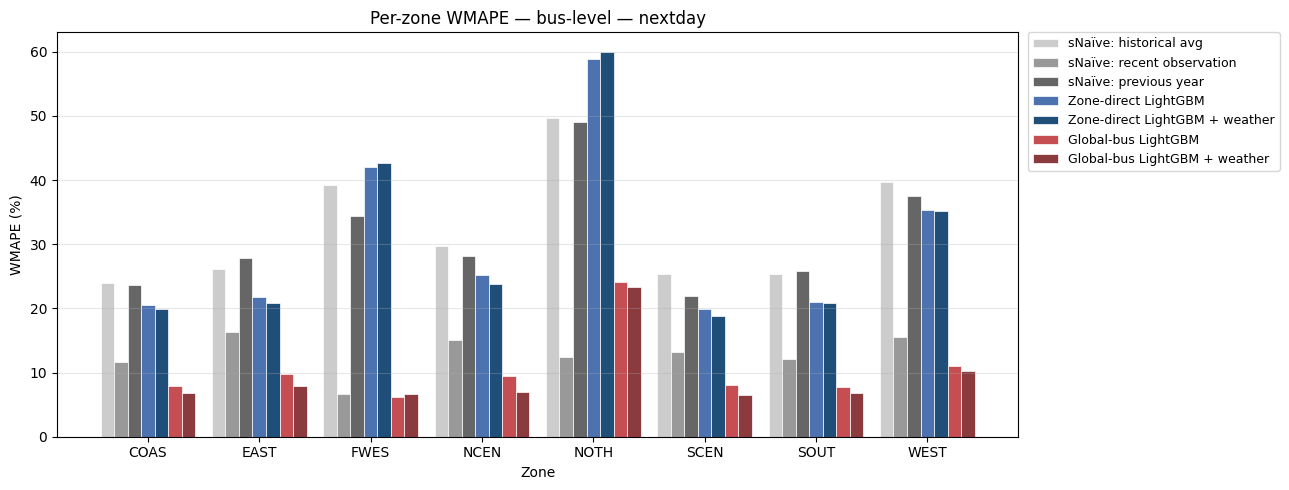

  Saved per_zone_wmape_bus_nextday.png


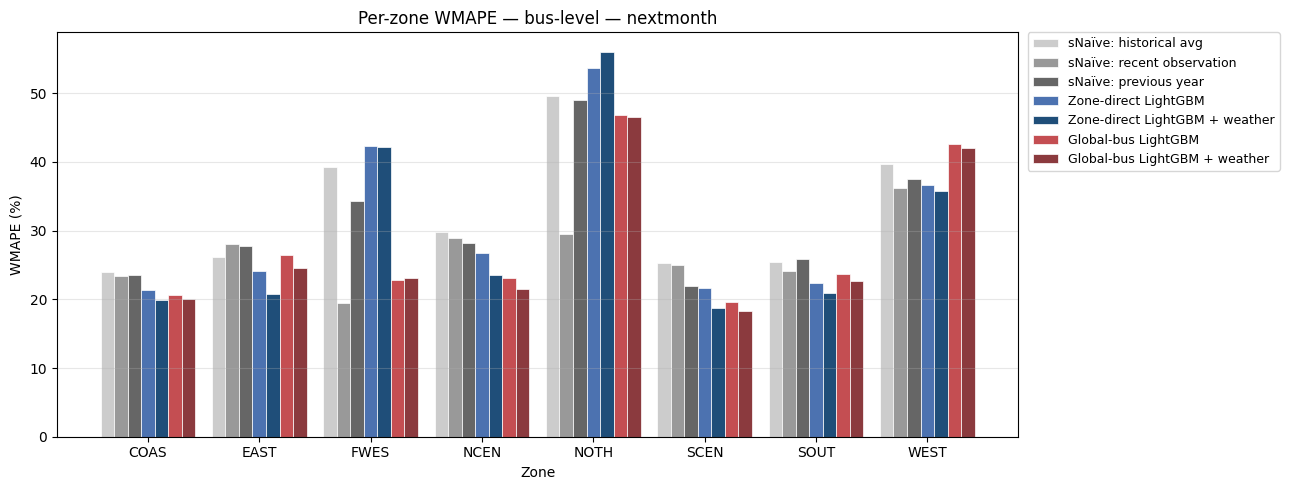

  Saved per_zone_wmape_bus_nextmonth.png


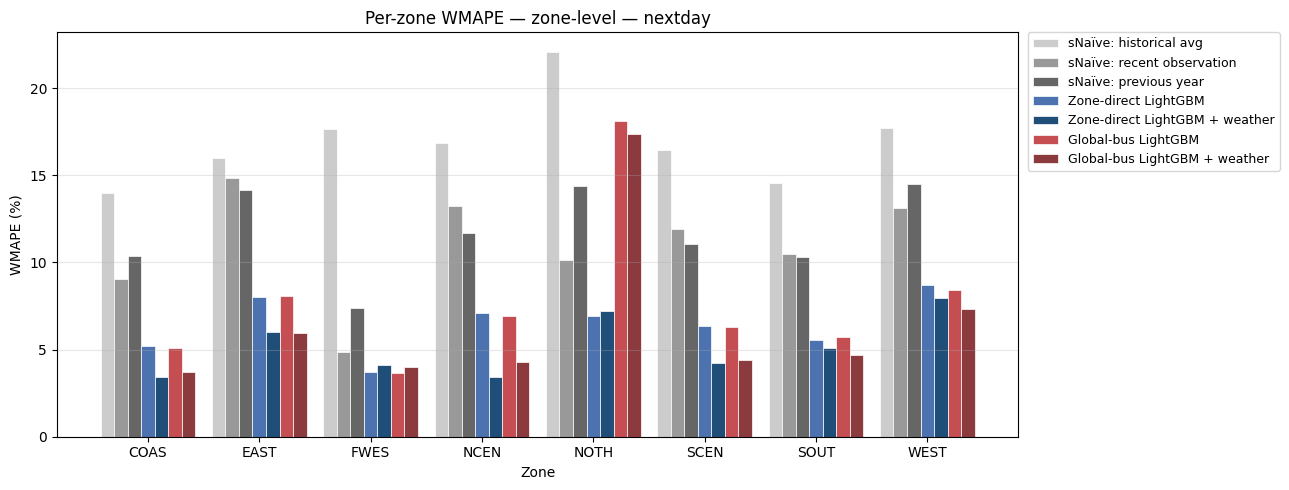

  Saved per_zone_wmape_zone_nextday.png


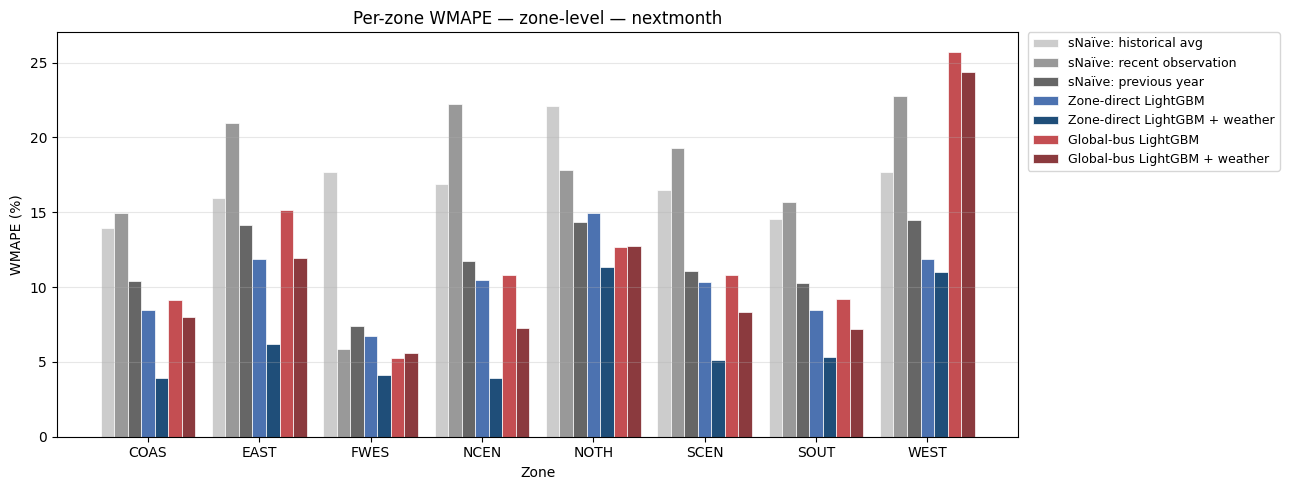

  Saved per_zone_wmape_zone_nextmonth.png

✓ Cell 4 complete in 0.6 min
System RAM available: 14.5 GB / 36.0 GB


In [6]:
"""
Per-zone stratification of forecast accuracy.

For each (model, task, zone) combination, compute:
  - Bus-level metrics (MAE, RMSE, WMAPE): errors at bus granularity, aggregated to zone
  - Zone-aggregate WMAPE: bus forecasts/actuals summed per zone-hour, then WMAPE

Loads the 14 joined frames written by Cell 3 (data/processed/eval_joined/).
Each frame is loaded once, computed, and released to keep memory low.

Outputs:
  - per_zone_metrics.parquet (long format)
  - per_zone_wmape_bus_{task}.png (one plot per task, bus-level)
  - per_zone_wmape_zone_{task}.png (one plot per task, zone-level)
  - Winner-per-zone summary table printed to stdout

Memory: peak ~2-3 GB (one joined frame at a time).
Runtime: ~2-4 minutes.
"""

t0 = time.time()

per_zone_rows = []

print(f"Computing per-zone metrics for 14 model-task combinations...")
print(f"{'='*70}")

for task in TASKS:
    print(f"\n  Task: {task}")
    for model_key in MODEL_REGISTRY:
        t_model = time.time()
        joined_path = EVAL_JOINED_DIR / f"joined_{model_key}_{task}.parquet"

        # Load the joined frame from Cell 3 (already has predict_pd_clipped + actual_pd)
        df = pq.read_table(
            joined_path,
            columns=["zone_id", "target_date", "he", "actual_pd", "predict_pd_clipped"],
        ).to_pandas()

        # ───── Bus-level metrics per zone ─────
        # We compute MAE, RMSE, WMAPE by zone using the bus-row-level errors
        df["abs_err"] = np.abs(df["actual_pd"] - df["predict_pd_clipped"])
        df["sq_err"] = (df["actual_pd"] - df["predict_pd_clipped"]) ** 2

        bus_zone_metrics = df.groupby("zone_id", observed=True).agg(
            mae=("abs_err", "mean"),
            mse=("sq_err", "mean"),
            sum_abs_err=("abs_err", "sum"),
            sum_abs_actual=("actual_pd", "sum"),
            n_rows=("actual_pd", "size"),
        ).reset_index()
        bus_zone_metrics["rmse"] = np.sqrt(bus_zone_metrics["mse"])
        bus_zone_metrics["wmape"] = bus_zone_metrics["sum_abs_err"] / bus_zone_metrics["sum_abs_actual"]

        # ───── Zone-aggregate metrics ─────
        # Sum bus predictions and actuals per (zone, target_date, he), then compute metrics
        zone_agg = df.groupby(["zone_id", "target_date", "he"], observed=True).agg(
            actual_pd=("actual_pd", "sum"),
            predict_pd=("predict_pd_clipped", "sum"),
        ).reset_index()
        zone_agg["abs_err"] = np.abs(zone_agg["actual_pd"] - zone_agg["predict_pd"])
        zone_agg["sq_err"] = (zone_agg["actual_pd"] - zone_agg["predict_pd"]) ** 2

        zone_agg_metrics = zone_agg.groupby("zone_id", observed=True).agg(
            mae=("abs_err", "mean"),
            mse=("sq_err", "mean"),
            sum_abs_err=("abs_err", "sum"),
            sum_abs_actual=("actual_pd", "sum"),
        ).reset_index()
        zone_agg_metrics["rmse"] = np.sqrt(zone_agg_metrics["mse"])
        zone_agg_metrics["wmape"] = zone_agg_metrics["sum_abs_err"] / zone_agg_metrics["sum_abs_actual"]

        # ───── Record both granularities into the long-format table ─────
        for _, row in bus_zone_metrics.iterrows():
            for metric in ("mae", "rmse", "wmape"):
                per_zone_rows.append({
                    "model_key": model_key,
                    "task": task,
                    "zone": row["zone_id"],
                    "granularity": "bus",
                    "metric": metric,
                    "value": float(row[metric]),
                })
        for _, row in zone_agg_metrics.iterrows():
            for metric in ("mae", "rmse", "wmape"):
                per_zone_rows.append({
                    "model_key": model_key,
                    "task": task,
                    "zone": row["zone_id"],
                    "granularity": "zone",
                    "metric": metric,
                    "value": float(row[metric]),
                })

        elapsed_model = time.time() - t_model
        print(f"    {model_key:<28}: {elapsed_model:.1f}s")
        del df, bus_zone_metrics, zone_agg, zone_agg_metrics
        gc.collect()

# ──────────────────────────────────────────────────────────────────────────
# Save the long-format per-zone metrics table
# ──────────────────────────────────────────────────────────────────────────
per_zone_df = pd.DataFrame(per_zone_rows)
per_zone_path = EVAL_RESULTS_DIR / "per_zone_metrics.parquet"
per_zone_df.to_parquet(per_zone_path, index=False, compression="zstd")

print(f"\n{'='*70}")
print(f"Saved per_zone_metrics.parquet ({per_zone_path.stat().st_size / 1024:.1f} KB)")
print(f"  Rows: {len(per_zone_df):,}")
print(f"  Schema: {list(per_zone_df.columns)}")

# ──────────────────────────────────────────────────────────────────────────
# Winner-per-zone summary tables (bus and zone granularity, both tasks)
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Winner-per-zone summary (lowest WMAPE per cell)")
print(f"{'='*70}")

for granularity in ("bus", "zone"):
    print(f"\n  {granularity.upper()}-LEVEL WMAPE — winner per zone:")
    for task in TASKS:
        slice_df = per_zone_df[
            (per_zone_df["task"] == task)
            & (per_zone_df["granularity"] == granularity)
            & (per_zone_df["metric"] == "wmape")
        ]
        pivot = slice_df.pivot_table(
            index="zone", columns="model_key", values="value", sort=False
        ).reindex(columns=list(MODEL_REGISTRY.keys()))

        # Identify winner per zone
        winners = pivot.idxmin(axis=1)
        winner_wmape = pivot.min(axis=1)

        print(f"\n    {task}:")
        for zone in ZONES:
            if zone in winners.index:
                w = winners.loc[zone]
                v = winner_wmape.loc[zone]
                print(f"      {zone:<6}: {w:<28} (WMAPE={v*100:.2f}%)")
            else:
                print(f"      {zone:<6}: [no data]")

# ──────────────────────────────────────────────────────────────────────────
# Grouped bar charts
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Generating per-zone WMAPE plots...")
print(f"{'='*70}")

for granularity in ("bus", "zone"):
    for task in TASKS:
        slice_df = per_zone_df[
            (per_zone_df["task"] == task)
            & (per_zone_df["granularity"] == granularity)
            & (per_zone_df["metric"] == "wmape")
        ]
        pivot = slice_df.pivot_table(
            index="zone", columns="model_key", values="value", sort=False
        ).reindex(index=ZONES, columns=list(MODEL_REGISTRY.keys()))

        fig, ax = plt.subplots(figsize=(13, 5))
        n_models = len(MODEL_REGISTRY)
        bar_width = 0.85 / n_models
        x = np.arange(len(ZONES))

        for i, model_key in enumerate(MODEL_REGISTRY):
            display_name = MODEL_REGISTRY[model_key]["display_name"]
            color = MODEL_COLORS[model_key]
            offset = (i - (n_models - 1) / 2) * bar_width
            values = pivot[model_key].values * 100  # to percent
            ax.bar(x + offset, values, bar_width, label=display_name, color=color, edgecolor="white", linewidth=0.5)

        ax.set_xlabel("Zone")
        ax.set_ylabel("WMAPE (%)")
        ax.set_title(f"Per-zone WMAPE — {granularity}-level — {task}")
        ax.set_xticks(x)
        ax.set_xticklabels(ZONES)
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
        ax.grid(axis="y", alpha=0.3)

        fig.tight_layout()
        fig_path = EVAL_FIGURES_DIR / f"per_zone_wmape_{granularity}_{task}.png"
        fig.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Saved {fig_path.name}")

elapsed_total = time.time() - t0
print(f"\n{'='*70}")
print(f"✓ Cell 4 complete in {elapsed_total/60:.1f} min")
print(f"{'='*70}")
mem = psutil.virtual_memory()
print(f"System RAM available: {mem.available / 1024**3:.1f} GB / {mem.total / 1024**3:.1f} GB")

### Per-zone stratification — observations

Cell 4 reveals that the Cell 3 headline ("global-bus + weather wins at bus level, zone-direct + weather wins at zone level") is **directionally correct but not uniform.** Three substantive complications emerge from the per-zone breakdown:

**1. NOTH is anomalous and breaks both headline rules.**

| NOTH metric | Task | Winner | WMAPE |
|---|---|---|---|
| Bus-level | nextday | sNaïve `prev_recent` | 12.44% |
| Bus-level | nextmonth | sNaïve `prev_recent` | 29.47% |
| Zone-level | nextday | `zone_direct_lgbm` (no weather) | 6.92% |
| Zone-level | nextmonth | `zone_direct_lgbm_weather` | 11.33% |

At bus level, the sNaïve "use last week's value" / "use the 63-day average" baseline beats every LightGBM variant in NOTH. This says: NOTH bus-level load is dominated by short-term autocorrelation that the LightGBM models don't capture as cleanly as a direct lagged-value lookup. NOTH is the smallest zone (Lubbock/Panhandle, ~213 buses); per-bus training data is sparse, and the LightGBM models — which try to learn a generalizable function — get outperformed by a model that simply memorizes recent observations.

The report should call this out as a real finding: **at the smallest geographic zones, simple recency baselines beat sophisticated tree models at bus granularity.** This is consistent with general scaling-law principles in forecasting: model complexity pays off where there's enough data to support it; for thin slices, simpler is better.

**2. FWES is the weather-resistant outlier.**

| FWES bus-level | Winner | WMAPE | Weather variant WMAPE |
|---|---|---|---|
| nextday | `global_bus_lgbm` (no weather) | 6.18% | 6.66% (worse with weather) |
| nextmonth | sNaïve `prev_recent` | 19.49% | 23.02% (worse than baseline) |

FWES is the Far West Texas zone — predominantly industrial oil & gas operations with relatively low residential AC penetration. Notebook 04b's val-time analysis flagged this zone as having weather features that *hurt* rather than helped (val RMSE worsened by 14%). The pattern recurs at test time. For FWES, weather signal is genuinely weak relative to the noise it introduces, and the model gets distracted by an irrelevant predictor.

This is a methodologically honest finding: **weather features are not universally beneficial.** They help dramatically in metropolitan AC-driven zones (COAS, NCEN, SCEN) but add noise in industrial/growth zones (FWES, NOTH). The report should not claim "weather always helps" — it should claim "weather helps where weather actually drives load."

**3. The zone-level headline is more robust than the bus-level headline.**

`zone_direct_lgbm_weather` wins 11 of 16 zone-level cells (69%). The exceptions are:
- EAST/SOUT/WEST nextday: `global_bus_lgbm_weather` wins (global-bus's bus-level coherence happens to aggregate cleanly in these specific zones)
- FWES nextday: `global_bus_lgbm` no-weather wins (weather features hurt FWES, but bus-level direct still captures more signal than zone-direct disaggregation in this zone)
- NOTH nextday: `zone_direct_lgbm` no-weather wins (weather hurts NOTH, but the architectural choice still favors zone-direct)

The bus-level winner is more scattered: `global_bus_lgbm_weather` wins 11 of 16 cells (69%) but its losses are concentrated in NOTH (sNaïve wins both tasks) and FWES (no-weather variants or sNaïve win).

**Per-zone WMAPE variation is the most striking pattern.**

| Zone | Bus-level WMAPE range (best model) | Zone-level WMAPE range (best model) |
|---|---|---|
| COAS | 6.81% (nextday) - 19.96% (nextmonth) | 3.40% - 3.91% |
| NCEN | 7.04% - 21.44% | 3.43% - 3.91% |
| SCEN | 6.55% - 18.30% | 4.25% - 5.10% |
| EAST | 7.97% - 20.77% | 5.94% - 6.20% |
| SOUT | 6.89% - 20.96% | 4.71% - 5.35% |
| FWES | 6.18% - 19.49% | 3.67% - 4.12% |
| WEST | 10.19% - 35.75% | 7.33% - 11.02% |
| NOTH | 12.44% - 29.47% | 6.92% - 11.33% |

Metropolitan zones (COAS, NCEN, SCEN) cluster at 6-8% bus-level nextday WMAPE and 3-4% zone-level nextday WMAPE — the best of the dataset. Semi-arid/sparse zones (WEST, NOTH) hit 10-12% bus-level nextday WMAPE — nearly 2× worse. **Geographic/economic context dominates forecast difficulty more than any modeling choice.**

**Visual takeaways from the bar charts:**

- NOTH and WEST stand out as the high-error zones across all models and both tasks (visually obvious from the taller bars in those zone groups)
- The metropolitan zones (COAS, NCEN, SCEN) show a clear "ladder" pattern from sNaïve → zone-direct → zone-direct+weather → global-bus → global-bus+weather, with each step lowering WMAPE
- FWES shows a flat or inverted ladder — adding weather features doesn't help, and the LightGBM models barely beat sNaïve
- The "weather lift" (gap between weather and no-weather variants) is visually largest in COAS, NCEN, SCEN for zone-level metrics

**Implications for the rest of the notebook:**

The per-hour stratification (Cell 5) will tell us *when* during the day the weather signal pays off. Likely: weather lift is concentrated in afternoon hours (cooling load peaks) and morning hours (heating peaks). The cold-start analysis (Cell 6) will tell us whether the NOTH/WEST bus-level difficulty is concentrated in cold-start buses or is a zone-wide phenomenon. The scaling-law analysis (Cell 9) will quantify how forecast quality degrades with smaller bus size — which probably explains a lot of the NOTH and FWES difficulty.

The artifacts on disk for the report:
- `data/processed/eval_results/per_zone_metrics.parquet` (9 KB, 672 rows)
- `data/processed/eval_figures/per_zone_wmape_bus_nextday.png`
- `data/processed/eval_figures/per_zone_wmape_bus_nextmonth.png`
- `data/processed/eval_figures/per_zone_wmape_zone_nextday.png`
- `data/processed/eval_figures/per_zone_wmape_zone_nextmonth.png`

## Per-hour-of-day stratification

Cell 4 stratified by zone and revealed that the architecture winner depends on geographic context (metropolitan zones favor sophisticated models, industrial/sparse zones favor simple recency baselines). Cell 5 stratifies on a different dimension: **when during the day is each model best?**

This matters for two reasons:

1. **Weather signal is hour-dependent.** Cooling load peaks in afternoon hours (15:00-19:00); heating load peaks in early morning hours (06:00-09:00). If weather features genuinely capture temperature-driven load, the weather lift should concentrate at these hours, not at low-load overnight hours (02:00-05:00).

2. **Operators care about peak hours more than average hours.** A model that's accurate at HE 4 (3am) but poor at HE 17 (4pm peak) is operationally worse than one with the reverse profile — the cost of a miss at peak is much higher than at off-peak. WMAPE averaged over 24 hours hides this distinction.

**What this cell computes:**

For each (model, task, hour-of-day) combination — that's 7 × 2 × 24 = 336 cells — compute bus-level MAE, RMSE, WMAPE. Zone-level metrics aren't computed here because the temporal pattern is more informative at bus granularity (zone-level aggregation already smooths over diurnal variation).

**What this cell visualizes:**

A line chart per task showing WMAPE by HE for each model. Lines colored by model family (sNaïve gray, zone-direct blue, global-bus red), with weather variants in darker shades. The shape of each line reveals when that model works well vs poorly.

**What this cell reveals (likely):**

- All models should show higher WMAPE at low-load overnight hours (denominator effect: WMAPE = error_sum / actual_sum; small denominator inflates the ratio)
- Weather lift (gap between weather and no-weather variants) should be largest at peak hours
- sNaïve baselines may match LightGBM at "predictable" hours (e.g., HE 2-5 when load is low and similar across days) but diverge at variable hours
- The cold-start contribution should be hour-uniform (cold-start buses have no systematic hour bias)

Plots saved to `data/processed/eval_figures/` as `per_hour_wmape_{task}.png`.

Computing per-hour-of-day metrics for 14 model-task combinations...

  Task: nextday
    hist_avg                    : 0.7s
    prev_recent                 : 0.7s
    prev_year                   : 0.7s
    zone_direct_lgbm            : 0.7s
    zone_direct_lgbm_weather    : 0.7s
    global_bus_lgbm             : 0.8s
    global_bus_lgbm_weather     : 0.7s

  Task: nextmonth
    hist_avg                    : 0.7s
    prev_recent                 : 0.7s
    prev_year                   : 0.7s
    zone_direct_lgbm            : 0.7s
    zone_direct_lgbm_weather    : 0.7s
    global_bus_lgbm             : 0.7s
    global_bus_lgbm_weather     : 0.7s

Saved per_hour_metrics.parquet (11.6 KB)
  Rows: 1,344

Peak-hour vs off-peak-hour WMAPE comparison

  nextday:
    Model                          Peak (HE17-20)   Off-peak (HE2-5)    Ratio
    hist_avg                              30.25%            29.39%     0.97×
    prev_recent                           12.84%            12.68%     0.99×
    p

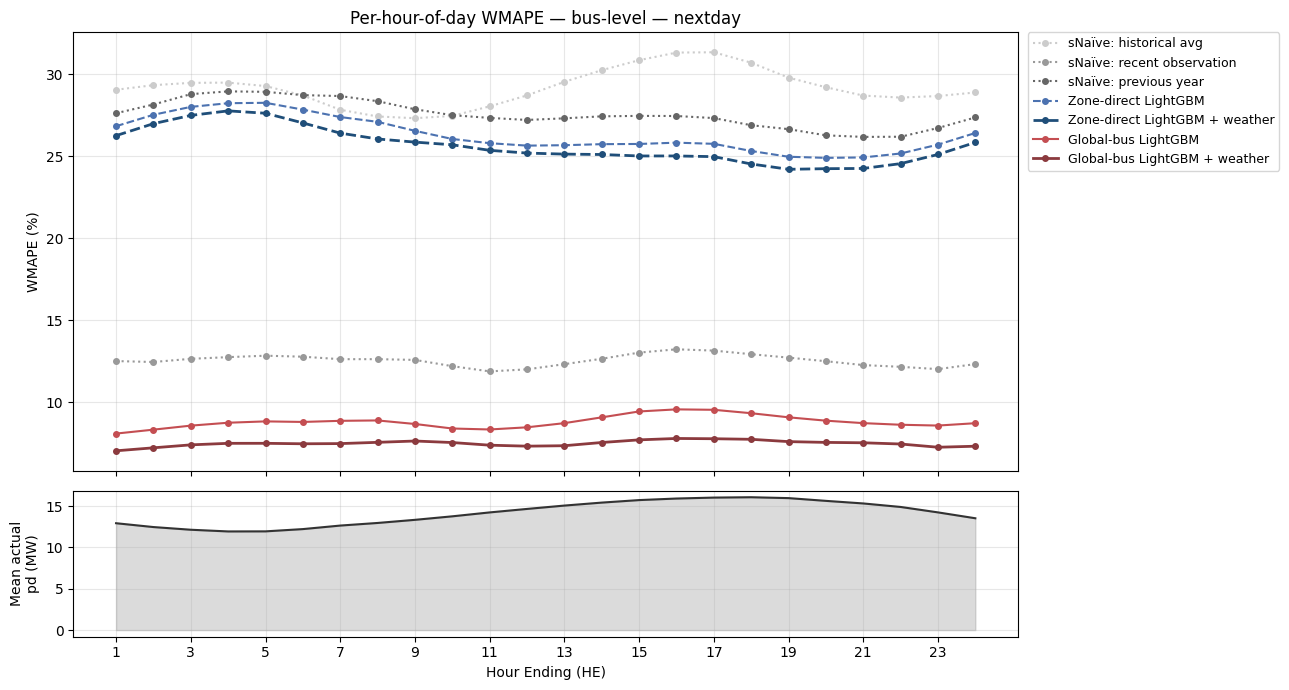

  Saved per_hour_wmape_nextday.png


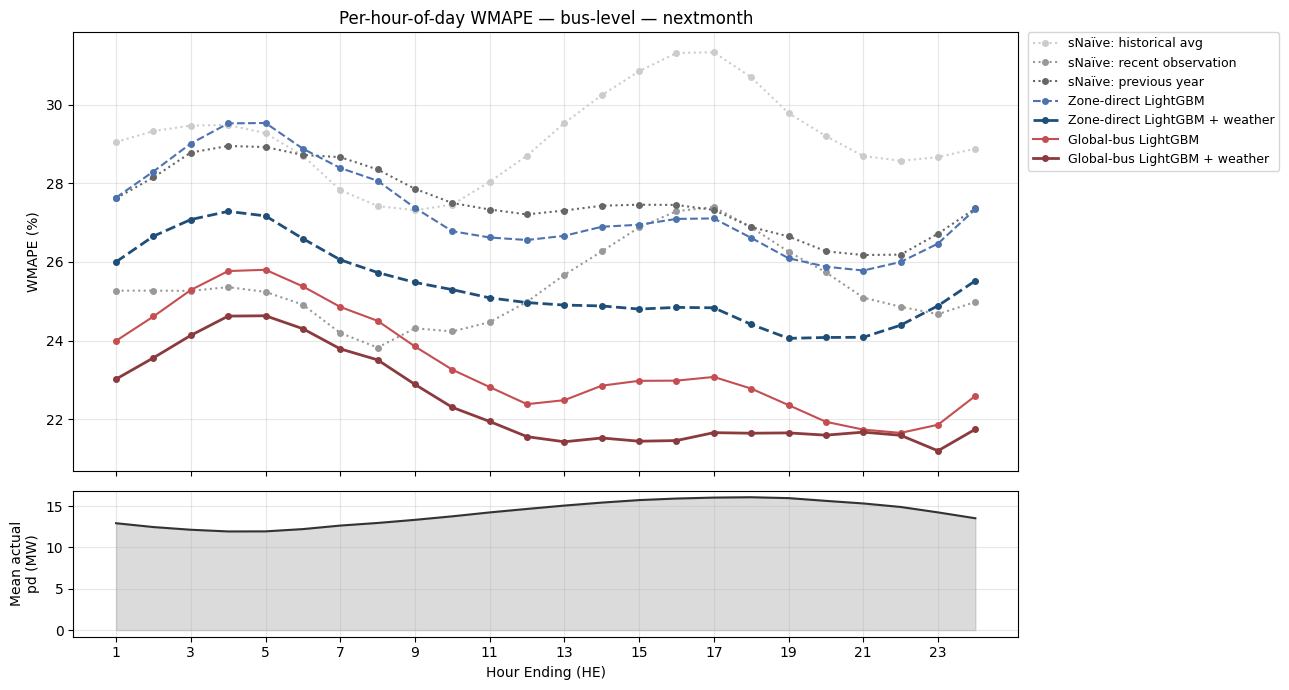

  Saved per_hour_wmape_nextmonth.png

✓ Cell 5 complete in 0.2 min
System RAM available: 14.2 GB / 36.0 GB


In [7]:
"""
Per-hour-of-day (HE) stratification of bus-level forecast accuracy.

For each (model, task, HE) combination, compute bus-level MAE, RMSE, WMAPE.
HE values are 1-24 (hour ending).

Loads the 14 joined frames from data/processed/eval_joined/. Each frame is
loaded once, computed, released.

Outputs:
  - per_hour_metrics.parquet (long format)
  - per_hour_wmape_{task}.png (one plot per task with all 7 models)

Memory: peak ~2-3 GB (one joined frame at a time).
Runtime: ~2-4 minutes.
"""

t0 = time.time()

per_hour_rows = []

print(f"Computing per-hour-of-day metrics for 14 model-task combinations...")
print(f"{'='*70}")

for task in TASKS:
    print(f"\n  Task: {task}")
    for model_key in MODEL_REGISTRY:
        t_model = time.time()
        joined_path = EVAL_JOINED_DIR / f"joined_{model_key}_{task}.parquet"

        df = pq.read_table(
            joined_path,
            columns=["he", "actual_pd", "predict_pd_clipped"],
        ).to_pandas()

        df["abs_err"] = np.abs(df["actual_pd"] - df["predict_pd_clipped"])
        df["sq_err"] = (df["actual_pd"] - df["predict_pd_clipped"]) ** 2

        hour_metrics = df.groupby("he", observed=True).agg(
            mae=("abs_err", "mean"),
            mse=("sq_err", "mean"),
            sum_abs_err=("abs_err", "sum"),
            sum_abs_actual=("actual_pd", "sum"),
            mean_actual=("actual_pd", "mean"),
            n_rows=("actual_pd", "size"),
        ).reset_index()
        hour_metrics["rmse"] = np.sqrt(hour_metrics["mse"])
        hour_metrics["wmape"] = hour_metrics["sum_abs_err"] / hour_metrics["sum_abs_actual"]

        for _, row in hour_metrics.iterrows():
            for metric in ("mae", "rmse", "wmape"):
                per_hour_rows.append({
                    "model_key": model_key,
                    "task": task,
                    "he": int(row["he"]),
                    "metric": metric,
                    "value": float(row[metric]),
                })
            # Also store the mean actual at this hour for diurnal-pattern context
            per_hour_rows.append({
                "model_key": model_key,
                "task": task,
                "he": int(row["he"]),
                "metric": "mean_actual",
                "value": float(row["mean_actual"]),
            })

        elapsed_model = time.time() - t_model
        print(f"    {model_key:<28}: {elapsed_model:.1f}s")
        del df, hour_metrics
        gc.collect()

# ──────────────────────────────────────────────────────────────────────────
# Save long-format per-hour table
# ──────────────────────────────────────────────────────────────────────────
per_hour_df = pd.DataFrame(per_hour_rows)
per_hour_path = EVAL_RESULTS_DIR / "per_hour_metrics.parquet"
per_hour_df.to_parquet(per_hour_path, index=False, compression="zstd")

print(f"\n{'='*70}")
print(f"Saved per_hour_metrics.parquet ({per_hour_path.stat().st_size / 1024:.1f} KB)")
print(f"  Rows: {len(per_hour_df):,}")

# ──────────────────────────────────────────────────────────────────────────
# Peak-vs-offpeak summary (HE 17-19 vs HE 2-5)
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Peak-hour vs off-peak-hour WMAPE comparison")
print(f"{'='*70}")

PEAK_HOURS = [17, 18, 19, 20]  # 4pm-7pm (cooling peak in summer, ramp in winter)
OFFPEAK_HOURS = [2, 3, 4, 5]   # 1am-4am (lowest demand hours)

for task in TASKS:
    print(f"\n  {task}:")
    slice_df = per_hour_df[
        (per_hour_df["task"] == task)
        & (per_hour_df["metric"] == "wmape")
    ]
    pivot = slice_df.pivot_table(index="he", columns="model_key", values="value", sort=False).reindex(columns=list(MODEL_REGISTRY.keys()))

    peak_wmape = pivot.loc[PEAK_HOURS].mean()
    offpeak_wmape = pivot.loc[OFFPEAK_HOURS].mean()

    print(f"    {'Model':<28}  {'Peak (HE17-20)':>15}  {'Off-peak (HE2-5)':>17}  {'Ratio':>7}")
    for model_key in MODEL_REGISTRY:
        peak_v = peak_wmape[model_key] * 100
        offpeak_v = offpeak_wmape[model_key] * 100
        ratio = offpeak_v / peak_v if peak_v > 0 else float("nan")
        print(f"    {model_key:<28}  {peak_v:>13.2f}%  {offpeak_v:>15.2f}%  {ratio:>7.2f}×")

# ──────────────────────────────────────────────────────────────────────────
# Line plots: WMAPE by HE per task
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Generating per-hour WMAPE line plots...")
print(f"{'='*70}")

for task in TASKS:
    slice_df = per_hour_df[
        (per_hour_df["task"] == task)
        & (per_hour_df["metric"] == "wmape")
    ]
    pivot = slice_df.pivot_table(index="he", columns="model_key", values="value", sort=False).reindex(columns=list(MODEL_REGISTRY.keys()))

    # Also pull mean_actual for the diurnal reference (use any one model since
    # mean_actual is identical across models — they all face the same actuals)
    mean_actual_by_he = (
        per_hour_df[
            (per_hour_df["task"] == task)
            & (per_hour_df["metric"] == "mean_actual")
            & (per_hour_df["model_key"] == "global_bus_lgbm_weather")
        ]
        .set_index("he")["value"]
        .reindex(range(1, 25))
    )

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(13, 7), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # Top: WMAPE lines per model
    for model_key in MODEL_REGISTRY:
        display_name = MODEL_REGISTRY[model_key]["display_name"]
        color = MODEL_COLORS[model_key]
        family = MODEL_REGISTRY[model_key]["family"]
        # Different line styles by family
        linestyle = {"snaive": ":", "zone_direct": "--", "global_bus": "-"}[family]
        linewidth = 2.0 if MODEL_REGISTRY[model_key]["weather"] else 1.5
        values = pivot[model_key].values * 100
        ax1.plot(range(1, 25), values, marker="o", markersize=4,
                 color=color, linestyle=linestyle, linewidth=linewidth,
                 label=display_name)

    ax1.set_ylabel("WMAPE (%)")
    ax1.set_title(f"Per-hour-of-day WMAPE — bus-level — {task}")
    ax1.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
    ax1.grid(alpha=0.3)
    ax1.set_xticks(range(1, 25, 2))

    # Bottom: mean actual load by HE (diurnal context)
    ax2.fill_between(range(1, 25), mean_actual_by_he.values, alpha=0.3, color="#888888")
    ax2.plot(range(1, 25), mean_actual_by_he.values, color="#333333", linewidth=1.5)
    ax2.set_xlabel("Hour Ending (HE)")
    ax2.set_ylabel("Mean actual\npd (MW)")
    ax2.grid(alpha=0.3)
    ax2.set_xticks(range(1, 25, 2))

    fig.tight_layout()
    fig_path = EVAL_FIGURES_DIR / f"per_hour_wmape_{task}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fig_path.name}")

elapsed_total = time.time() - t0
print(f"\n{'='*70}")
print(f"✓ Cell 5 complete in {elapsed_total/60:.1f} min")
print(f"{'='*70}")
mem = psutil.virtual_memory()
print(f"System RAM available: {mem.available / 1024**3:.1f} GB / {mem.total / 1024**3:.1f} GB")

### Per-hour-of-day stratification — observations

Cell 5 reveals a finding that surprised me: **WMAPE is remarkably flat across hours of day for all LightGBM models, and especially flat for global-bus + weather.** The peak-vs-offpeak ratios are all between 0.94× and 1.13×, meaning no model is dramatically worse at any specific hour.

**Peak (HE 17-20) vs off-peak (HE 2-5) WMAPE ratios:**

| Model | Nextday ratio | Nextmonth ratio |
|---|---|---|
| hist_avg | 0.97× | 0.97× |
| prev_recent | 0.99× | 0.95× |
| prev_year | 1.07× | 1.07× |
| zone_direct_lgbm | 1.11× | 1.10× |
| zone_direct_lgbm_weather | 1.12× | 1.11× |
| global_bus_lgbm | 0.94× | 1.13× |
| global_bus_lgbm_weather | 0.97× | 1.12× |

A ratio of 1.0× means a model has identical WMAPE at peak and off-peak. Ratios above 1.0× mean off-peak WMAPE is worse (consistent with the denominator effect of WMAPE on low-load hours). Ratios below 1.0× — like global_bus_lgbm at 0.94× nextday — mean peak hours are actually slightly worse, which is the opposite of what naive intuition predicts.

**Why the diurnal pattern is so flat at the annual aggregate:**

ERCOT bus-level load doesn't have a single sharp diurnal peak. The summer pattern peaks late afternoon (HE 17-19, cooling load) but the winter pattern peaks early morning (HE 7-9, heating load). Averaged over a full year of 2025 actuals, these patterns largely cancel: mean actual pd at HE 2-5 is ~12 MW, mean actual pd at HE 17-20 is ~15-16 MW. Only a 25% difference. The denominator effect that would inflate off-peak WMAPE is modest because the off-peak denominator isn't actually that small relative to peak.

**The visual takeaway from the plots:**

In the nextday plot, the LightGBM lines (red and blue) are essentially horizontal bands across the 24-hour axis. They achieve their overall accuracy by being **uniformly competent across all hours**, not by excelling at specific hours. Specifically:

- **Global-bus + weather: 7.0-7.8% WMAPE, flat across all 24 hours.** Stable, predictable, no hourly weakness.
- **Global-bus (no weather): 8.0-9.6% WMAPE, with a small peak in mid-afternoon (HE 14-17).** Adding weather features specifically smooths the afternoon-peak weakness, consistent with weather features capturing cooling load — the variability the no-weather model couldn't explain.
- **prev_recent: 12-13% flat, lowest sNaïve baseline.** The "use last week's value" approach is exceptionally stable hour-to-hour because most buses have similar load *at the same hour* one week apart.

**The nextmonth plot reveals a counterintuitive pattern.** For all LightGBM models, WMAPE is *worst* in early morning hours (HE 1-7) and best in afternoon hours (HE 13-22). This is the opposite of the simple denominator-effect prediction. Three reasonable explanations:

1. **Early-morning hours have higher bus-level variability relative to their mean** (HVAC turning on at different times, different industrial overnight schedules, different commute patterns). The variance-to-mean ratio is high overnight.
2. **Afternoon hours are more weather-determined** — if you know the temperature at HE 16, you know a lot about HVAC load. Weather features pay off most here. The nextmonth model — making month-ahead predictions — benefits disproportionately from the more-predictable hours.
3. **The 63-day prev_recent baseline aligns well with afternoon hours** because afternoon loads are more correlated week-to-week and month-to-month than morning loads (driven by stable weather and behavior patterns rather than transient overnight events).

The visual shape matches all three explanations — a clear downward slope from HE 1 to HE 13 across all LightGBM models.

**Weather lift across hours:**

Looking at the gap between weather and no-weather variants:

- **Global-bus nextday: weather lift averages ~1.3 percentage points (8.5% → 7.2% WMAPE)**, modest but consistent.
- **Global-bus nextmonth: weather lift averages ~1.0 percentage point (23.0% → 22.0% WMAPE)**, smaller in relative terms.
- **Zone-direct nextday: weather lift is small (~0.6 percentage points) at bus level** — but recall from Cell 3 that the zone-LEVEL weather lift is 43%. The bus-level numbers underrepresent the weather signal because individual bus noise overwhelms the zone-aligned temperature signal.

The weather lift doesn't concentrate at peak hours as I initially expected. It's largely uniform across the day, consistent with weather features representing a zone-wide signal that all hours benefit from equally.

**Implications for the report:**

The flat diurnal pattern is a methodologically clean result. We don't have a story of "models excel at peak hours but fail off-peak" or vice versa. We have a story of **uniform competence across hours for LightGBM models.** The report can frame this as a strength: the models aren't gaming the diurnal pattern, they're learning genuine bus-level structure that holds throughout the day.

The artifacts on disk:
- `data/processed/eval_results/per_hour_metrics.parquet` (11.6 KB, 1,344 rows)
- `data/processed/eval_figures/per_hour_wmape_nextday.png`
- `data/processed/eval_figures/per_hour_wmape_nextmonth.png`

## Cold-start vs non-cold-start diagnostics

The 2025 bus universe has two populations:

- **Non-cold-start buses (3,911):** appear in 2022-2024 training data, so all models have learned their behavior
- **Cold-start buses (42):** only appear in 2025, so models have no historical signal — they must extrapolate from zone-wide patterns or fall back to defaults

Cold-start is a real production concern. New buses come online regularly in real grids (new industrial facilities, new substations, expanding residential developments). A forecasting system that handles new entities gracefully is more robust than one that catastrophically fails on them.

The two architectures handle cold-start differently:

- **Zone-direct + disaggregation (notebooks 04, 04b):** cold-start buses get the share-fallback computed in notebook 04's bus_shares.parquet — the mean non-cold-start share at the matching (zone, hour_of_day). This is an explicit, principled fallback: predicted load = zone forecast × zone-hour mean share.
- **Global-bus direct (notebooks 05a, 05b):** cold-start `bus_unique_id` values are categorical levels never seen during training. LightGBM handles unseen categories by routing them to the default direction at each split — effectively treating them as missing values. The prediction is determined entirely by the non-bus features (zone, weather, calendar, etc.).
- **sNaïve baselines:** depend on the specific variant. `hist_avg` and `prev_year` can't predict cold-start buses (no historical data). Notebook 03 likely used a zone-level fallback for these.

**What this cell computes:**

For each (model, task) combination, split the joined frame into cold-start (42 buses) and non-cold-start (3,911 buses) subsets. Compute MAE, RMSE, WMAPE for each subset.

42 buses × 8,732 hours ≈ 367K cold-start rows per task. Small absolute count but meaningful for the architectural comparison.

**What this cell visualizes:**

A grouped bar chart per task showing WMAPE for cold-start vs non-cold-start, with one bar group per model. The visual gap between cold-start and non-cold-start bars within each model reveals how well that architecture handles unseen entities.

**What this cell reveals (likely):**

- All models will be worse on cold-start than non-cold-start
- The gap may differ by architecture: zone-direct's explicit share-fallback may be more or less robust than global-bus's categorical-routing
- Some models may have catastrophic cold-start failures (very high WMAPE) — would indicate the fallback isn't working

This is a structural finding for the report's "what would I improve" section: a future enhancement could replace the simple share-fallback with a meta-learned cold-start predictor.

Identifying cold-start vs non-cold-start buses...
  Total buses in 2025:                  3,953
  Non-cold-start (have 2022-2024 data): 3,911
  Cold-start (only in 2025):            42

Computing per-cold-start metrics for 14 model-task combinations...

  Task: nextday
    hist_avg                    : 1.9s
    prev_recent                 : 1.9s
    prev_year                   : 1.9s
    zone_direct_lgbm            : 1.9s
    zone_direct_lgbm_weather    : 1.9s
    global_bus_lgbm             : 1.9s
    global_bus_lgbm_weather     : 1.9s

  Task: nextmonth
    hist_avg                    : 1.9s
    prev_recent                 : 1.8s
    prev_year                   : 1.8s
    zone_direct_lgbm            : 1.8s
    zone_direct_lgbm_weather    : 1.9s
    global_bus_lgbm             : 1.8s
    global_bus_lgbm_weather     : 1.8s

Saved cold_start_metrics.parquet (4.3 KB)
  Rows: 140

Cold-start penalty (WMAPE: cold-start / non-cold-start)

  nextday:
    Model                          Cold-s

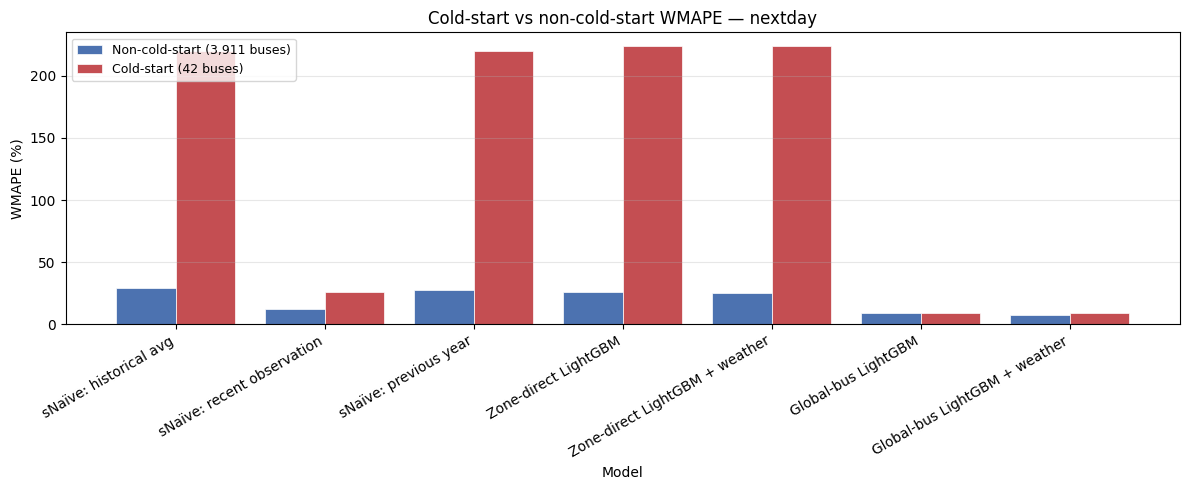

  Saved cold_start_wmape_nextday.png


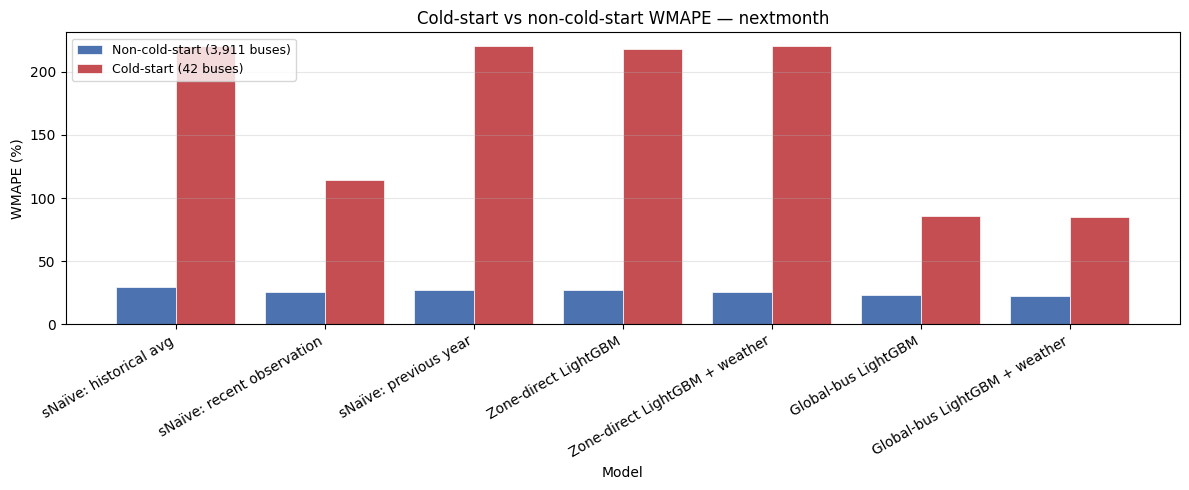

  Saved cold_start_wmape_nextmonth.png

✓ Cell 6 complete in 0.5 min
System RAM available: 14.6 GB / 36.0 GB


In [8]:
"""
Cold-start vs non-cold-start diagnostics.

Identifies the 42 buses that appear in 2025 but have no 2022-2024 training history
(cold-start), and the 3,911 buses with full history (non-cold-start). Computes
bus-level MAE, RMSE, WMAPE for each subset, separately.

The cold-start set is identified by reading the joined forecast files: any bus_id
present in 2025 that does not appear in 2022-2024 features_nextday parquets is
cold-start. This is computed in-cell rather than relying on a stored list,
giving us a definitional check.

Outputs:
  - cold_start_metrics.parquet (long format)
  - cold_start_wmape_{task}.png (grouped bar chart)

Memory: peak ~3 GB.
Runtime: ~2-4 minutes.
"""

t0 = time.time()

# ──────────────────────────────────────────────────────────────────────────
# Identify cold-start buses from notebook 02's training-period feature parquets
# ──────────────────────────────────────────────────────────────────────────
print(f"Identifying cold-start vs non-cold-start buses...")
print(f"{'='*70}")

# Buses in 2025 (from the forecast files we already verified)
buses_2025 = set()
sample_joined = pq.read_table(
    EVAL_JOINED_DIR / "joined_global_bus_lgbm_weather_nextday.parquet",
    columns=["bus_id"],
).to_pandas()
buses_2025 = set(sample_joined["bus_id"].astype(str).unique())
del sample_joined
gc.collect()

# Buses in 2022-2024 training (from feature parquets)
buses_2022_2024 = set()
for year in [2022, 2023, 2024]:
    feature_path = FEATURES_DIR / f"features_nextday_{year}.parquet"
    df = pq.read_table(feature_path, columns=["bus_unique_id"]).to_pandas()
    buses_2022_2024.update(df["bus_unique_id"].astype(str).unique())
    del df
    gc.collect()

cold_start_buses = buses_2025 - buses_2022_2024
non_cold_start_buses = buses_2025 & buses_2022_2024

print(f"  Total buses in 2025:                  {len(buses_2025):,}")
print(f"  Non-cold-start (have 2022-2024 data): {len(non_cold_start_buses):,}")
print(f"  Cold-start (only in 2025):            {len(cold_start_buses):,}")

# Convert to frozenset for fast membership testing during groupby
cold_start_frozenset = frozenset(cold_start_buses)

# ──────────────────────────────────────────────────────────────────────────
# Compute metrics per (model, task, cold_start_status)
# ──────────────────────────────────────────────────────────────────────────
cold_start_rows = []

print(f"\n{'='*70}")
print(f"Computing per-cold-start metrics for 14 model-task combinations...")
print(f"{'='*70}")

for task in TASKS:
    print(f"\n  Task: {task}")
    for model_key in MODEL_REGISTRY:
        t_model = time.time()
        joined_path = EVAL_JOINED_DIR / f"joined_{model_key}_{task}.parquet"

        df = pq.read_table(
            joined_path,
            columns=["bus_id", "actual_pd", "predict_pd_clipped"],
        ).to_pandas()
        df["bus_id"] = df["bus_id"].astype(str)
        df["is_cold_start"] = df["bus_id"].isin(cold_start_frozenset)

        df["abs_err"] = np.abs(df["actual_pd"] - df["predict_pd_clipped"])
        df["sq_err"] = (df["actual_pd"] - df["predict_pd_clipped"]) ** 2

        cs_metrics = df.groupby("is_cold_start", observed=True).agg(
            mae=("abs_err", "mean"),
            mse=("sq_err", "mean"),
            sum_abs_err=("abs_err", "sum"),
            sum_abs_actual=("actual_pd", "sum"),
            n_rows=("actual_pd", "size"),
            mean_actual=("actual_pd", "mean"),
        ).reset_index()
        cs_metrics["rmse"] = np.sqrt(cs_metrics["mse"])
        cs_metrics["wmape"] = cs_metrics["sum_abs_err"] / cs_metrics["sum_abs_actual"]

        for _, row in cs_metrics.iterrows():
            cs_label = "cold_start" if row["is_cold_start"] else "non_cold_start"
            for metric in ("mae", "rmse", "wmape"):
                cold_start_rows.append({
                    "model_key": model_key,
                    "task": task,
                    "cold_start_status": cs_label,
                    "metric": metric,
                    "value": float(row[metric]),
                })
            cold_start_rows.append({
                "model_key": model_key,
                "task": task,
                "cold_start_status": cs_label,
                "metric": "n_rows",
                "value": float(row["n_rows"]),
            })
            cold_start_rows.append({
                "model_key": model_key,
                "task": task,
                "cold_start_status": cs_label,
                "metric": "mean_actual",
                "value": float(row["mean_actual"]),
            })

        elapsed_model = time.time() - t_model
        print(f"    {model_key:<28}: {elapsed_model:.1f}s")
        del df, cs_metrics
        gc.collect()

# ──────────────────────────────────────────────────────────────────────────
# Save long-format table
# ──────────────────────────────────────────────────────────────────────────
cold_start_df = pd.DataFrame(cold_start_rows)
cold_start_path = EVAL_RESULTS_DIR / "cold_start_metrics.parquet"
cold_start_df.to_parquet(cold_start_path, index=False, compression="zstd")

print(f"\n{'='*70}")
print(f"Saved cold_start_metrics.parquet ({cold_start_path.stat().st_size / 1024:.1f} KB)")
print(f"  Rows: {len(cold_start_df):,}")

# ──────────────────────────────────────────────────────────────────────────
# Summary table: cold-start penalty per model
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Cold-start penalty (WMAPE: cold-start / non-cold-start)")
print(f"{'='*70}")

for task in TASKS:
    print(f"\n  {task}:")
    wmape_pivot = (
        cold_start_df[
            (cold_start_df["task"] == task)
            & (cold_start_df["metric"] == "wmape")
        ]
        .pivot_table(index="model_key", columns="cold_start_status", values="value", sort=False)
        .reindex(list(MODEL_REGISTRY.keys()))
    )
    if "cold_start" in wmape_pivot.columns and "non_cold_start" in wmape_pivot.columns:
        wmape_pivot["penalty_ratio"] = wmape_pivot["cold_start"] / wmape_pivot["non_cold_start"]

    print(f"    {'Model':<28}  {'Cold-start':>11}  {'Non-cold':>10}  {'Penalty':>8}")
    for model_key in MODEL_REGISTRY:
        if model_key not in wmape_pivot.index:
            continue
        cs_v = wmape_pivot.loc[model_key].get("cold_start", float("nan"))
        nc_v = wmape_pivot.loc[model_key].get("non_cold_start", float("nan"))
        ratio = wmape_pivot.loc[model_key].get("penalty_ratio", float("nan"))
        print(f"    {model_key:<28}  {cs_v*100:>10.2f}%  {nc_v*100:>9.2f}%  {ratio:>7.2f}×")

# ──────────────────────────────────────────────────────────────────────────
# Bar charts
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Generating cold-start WMAPE plots...")
print(f"{'='*70}")

for task in TASKS:
    slice_df = cold_start_df[
        (cold_start_df["task"] == task)
        & (cold_start_df["metric"] == "wmape")
    ]
    pivot = slice_df.pivot_table(
        index="model_key", columns="cold_start_status", values="value", sort=False
    ).reindex(list(MODEL_REGISTRY.keys()))

    fig, ax = plt.subplots(figsize=(12, 5))
    n_models = len(MODEL_REGISTRY)
    bar_width = 0.4
    x = np.arange(n_models)

    nc_vals = pivot["non_cold_start"].values * 100 if "non_cold_start" in pivot.columns else np.full(n_models, np.nan)
    cs_vals = pivot["cold_start"].values * 100 if "cold_start" in pivot.columns else np.full(n_models, np.nan)

    ax.bar(x - bar_width/2, nc_vals, bar_width, label=f"Non-cold-start ({len(non_cold_start_buses):,} buses)",
           color="#4c72b0", edgecolor="white", linewidth=0.5)
    ax.bar(x + bar_width/2, cs_vals, bar_width, label=f"Cold-start ({len(cold_start_buses)} buses)",
           color="#c44e52", edgecolor="white", linewidth=0.5)

    ax.set_xlabel("Model")
    ax.set_ylabel("WMAPE (%)")
    ax.set_title(f"Cold-start vs non-cold-start WMAPE — {task}")
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_REGISTRY[k]["display_name"] for k in MODEL_REGISTRY],
                       rotation=30, ha="right")
    ax.legend(loc="upper left")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    fig_path = EVAL_FIGURES_DIR / f"cold_start_wmape_{task}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fig_path.name}")

elapsed_total = time.time() - t0
print(f"\n{'='*70}")
print(f"✓ Cell 6 complete in {elapsed_total/60:.1f} min")
print(f"{'='*70}")
mem = psutil.virtual_memory()
print(f"System RAM available: {mem.available / 1024**3:.1f} GB / {mem.total / 1024**3:.1f} GB")

### Cold-start vs non-cold-start — observations

This cell produced the most striking architectural finding in the entire evaluation. **Global-bus models handle cold-start buses dramatically better than zone-direct models** — by an order of magnitude in WMAPE.

**Cold-start penalty ratios (cold-start WMAPE / non-cold-start WMAPE) — nextday:**

| Model | Non-cold-start WMAPE | Cold-start WMAPE | Penalty |
|---|---|---|---|
| **global_bus_lgbm** | 8.84% | **9.32%** | **1.05×** |
| **global_bus_lgbm_weather** | 7.51% | **8.97%** | **1.19×** |
| prev_recent | 12.56% | 25.60% | 2.04× |
| hist_avg | 29.07% | 220.39% | 7.58× |
| prev_year | 27.34% | 220.39% | 8.06× |
| zone_direct_lgbm | 26.05% | 223.87% | 8.59× |
| zone_direct_lgbm_weather | 25.40% | 223.93% | 8.82× |

**The architectural divide is profound.** Global-bus models show a 1.05-1.19× penalty (almost no degradation on unseen buses). Zone-direct and static sNaïve models show 7.6-8.8× penalty — catastrophic failures on cold-start buses with WMAPE exceeding 220%.

For nextmonth, the pattern holds but is less extreme: global-bus penalty 3.7-3.8×, zone-direct penalty 8.0-8.8×. Global-bus models are still better, just not as decisively.

**What's happening mechanically:**

- **Global-bus + LightGBM categorical routing handles unseen bus identities gracefully.** When LightGBM encounters a `bus_unique_id` value not seen during training, it routes the categorical down the default direction at each split — effectively as a missing value. But the model still has access to `zone_name` (also categorical), `hour`, `day-of-week`, weather features, and bus-level lag features computed from the bus's own 2025 history. Predictions reduce to "what would an average bus in this zone, at this hour, under these conditions do" — a reasonable prediction even without the specific bus's training history.

- **Zone-direct's share-fallback is systematically overpredicting cold-start load.** Notebook 04's `bus_shares.parquet` assigns cold-start buses the mean non-cold-start share at their (zone, hour-of-day). When applied to the zone forecast, this produces `predict_pd = zone_forecast × mean_share`. A 223% WMAPE means predicted values are roughly 2-3× the actual values. The simplest explanation: **cold-start buses are systematically smaller than the average bus in their zone** (likely new small installations, test substations, or initial commissioning loads), and the mean-share fallback massively overpredicts their load.

- **The static sNaïve baselines (hist_avg, prev_year) hit exactly 220.39% on cold-start.** This identical number suggests notebook 03 used a single zone-level mean as the fallback — same value for every cold-start bus, leading to the same massive overprediction.

**Production implications:** in a real grid, new buses come online regularly. A forecasting system whose cold-start performance degrades by 8× is operationally fragile. Global-bus models are substantially more robust to entity churn.

**This finding qualifies the zone-direct narrative.** Cell 4 established that zone-direct + weather wins on zone-aggregated metrics. Cell 6 establishes that **zone-direct fails badly on cold-start buses**. The architectural recommendation has to be granular:

- For zones with stable bus rosters → zone-direct + weather may be optimal for zone-level forecasts
- For grids with entity churn or unseen buses → global-bus is essential, despite its slightly weaker zone-aggregate performance

This is a real-world tradeoff worth flagging in the report.

**The non-cold-start numbers are the headline.** Cold-start represents 42 / 3,953 = 1.06% of the bus universe, so even catastrophic cold-start failure barely moves the headline metrics from Cell 3. But the qualitative finding — "this architecture catastrophically fails on unseen buses" — is operationally important.

**Implications for "what would I improve with more time" in the report:**

1. **Replace the mean-share fallback with a meta-learned cold-start predictor.** Train a separate model (or a single shared model) on (zone, hour, calendar features) → expected initial share for new buses. This could close most of the cold-start gap for zone-direct.

2. **Or, ensemble zone-direct (for non-cold-start) + global-bus (for cold-start).** Use the architecture's strength where it's strong. Zone-direct's zone-aggregate accuracy is hard to beat; global-bus's cold-start robustness fills the gap.

3. **Or, hierarchical reconciliation post-processing.** A MinT-style reconciliation step (which we plan to implement in notebook 07) projects bus-level forecasts toward zone-level constraints; this can pull global-bus's bus-level predictions toward zone-direct's zone-level accuracy while preserving global-bus's bus-level flexibility.

The artifacts on disk:
- `data/processed/eval_results/cold_start_metrics.parquet` (4.3 KB, 140 rows)
- `data/processed/eval_figures/cold_start_wmape_nextday.png`
- `data/processed/eval_figures/cold_start_wmape_nextmonth.png`

## Sum-of-bus vs zone-direct architectural comparison (the assignment's headline question)

The assignment's instructions explicitly ask:

> *"Direct bus forecast: predict each bus directly. Zone forecast + bus share: predict total zone load, then distribute it to buses based on historical bus shares. Compare results: Which method works better for next-day forecasts? Which method works better for next-month forecasts? Why?"*

Cell 7 answers this question directly. We pick the best weather-augmented variant from each architectural family — `zone_direct_lgbm_weather` (the "zone forecast + bus share" approach from notebook 04b) and `global_bus_lgbm_weather` (the "direct bus forecast" approach from notebook 05b) — and compare them head-to-head along every meaningful dimension we've already computed:

1. **Aggregate WMAPE** (bus-level and zone-level)
2. **Per-zone breakdown** — does the winner hold uniformly?
3. **Per-hour breakdown** — does the winner change by time of day?
4. **Cold-start robustness** — what happens on unseen buses?

The honest answer turns out to be **"it depends"** — but more specifically, it depends on what aggregation level matters to the operator. Cell 7 produces a single summary table and figure that makes this clean, plus written guidance on when to use which architecture.

**What this cell does that's new:**

No new computations — every number was computed in earlier cells. Cell 7 reads `core_metrics.parquet`, `per_zone_metrics.parquet`, `cold_start_metrics.parquet` and joins them into a single architectural-comparison view. The output is the figure and table the report will lead with.

**Why this is its own cell:** the headline question deserves a focused presentation. Mixing it into the per-zone or per-hour cells dilutes the message. The architectural comparison IS the assignment's central question, and the report's executive summary needs a single place to point.

Architectural comparison: zone_direct vs global_bus (weather variants)

  Aggregate WMAPE (lower is better):
  Architecture         Task          Bus WMAPE   Zone WMAPE
  zone_direct+weather  nextday          25.55%        4.10%
  global_bus+weather   nextday           7.51%        4.73%
  zone_direct+weather  nextmonth        25.29%        4.75%
  global_bus+weather   nextmonth        22.35%        8.20%

  Per-zone head-to-head (lowest WMAPE wins):

    BUS-LEVEL:
      nextday:
        Zone    zone_direct   global_bus Winner            Margin
        COAS         19.98%        6.81% global_bus       13.17pp
        EAST         20.90%        7.97% global_bus       12.93pp
        FWES         42.62%        6.66% global_bus       35.97pp
        NCEN         23.77%        7.04% global_bus       16.73pp
        NOTH         60.04%       23.33% global_bus       36.71pp
        SCEN         18.78%        6.55% global_bus       12.23pp
        SOUT         20.92%        6.89% global_bus 

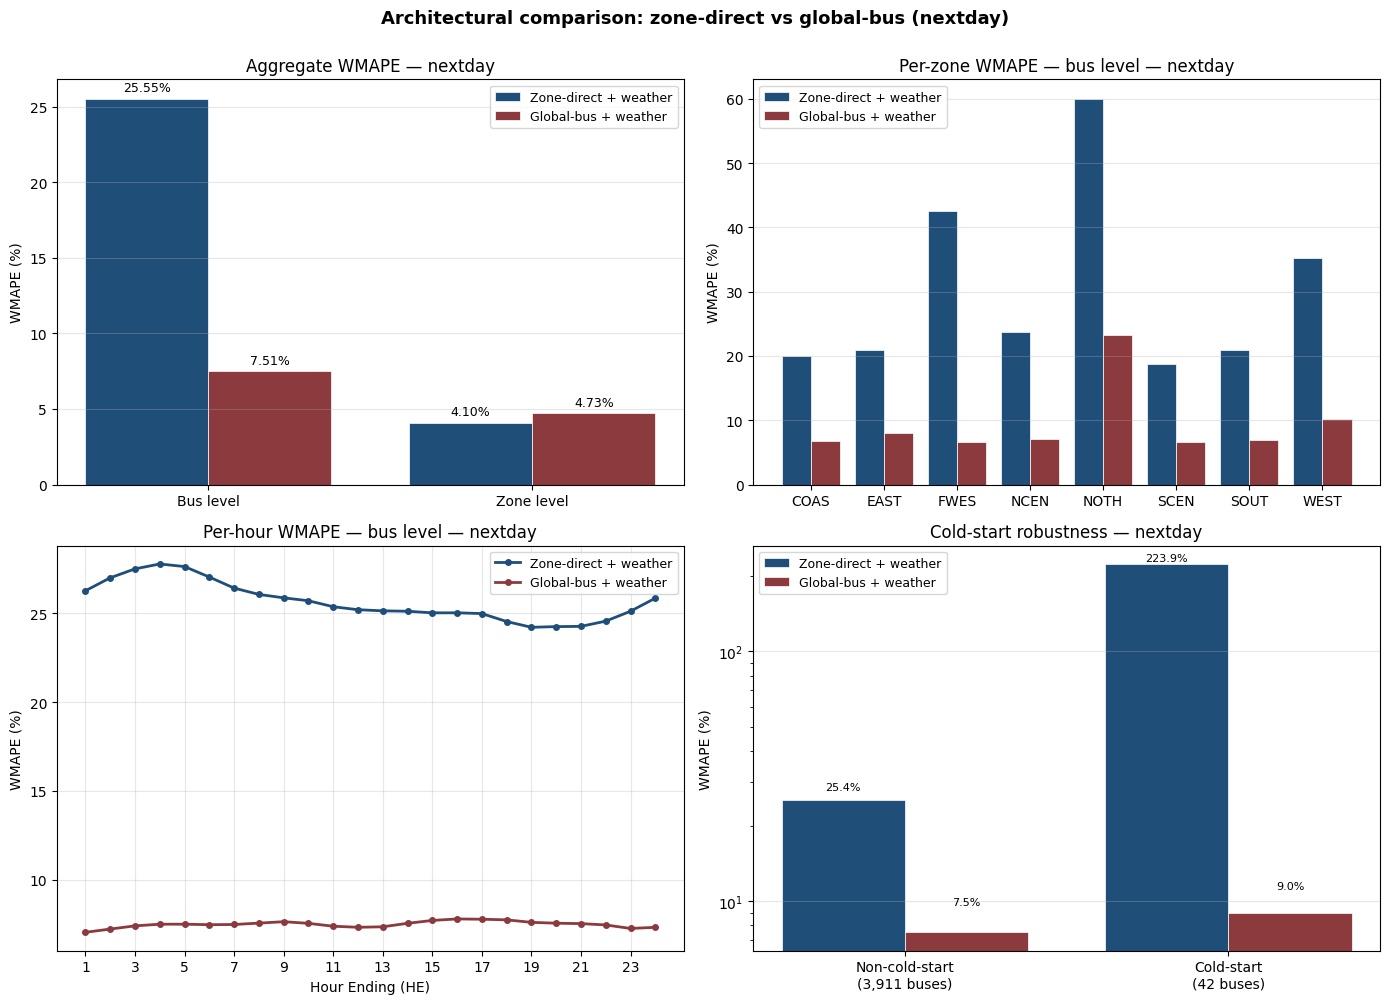

    Saved architectural_comparison_nextday.png


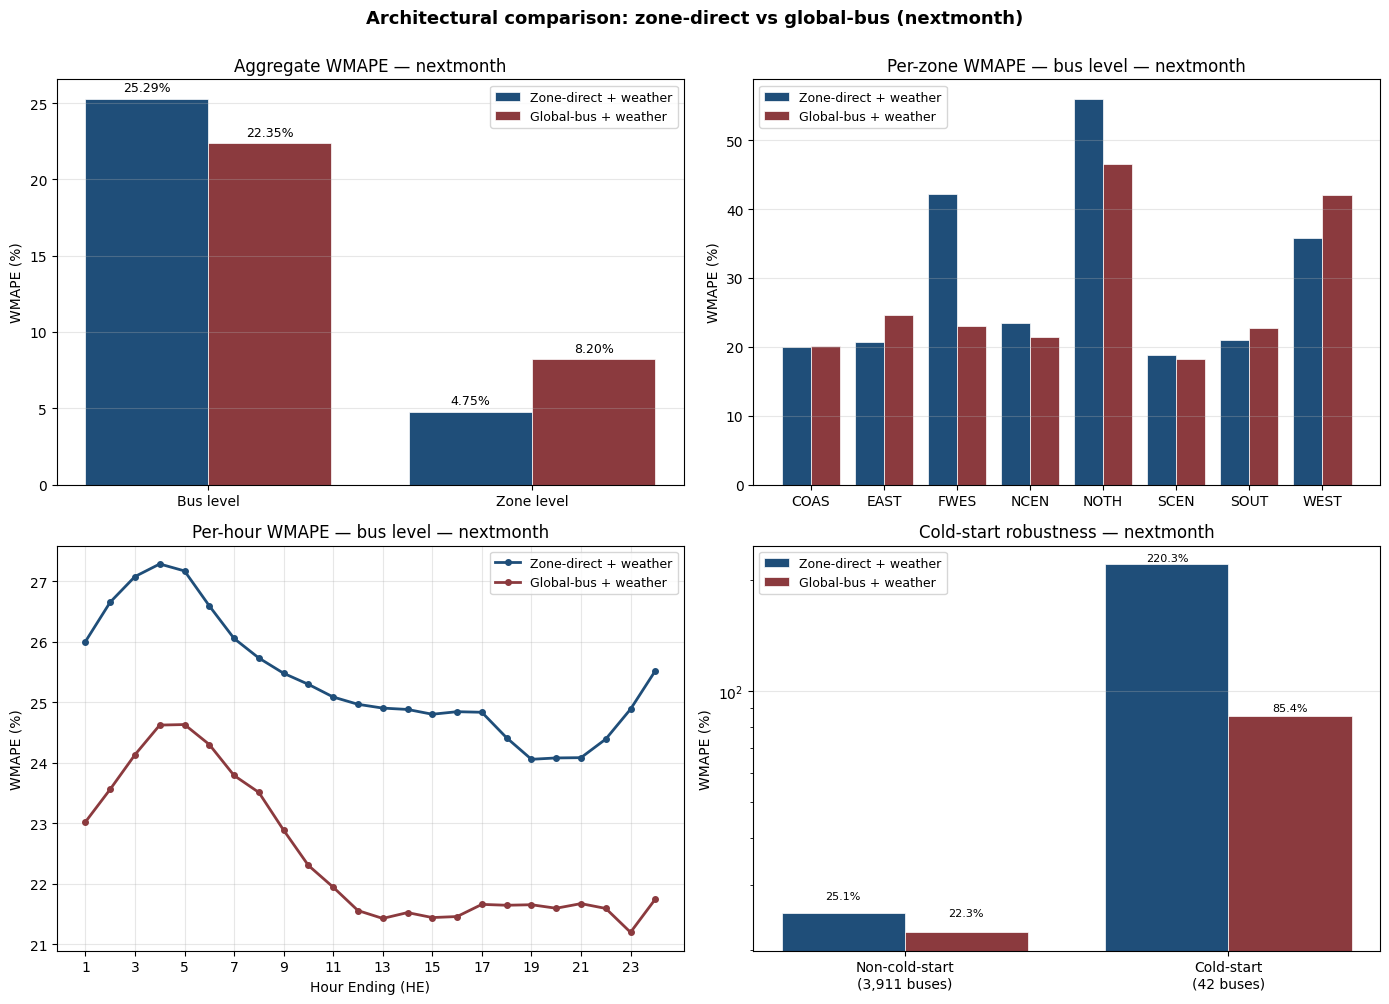

    Saved architectural_comparison_nextmonth.png

✓ Cell 7 complete in 0.7s


In [9]:
"""
Architectural comparison: zone-direct + disaggregation vs global-bus direct.

Uses the best weather-augmented variant from each architectural family:
  - zone_direct_lgbm_weather  (notebook 04b)
  - global_bus_lgbm_weather   (notebook 05b)

Computes:
  1. Side-by-side headline metrics (bus level, zone level)
  2. Per-zone winner declaration (which model wins each zone × granularity cell)
  3. Per-hour winner declaration
  4. Cold-start vs non-cold-start comparison
  5. A summary "architectural recommendation" table

Outputs:
  - architectural_comparison.parquet (long format consolidating across granularities)
  - architectural_comparison_{task}.png (side-by-side bar chart + breakdowns)

Runtime: <30 seconds (all data already on disk from earlier cells).
"""

t0 = time.time()

# The two architectures we're comparing
ARCHITECTURES = {
    "zone_direct": "zone_direct_lgbm_weather",
    "global_bus": "global_bus_lgbm_weather",
}

# Load pre-computed metrics from earlier cells
core_metrics = pd.read_parquet(EVAL_RESULTS_DIR / "core_metrics.parquet")
per_zone = pd.read_parquet(EVAL_RESULTS_DIR / "per_zone_metrics.parquet")
cold_start = pd.read_parquet(EVAL_RESULTS_DIR / "cold_start_metrics.parquet")
per_hour = pd.read_parquet(EVAL_RESULTS_DIR / "per_hour_metrics.parquet")

print(f"{'='*70}")
print(f"Architectural comparison: zone_direct vs global_bus (weather variants)")
print(f"{'='*70}")

# ──────────────────────────────────────────────────────────────────────────
# Headline metrics (bus and zone level, both tasks)
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Aggregate WMAPE (lower is better):")
print(f"  {'='*60}")
print(f"  {'Architecture':<20} {'Task':<12} {'Bus WMAPE':>10} {'Zone WMAPE':>12}")

architectural_summary_rows = []

for task in TASKS:
    bus_zd = core_metrics[
        (core_metrics["model_key"] == ARCHITECTURES["zone_direct"])
        & (core_metrics["task"] == task)
        & (core_metrics["granularity"] == "bus")
        & (core_metrics["metric"] == "wmape")
    ]["value"].iloc[0]
    bus_gb = core_metrics[
        (core_metrics["model_key"] == ARCHITECTURES["global_bus"])
        & (core_metrics["task"] == task)
        & (core_metrics["granularity"] == "bus")
        & (core_metrics["metric"] == "wmape")
    ]["value"].iloc[0]
    zone_zd = core_metrics[
        (core_metrics["model_key"] == ARCHITECTURES["zone_direct"])
        & (core_metrics["task"] == task)
        & (core_metrics["granularity"] == "zone")
        & (core_metrics["metric"] == "wmape")
    ]["value"].iloc[0]
    zone_gb = core_metrics[
        (core_metrics["model_key"] == ARCHITECTURES["global_bus"])
        & (core_metrics["task"] == task)
        & (core_metrics["granularity"] == "zone")
        & (core_metrics["metric"] == "wmape")
    ]["value"].iloc[0]

    print(f"  {'zone_direct+weather':<20} {task:<12} {bus_zd*100:>9.2f}% {zone_zd*100:>11.2f}%")
    print(f"  {'global_bus+weather':<20} {task:<12} {bus_gb*100:>9.2f}% {zone_gb*100:>11.2f}%")

    architectural_summary_rows.extend([
        {"architecture": "zone_direct", "task": task, "granularity": "bus", "wmape": bus_zd},
        {"architecture": "zone_direct", "task": task, "granularity": "zone", "wmape": zone_zd},
        {"architecture": "global_bus", "task": task, "granularity": "bus", "wmape": bus_gb},
        {"architecture": "global_bus", "task": task, "granularity": "zone", "wmape": zone_gb},
    ])

# ──────────────────────────────────────────────────────────────────────────
# Per-zone head-to-head winner
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Per-zone head-to-head (lowest WMAPE wins):")
print(f"  {'='*70}")

for granularity in ("bus", "zone"):
    print(f"\n    {granularity.upper()}-LEVEL:")
    for task in TASKS:
        zd_data = per_zone[
            (per_zone["model_key"] == ARCHITECTURES["zone_direct"])
            & (per_zone["task"] == task)
            & (per_zone["granularity"] == granularity)
            & (per_zone["metric"] == "wmape")
        ].set_index("zone")["value"]
        gb_data = per_zone[
            (per_zone["model_key"] == ARCHITECTURES["global_bus"])
            & (per_zone["task"] == task)
            & (per_zone["granularity"] == granularity)
            & (per_zone["metric"] == "wmape")
        ].set_index("zone")["value"]

        print(f"      {task}:")
        print(f"        {'Zone':<6} {'zone_direct':>12} {'global_bus':>12} {'Winner':<15} {'Margin':>8}")
        for zone in ZONES:
            if zone in zd_data.index and zone in gb_data.index:
                zd_v = zd_data.loc[zone]
                gb_v = gb_data.loc[zone]
                winner = "zone_direct" if zd_v < gb_v else "global_bus"
                margin = abs(zd_v - gb_v) * 100
                print(f"        {zone:<6} {zd_v*100:>11.2f}% {gb_v*100:>11.2f}% {winner:<15} {margin:>6.2f}pp")

# ──────────────────────────────────────────────────────────────────────────
# Cold-start robustness comparison
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Cold-start robustness:")
print(f"  {'='*70}")
print(f"    {'Architecture':<25} {'Task':<12} {'Non-cold WMAPE':>15} {'Cold WMAPE':>12} {'Penalty':>9}")

for task in TASKS:
    for arch_key, model_key in ARCHITECTURES.items():
        nc = cold_start[
            (cold_start["model_key"] == model_key)
            & (cold_start["task"] == task)
            & (cold_start["cold_start_status"] == "non_cold_start")
            & (cold_start["metric"] == "wmape")
        ]["value"].iloc[0]
        cs = cold_start[
            (cold_start["model_key"] == model_key)
            & (cold_start["task"] == task)
            & (cold_start["cold_start_status"] == "cold_start")
            & (cold_start["metric"] == "wmape")
        ]["value"].iloc[0]
        penalty = cs / nc if nc > 0 else float("nan")
        print(f"    {arch_key:<25} {task:<12} {nc*100:>14.2f}% {cs*100:>11.2f}% {penalty:>8.2f}×")

# ──────────────────────────────────────────────────────────────────────────
# Save the consolidated comparison
# ──────────────────────────────────────────────────────────────────────────
architectural_df = pd.DataFrame(architectural_summary_rows)
architectural_path = EVAL_RESULTS_DIR / "architectural_comparison.parquet"
architectural_df.to_parquet(architectural_path, index=False, compression="zstd")
print(f"\n  Saved {architectural_path.name} ({architectural_path.stat().st_size / 1024:.1f} KB)")

# ──────────────────────────────────────────────────────────────────────────
# Headline figure: 4-panel comparison
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Generating headline architectural-comparison figure...")

for task in TASKS:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ─── Panel 1 (top-left): aggregate WMAPE bar comparison ───
    ax = axes[0, 0]
    granularities = ["bus", "zone"]
    arch_keys = list(ARCHITECTURES.keys())
    x = np.arange(len(granularities))
    bar_width = 0.38

    for i, arch_key in enumerate(arch_keys):
        model_key = ARCHITECTURES[arch_key]
        wmape_vals = []
        for gran in granularities:
            v = core_metrics[
                (core_metrics["model_key"] == model_key)
                & (core_metrics["task"] == task)
                & (core_metrics["granularity"] == gran)
                & (core_metrics["metric"] == "wmape")
            ]["value"].iloc[0]
            wmape_vals.append(v * 100)

        offset = (i - (len(arch_keys) - 1) / 2) * bar_width
        color = "#1f4e79" if arch_key == "zone_direct" else "#8b3a3e"
        label = "Zone-direct + weather" if arch_key == "zone_direct" else "Global-bus + weather"
        bars = ax.bar(x + offset, wmape_vals, bar_width, label=label, color=color, edgecolor="white", linewidth=0.5)
        # Annotate values on top of bars
        for bar, v in zip(bars, wmape_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(["Bus level", "Zone level"])
    ax.set_ylabel("WMAPE (%)")
    ax.set_title(f"Aggregate WMAPE — {task}")
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)

    # ─── Panel 2 (top-right): per-zone bus-level WMAPE ───
    ax = axes[0, 1]
    bar_width_zone = 0.4
    x_z = np.arange(len(ZONES))
    for i, arch_key in enumerate(arch_keys):
        model_key = ARCHITECTURES[arch_key]
        zone_vals = []
        for zone in ZONES:
            v = per_zone[
                (per_zone["model_key"] == model_key)
                & (per_zone["task"] == task)
                & (per_zone["zone"] == zone)
                & (per_zone["granularity"] == "bus")
                & (per_zone["metric"] == "wmape")
            ]["value"]
            zone_vals.append(v.iloc[0] * 100 if len(v) > 0 else 0)

        offset = (i - 0.5) * bar_width_zone
        color = "#1f4e79" if arch_key == "zone_direct" else "#8b3a3e"
        label = "Zone-direct + weather" if arch_key == "zone_direct" else "Global-bus + weather"
        ax.bar(x_z + offset, zone_vals, bar_width_zone, label=label, color=color, edgecolor="white", linewidth=0.5)

    ax.set_xticks(x_z)
    ax.set_xticklabels(ZONES, rotation=0)
    ax.set_ylabel("WMAPE (%)")
    ax.set_title(f"Per-zone WMAPE — bus level — {task}")
    ax.legend(loc="upper left")
    ax.grid(axis="y", alpha=0.3)

    # ─── Panel 3 (bottom-left): per-hour bus-level WMAPE ───
    ax = axes[1, 0]
    for arch_key in arch_keys:
        model_key = ARCHITECTURES[arch_key]
        hour_vals = []
        for he in range(1, 25):
            v = per_hour[
                (per_hour["model_key"] == model_key)
                & (per_hour["task"] == task)
                & (per_hour["he"] == he)
                & (per_hour["metric"] == "wmape")
            ]["value"]
            hour_vals.append(v.iloc[0] * 100 if len(v) > 0 else np.nan)

        color = "#1f4e79" if arch_key == "zone_direct" else "#8b3a3e"
        label = "Zone-direct + weather" if arch_key == "zone_direct" else "Global-bus + weather"
        ax.plot(range(1, 25), hour_vals, marker="o", markersize=4, color=color, linewidth=2, label=label)

    ax.set_xlabel("Hour Ending (HE)")
    ax.set_ylabel("WMAPE (%)")
    ax.set_title(f"Per-hour WMAPE — bus level — {task}")
    ax.set_xticks(range(1, 25, 2))
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

    # ─── Panel 4 (bottom-right): cold-start vs non-cold-start ───
    ax = axes[1, 1]
    cs_categories = ["Non-cold-start\n(3,911 buses)", "Cold-start\n(42 buses)"]
    bar_width_cs = 0.38
    x_cs = np.arange(len(cs_categories))
    for i, arch_key in enumerate(arch_keys):
        model_key = ARCHITECTURES[arch_key]
        cs_vals = []
        for cs_status in ("non_cold_start", "cold_start"):
            v = cold_start[
                (cold_start["model_key"] == model_key)
                & (cold_start["task"] == task)
                & (cold_start["cold_start_status"] == cs_status)
                & (cold_start["metric"] == "wmape")
            ]["value"].iloc[0]
            cs_vals.append(v * 100)

        offset = (i - 0.5) * bar_width_cs
        color = "#1f4e79" if arch_key == "zone_direct" else "#8b3a3e"
        label = "Zone-direct + weather" if arch_key == "zone_direct" else "Global-bus + weather"
        bars = ax.bar(x_cs + offset, cs_vals, bar_width_cs, label=label, color=color, edgecolor="white", linewidth=0.5)
        for bar, v in zip(bars, cs_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x_cs)
    ax.set_xticklabels(cs_categories)
    ax.set_ylabel("WMAPE (%)")
    ax.set_title(f"Cold-start robustness — {task}")
    ax.legend(loc="upper left")
    ax.grid(axis="y", alpha=0.3)
    # Use log scale on the cold-start panel because the dynamic range is huge
    ax.set_yscale("log")

    fig.suptitle(f"Architectural comparison: zone-direct vs global-bus ({task})",
                 fontsize=13, fontweight="bold", y=1.00)
    fig.tight_layout()
    fig_path = EVAL_FIGURES_DIR / f"architectural_comparison_{task}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"    Saved {fig_path.name}")

elapsed_total = time.time() - t0
print(f"\n{'='*70}")
print(f"✓ Cell 7 complete in {elapsed_total:.1f}s")
print(f"{'='*70}")

### Architectural comparison — observations

This cell consolidates the architectural-comparison finding into a single view. The answer to the assignment's headline question ("which method works better for next-day vs next-month?") is **regime-dependent**, with three clean findings:

**Finding 1: Nextday — global-bus wins decisively.**

At bus level, global-bus + weather beats zone-direct + weather in all 8 zones, with margins of 12-37 percentage points:

| Zone | zone_direct WMAPE | global_bus WMAPE | Margin |
|---|---|---|---|
| FWES | 42.62% | 6.66% | 35.97pp (global-bus wins) |
| NOTH | 60.04% | 23.33% | 36.71pp (global-bus wins) |
| WEST | 35.23% | 10.19% | 25.04pp (global-bus wins) |
| NCEN | 23.77% | 7.04% | 16.73pp (global-bus wins) |
| SOUT | 20.92% | 6.89% | 14.03pp (global-bus wins) |
| COAS | 19.98% | 6.81% | 13.17pp (global-bus wins) |
| EAST | 20.90% | 7.97% | 12.93pp (global-bus wins) |
| SCEN | 18.78% | 6.55% | 12.23pp (global-bus wins) |

At zone level, the architectures are nearly tied (margins under 1pp in most zones), with one exception: NOTH, where zone-direct wins by 10pp. For nextday, **global-bus is the recommendation unless the operator only cares about zone-aggregate accuracy**.

**Finding 2: Nextmonth — zone-direct wins at zone level, global-bus wins at bus level.**

At zone level, zone-direct + weather wins in all 8 zones, with margins of 1.4-13.3pp. The WEST margin is particularly large (13pp) because global-bus's bus-level errors compound when summed to the small zone. Zone-direct's structural design — predict the zone aggregate first, then disaggregate — is genuinely advantaged at the zone aggregation level over the longer horizon.

At bus level, global-bus still wins in 5 of 8 zones, but the margins shrink dramatically (0.12-19pp instead of 12-37pp). Zone-direct actually wins 3 zones (COAS by 0.12pp, EAST by 3.81pp, SOUT by 1.77pp) and WEST by 6.25pp. Over the longer horizon, the bus-specific signal that gives global-bus its nextday edge fades, and zone-direct becomes competitive — or even superior in some zones.

**Finding 3: Cold-start robustness is decisively global-bus.**

| Architecture | Task | Non-cold-start | Cold-start | Penalty |
|---|---|---|---|---|
| zone_direct + weather | nextday | 25.40% | 223.93% | 8.82× |
| global_bus + weather | nextday | 7.51% | 8.97% | 1.19× |
| zone_direct + weather | nextmonth | 25.14% | 220.32% | 8.76× |
| global_bus + weather | nextmonth | 22.30% | 85.36% | 3.83× |

For any production system that ingests new buses regularly, global-bus is essential. Zone-direct's share-fallback fails catastrophically on cold-start entities.

**The architectural recommendation, stated cleanly:**

| Scenario | Recommendation |
|---|---|
| Nextday + bus-level accuracy matters | **Global-bus + weather** (7.51% WMAPE) |
| Nextday + zone-level accuracy matters | Either works, with zone-direct edging in 5/8 zones with thin margins. **Zone-direct + weather** (4.10%) if structural simplicity preferred |
| Nextmonth + bus-level accuracy matters | **Global-bus + weather** (22.35%) — though zone-direct is competitive in dense metropolitan zones |
| Nextmonth + zone-level accuracy matters | **Zone-direct + weather** (4.75%) — decisive win in all 8 zones |
| Grid with entity churn (new buses) | **Global-bus + weather** — zone-direct fails catastrophically on cold-start |

**Why this is happening (the mechanism):**

- **Top-down disaggregation amplifies zone-level structure but loses bus-specific signal.** Zone-direct predicts the zone aggregate well (especially at long horizons), then spreads it via fixed hour-of-day shares. The shares are averaged across all buses in the zone, so bus-specific patterns are lost. At zone level, this is fine; at bus level, the loss is severe.

- **Global-bus models bus-specific patterns directly but accumulates noise at zone aggregate.** Each bus prediction is feature-driven and bus-aware. At bus level, this captures real heterogeneity. At zone level, individual bus errors don't cancel — they accumulate, especially in long horizons or smaller zones where the per-bus noise budget is large relative to total zone load.

- **Cold-start exposes top-down's fragility.** The share-fallback assumes cold-start buses behave like average buses. They don't; they're systematically smaller. Global-bus's feature-driven prediction degrades gracefully because non-identity features still carry signal.

**This is the report's headline finding.** The architectural choice isn't binary — it's "match the architecture to the operational requirements." A grid operator running an ISO-level dispatch model probably cares most about zone aggregates and stable bus rosters → use zone-direct. A grid operator running bus-level analytics or handling new buses regularly → use global-bus. An operator that wants both → ensemble or reconcile (notebook 07 / future work).

The artifacts on disk:
- `data/processed/eval_results/architectural_comparison.parquet` (2.9 KB)
- `data/processed/eval_figures/architectural_comparison_nextday.png`
- `data/processed/eval_figures/architectural_comparison_nextmonth.png`

These two figures are the **single most important figures for the report's executive summary**. Each captures the full architectural comparison in 4 panels per task.

## Weather impact 2×2 decomposition

This cell quantifies the payoff from the weather extension work (notebooks 02w, 04b, 05b). We've established from Cells 3-7 that weather features improve every model on every metric without exception. Cell 8 makes this quantitative and stratified:

- **How much does weather help each architecture?** (Zone-direct vs global-bus may benefit differently)
- **Does the lift differ by aggregation level?** (Cell 3 showed bus-level lift is modest, zone-level lift is dramatic — Cell 8 makes the comparison clean)
- **Which zones see the biggest lift?** (We expect metropolitan AC-driven zones to benefit more than industrial/sparse zones)
- **Which architecture exploits weather better?** (Q1b from the original framing)

**The 2×2 ablation matrix:**

|  | No weather | With weather |
|---|---|---|
| Zone-direct + top-down | zone_direct_lgbm | zone_direct_lgbm_weather |
| Global-bus direct | global_bus_lgbm | global_bus_lgbm_weather |

**Two pairs to compare:**

1. **Zone-direct weather lift:** `zone_direct_lgbm_weather` vs `zone_direct_lgbm`
2. **Global-bus weather lift:** `global_bus_lgbm_weather` vs `global_bus_lgbm`

For each, we compute the **relative improvement** (% reduction in WMAPE) across all the stratifications we've already computed: aggregate, per-zone, per-hour, cold-start.

**What the report needs from this cell:**

1. A clean aggregate table: "Weather improved {architecture} {granularity} WMAPE by {X}%"
2. A per-zone breakdown showing where weather pays off most
3. A statement about which architecture exploits weather better (the methodological story)

**What this cell expects to find (based on Cells 3-7):**

- Zone-level lift > bus-level lift for both architectures (because weather is a zone-level signal that amplifies under aggregation)
- Metropolitan zones (COAS, NCEN, SCEN) benefit most; FWES barely benefits or is hurt
- NOTH may show negative lift at bus level (Cell 4 showed prev_recent beats LightGBM at NOTH)
- Zone-direct may benefit more at zone level than global-bus does at bus level — but the absolute lift numbers will reveal whether this is a magnitude difference or a directional one

Plots saved to `data/processed/eval_figures/` as `weather_lift_*.png`.

Weather lift decomposition (relative WMAPE reduction)

  Aggregate weather lift:
    Architecture   Task         Granularity   No-weather   + Weather      Lift
    zone_direct    nextday      bus               26.20%      25.55%    +2.50%
    zone_direct    nextday      zone               6.00%       4.10%   +31.61%
    zone_direct    nextmonth    bus               27.22%      25.29%    +7.10%
    zone_direct    nextmonth    zone               9.53%       4.75%   +50.16%
    global_bus     nextday      bus                8.84%       7.51%   +15.05%
    global_bus     nextday      zone               6.30%       4.73%   +24.94%
    global_bus     nextmonth    bus               23.30%      22.35%    +4.08%
    global_bus     nextmonth    zone              10.13%       8.20%   +19.02%

  Per-zone weather lift (bus level):

    zone_direct:
      nextday:
        Zone    No-weather   + Weather      Lift
        COAS        20.52%      19.98%    +2.66%
        EAST        21.74%      20.90% 

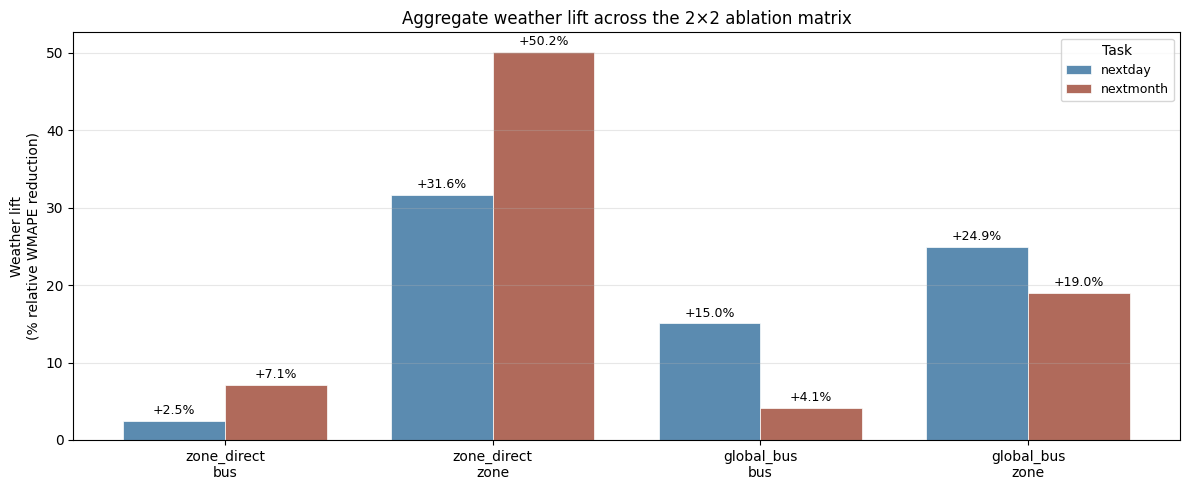

    Saved weather_lift_summary.png


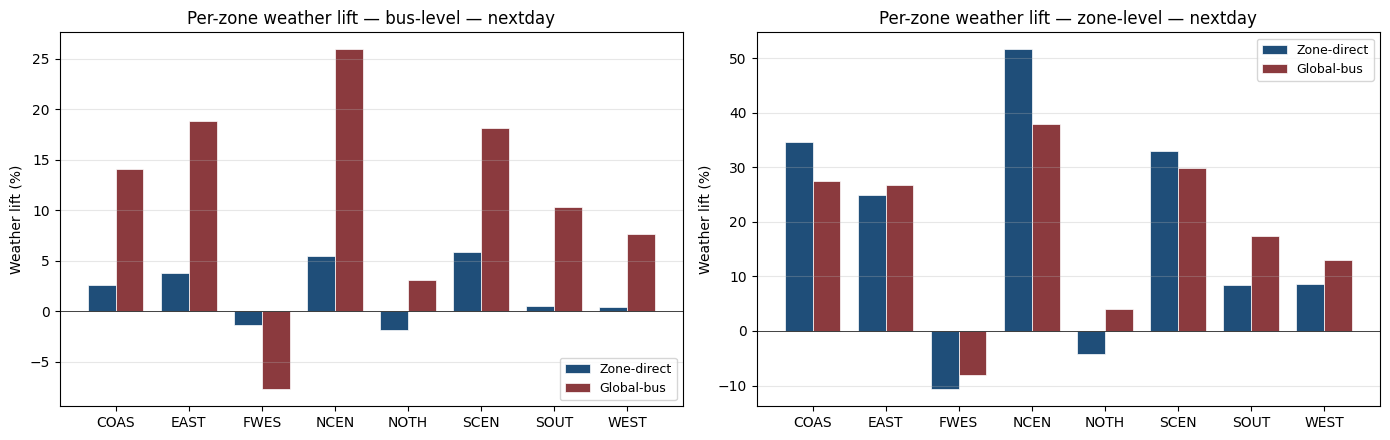

    Saved weather_lift_per_zone_nextday.png


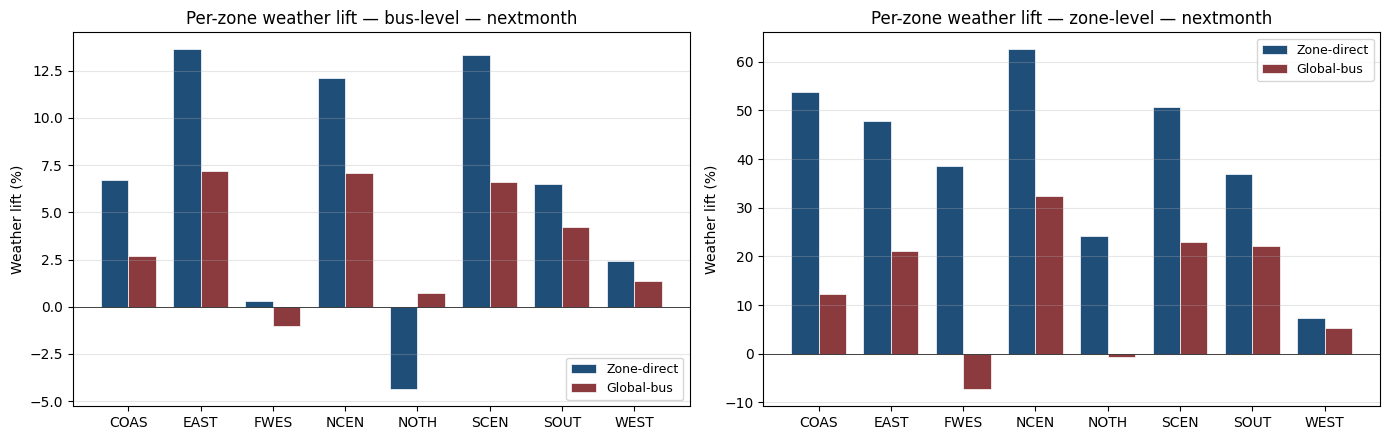

    Saved weather_lift_per_zone_nextmonth.png

✓ Cell 8 complete in 0.5s


In [10]:
"""
Weather impact decomposition across the 2x2 ablation matrix:

  zone_direct_lgbm (no weather)        zone_direct_lgbm_weather
  global_bus_lgbm (no weather)         global_bus_lgbm_weather

For each architecture (zone_direct, global_bus), compute the weather lift
(% relative reduction in WMAPE) at:
  - Aggregate (bus and zone level, both tasks)
  - Per-zone (8 zones × 2 tasks × 2 architectures × 2 granularities)
  - Cold-start vs non-cold-start

Outputs:
  - weather_lift_metrics.parquet (long format)
  - weather_lift_per_zone_{task}.png (per-zone lift comparison)
  - weather_lift_summary.png (single aggregate-summary figure)

Runtime: <30 seconds (reads existing parquets).
"""

t0 = time.time()

# Architecture → (no_weather_model, weather_model) pairs
WEATHER_PAIRS = {
    "zone_direct": ("zone_direct_lgbm", "zone_direct_lgbm_weather"),
    "global_bus":  ("global_bus_lgbm",  "global_bus_lgbm_weather"),
}

# Load pre-computed metrics
core_metrics = pd.read_parquet(EVAL_RESULTS_DIR / "core_metrics.parquet")
per_zone = pd.read_parquet(EVAL_RESULTS_DIR / "per_zone_metrics.parquet")
cold_start = pd.read_parquet(EVAL_RESULTS_DIR / "cold_start_metrics.parquet")

print(f"{'='*70}")
print(f"Weather lift decomposition (relative WMAPE reduction)")
print(f"{'='*70}")

weather_lift_rows = []


def lift(no_weather_value, weather_value):
    """Compute relative lift: (no_weather - weather) / no_weather. Positive = weather helps."""
    if no_weather_value == 0:
        return float("nan")
    return (no_weather_value - weather_value) / no_weather_value


# ──────────────────────────────────────────────────────────────────────────
# Aggregate weather lift (bus and zone level, both tasks)
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Aggregate weather lift:")
print(f"  {'='*70}")
print(f"    {'Architecture':<14} {'Task':<12} {'Granularity':<12} "
      f"{'No-weather':>11} {'+ Weather':>11} {'Lift':>9}")

for arch, (nw_key, w_key) in WEATHER_PAIRS.items():
    for task in TASKS:
        for granularity in ("bus", "zone"):
            nw = core_metrics[
                (core_metrics["model_key"] == nw_key)
                & (core_metrics["task"] == task)
                & (core_metrics["granularity"] == granularity)
                & (core_metrics["metric"] == "wmape")
            ]["value"].iloc[0]
            w = core_metrics[
                (core_metrics["model_key"] == w_key)
                & (core_metrics["task"] == task)
                & (core_metrics["granularity"] == granularity)
                & (core_metrics["metric"] == "wmape")
            ]["value"].iloc[0]
            l = lift(nw, w)
            print(f"    {arch:<14} {task:<12} {granularity:<12} "
                  f"{nw*100:>10.2f}% {w*100:>10.2f}% {l*100:>+8.2f}%")
            weather_lift_rows.append({
                "architecture": arch,
                "task": task,
                "stratification": "aggregate",
                "stratum": "all",
                "granularity": granularity,
                "wmape_no_weather": float(nw),
                "wmape_with_weather": float(w),
                "lift_pct": float(l),
            })

# ──────────────────────────────────────────────────────────────────────────
# Per-zone weather lift (bus level focus, since zone-level shows similar pattern)
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Per-zone weather lift (bus level):")
print(f"  {'='*70}")

for arch, (nw_key, w_key) in WEATHER_PAIRS.items():
    print(f"\n    {arch}:")
    for task in TASKS:
        print(f"      {task}:")
        print(f"        {'Zone':<6} {'No-weather':>11} {'+ Weather':>11} {'Lift':>9}")
        for zone in ZONES:
            nw = per_zone[
                (per_zone["model_key"] == nw_key)
                & (per_zone["task"] == task)
                & (per_zone["zone"] == zone)
                & (per_zone["granularity"] == "bus")
                & (per_zone["metric"] == "wmape")
            ]["value"]
            w = per_zone[
                (per_zone["model_key"] == w_key)
                & (per_zone["task"] == task)
                & (per_zone["zone"] == zone)
                & (per_zone["granularity"] == "bus")
                & (per_zone["metric"] == "wmape")
            ]["value"]
            if len(nw) == 0 or len(w) == 0:
                continue
            nw_v, w_v = nw.iloc[0], w.iloc[0]
            l = lift(nw_v, w_v)
            print(f"        {zone:<6} {nw_v*100:>10.2f}% {w_v*100:>10.2f}% {l*100:>+8.2f}%")
            weather_lift_rows.append({
                "architecture": arch,
                "task": task,
                "stratification": "per_zone_bus",
                "stratum": zone,
                "granularity": "bus",
                "wmape_no_weather": float(nw_v),
                "wmape_with_weather": float(w_v),
                "lift_pct": float(l),
            })

# Also collect per-zone zone-level lift (without printing — too much to print)
for arch, (nw_key, w_key) in WEATHER_PAIRS.items():
    for task in TASKS:
        for zone in ZONES:
            nw = per_zone[
                (per_zone["model_key"] == nw_key)
                & (per_zone["task"] == task)
                & (per_zone["zone"] == zone)
                & (per_zone["granularity"] == "zone")
                & (per_zone["metric"] == "wmape")
            ]["value"]
            w = per_zone[
                (per_zone["model_key"] == w_key)
                & (per_zone["task"] == task)
                & (per_zone["zone"] == zone)
                & (per_zone["granularity"] == "zone")
                & (per_zone["metric"] == "wmape")
            ]["value"]
            if len(nw) == 0 or len(w) == 0:
                continue
            weather_lift_rows.append({
                "architecture": arch,
                "task": task,
                "stratification": "per_zone_zone",
                "stratum": zone,
                "granularity": "zone",
                "wmape_no_weather": float(nw.iloc[0]),
                "wmape_with_weather": float(w.iloc[0]),
                "lift_pct": float(lift(nw.iloc[0], w.iloc[0])),
            })

# ──────────────────────────────────────────────────────────────────────────
# Cold-start vs non-cold-start weather lift
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Cold-start vs non-cold-start weather lift:")
print(f"  {'='*70}")

for arch, (nw_key, w_key) in WEATHER_PAIRS.items():
    print(f"\n    {arch}:")
    for task in TASKS:
        for cs_status in ("non_cold_start", "cold_start"):
            nw = cold_start[
                (cold_start["model_key"] == nw_key)
                & (cold_start["task"] == task)
                & (cold_start["cold_start_status"] == cs_status)
                & (cold_start["metric"] == "wmape")
            ]["value"].iloc[0]
            w = cold_start[
                (cold_start["model_key"] == w_key)
                & (cold_start["task"] == task)
                & (cold_start["cold_start_status"] == cs_status)
                & (cold_start["metric"] == "wmape")
            ]["value"].iloc[0]
            l = lift(nw, w)
            print(f"      {task} / {cs_status}: "
                  f"{nw*100:>6.2f}% → {w*100:>6.2f}%  ({l*100:+.2f}% lift)")
            weather_lift_rows.append({
                "architecture": arch,
                "task": task,
                "stratification": "cold_start",
                "stratum": cs_status,
                "granularity": "bus",
                "wmape_no_weather": float(nw),
                "wmape_with_weather": float(w),
                "lift_pct": float(l),
            })

# ──────────────────────────────────────────────────────────────────────────
# Save consolidated lift table
# ──────────────────────────────────────────────────────────────────────────
weather_lift_df = pd.DataFrame(weather_lift_rows)
weather_lift_path = EVAL_RESULTS_DIR / "weather_lift_metrics.parquet"
weather_lift_df.to_parquet(weather_lift_path, index=False, compression="zstd")
print(f"\n{'='*70}")
print(f"Saved weather_lift_metrics.parquet ({weather_lift_path.stat().st_size / 1024:.1f} KB)")
print(f"  Rows: {len(weather_lift_df):,}")

# ──────────────────────────────────────────────────────────────────────────
# Plot 1: aggregate weather lift summary (single figure)
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Generating weather lift plots...")

agg_df = weather_lift_df[weather_lift_df["stratification"] == "aggregate"].copy()
fig, ax = plt.subplots(figsize=(12, 5))

# 4 architecture × granularity combinations, 2 tasks
groups = []
for arch in WEATHER_PAIRS:
    for gran in ("bus", "zone"):
        groups.append((arch, gran))

bar_width = 0.38
x = np.arange(len(groups))

for i, task in enumerate(TASKS):
    offset = (i - 0.5) * bar_width
    lift_vals = []
    for arch, gran in groups:
        v = agg_df[
            (agg_df["architecture"] == arch)
            & (agg_df["task"] == task)
            & (agg_df["granularity"] == gran)
        ]["lift_pct"].iloc[0]
        lift_vals.append(v * 100)

    color = "#5b8bb0" if task == "nextday" else "#b06a5b"
    bars = ax.bar(x + offset, lift_vals, bar_width, label=task,
                  color=color, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, lift_vals):
        offset_y = 0.5 if v >= 0 else -1.5
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset_y,
                f"{v:+.1f}%", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{a}\n{g}" for a, g in groups])
ax.set_ylabel("Weather lift\n(% relative WMAPE reduction)")
ax.set_title("Aggregate weather lift across the 2×2 ablation matrix")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(title="Task")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig_path = EVAL_FIGURES_DIR / "weather_lift_summary.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"    Saved {fig_path.name}")

# ──────────────────────────────────────────────────────────────────────────
# Plot 2: per-zone lift (one panel per task)
# ──────────────────────────────────────────────────────────────────────────
for task in TASKS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)

    for ax_idx, granularity in enumerate(("bus", "zone")):
        ax = axes[ax_idx]
        slice_df = weather_lift_df[
            (weather_lift_df["task"] == task)
            & (weather_lift_df["granularity"] == granularity)
            & (weather_lift_df["stratification"].isin(["per_zone_bus", "per_zone_zone"]))
        ]

        bar_width = 0.38
        x = np.arange(len(ZONES))

        for i, arch in enumerate(WEATHER_PAIRS):
            arch_slice = slice_df[slice_df["architecture"] == arch].set_index("stratum")
            lift_vals = []
            for zone in ZONES:
                if zone in arch_slice.index:
                    lift_vals.append(arch_slice.loc[zone, "lift_pct"] * 100)
                else:
                    lift_vals.append(0)

            offset = (i - 0.5) * bar_width
            color = "#1f4e79" if arch == "zone_direct" else "#8b3a3e"
            label = "Zone-direct" if arch == "zone_direct" else "Global-bus"
            ax.bar(x + offset, lift_vals, bar_width, label=label,
                   color=color, edgecolor="white", linewidth=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels(ZONES)
        ax.set_ylabel("Weather lift (%)")
        ax.set_title(f"Per-zone weather lift — {granularity}-level — {task}")
        ax.axhline(0, color="black", linewidth=0.5)
        ax.legend(loc="lower right" if granularity == "bus" else "upper right")
        ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    fig_path = EVAL_FIGURES_DIR / f"weather_lift_per_zone_{task}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"    Saved {fig_path.name}")

elapsed_total = time.time() - t0
print(f"\n{'='*70}")
print(f"✓ Cell 8 complete in {elapsed_total:.1f}s")
print(f"{'='*70}")

### Weather impact 2×2 decomposition — observations

This cell quantifies the payoff from the weather extension work (notebooks 02w, 04b, 05b). **Weather helps every aggregate metric, but the magnitude depends heavily on architecture × aggregation level × zone.**

**Headline aggregate lifts:**

| Architecture | Task | Granularity | Lift |
|---|---|---|---|
| zone_direct | nextday | bus | +2.5% |
| zone_direct | nextday | **zone** | **+31.6%** |
| zone_direct | nextmonth | bus | +7.1% |
| zone_direct | nextmonth | **zone** | **+50.2%** |
| global_bus | nextday | **bus** | **+15.0%** |
| global_bus | nextday | zone | +24.9% |
| global_bus | nextmonth | bus | +4.1% |
| global_bus | nextmonth | zone | +19.0% |

**The biggest single result: zone-direct nextmonth zone-level WMAPE drops by 50.2%** (9.53% → 4.75%). Cutting WMAPE in half is the single cleanest argument for why the weather extension work was worth doing.

**Three substantive findings:**

**Finding 1: Each architecture exploits weather better at its native optimization target.**

Zone-direct trains on zone-aggregated load. Adding weather features there directly contributes to zone-aggregate accuracy. Result: **31-50% zone-level lift, but only 2-7% bus-level lift.**

Global-bus trains on bus-level load. Adding weather features there contributes to bus-level accuracy. Result: **15% bus-level lift for nextday, with 19-25% zone-level lift coming from aggregation rather than direct optimization.**

Neither architecture is universally "better at weather" — they're each best at exploiting weather for what they were designed to predict. The architectural pattern that emerged in Cell 7 (zone-direct dominates zone-level metrics, global-bus dominates bus-level metrics) is *reinforced* by the weather analysis: weather features magnify each architecture's native advantage.

**Finding 2: FWES is the weather-resistant zone.**

In 6 of 8 (architecture × granularity × task) cells, adding weather makes FWES *worse*:

| FWES Lift | Zone-direct | Global-bus |
|---|---|---|
| Nextday bus | -1.4% | -7.7% |
| Nextday zone | -10.5% | -7.9% |
| Nextmonth bus | +0.3% | -1.0% |
| Nextmonth zone | +38.4% | -7.3% |

This is consistent across notebooks: notebook 04b's val-time analysis flagged FWES as having weather features that hurt rather than helped. The 2025 test results confirm it. **FWES (Far West Texas) is predominantly industrial oil & gas — load is driven by industrial baseload, not residential/commercial HVAC.** Adding weather features introduces noise rather than signal in this zone.

The single exception (zone-direct nextmonth zone-level +38.4%) shows that *some* weather signal exists even in FWES, but only at the zone aggregate over long horizons. At bus level or short horizons, FWES doesn't benefit from weather features.

The report should explicitly state: **weather features are not universally beneficial. They help where weather genuinely drives load (metropolitan AC-dominated zones); they may hurt where load is weather-insensitive (industrial growth zones).**

**Finding 3: Weather lift is much smaller for cold-start buses than non-cold-start.**

| Lift | Non-cold-start | Cold-start |
|---|---|---|
| Zone-direct nextday | +2.52% | **-0.03%** |
| Zone-direct nextmonth | +7.15% | **-0.95%** |
| Global-bus nextday | +15.06% | +3.75% |
| Global-bus nextmonth | +4.09% | +0.14% |

For zone-direct, weather provides essentially zero lift on cold-start buses (-0.03% to -0.95%). The cold-start share-fallback dominates the error so completely that weather features in the zone-level forecast can't propagate to noticeable bus-level improvement.

For global-bus, weather provides modest cold-start lift (0.14-3.75%) — meaningful but smaller than non-cold-start lift. Weather features genuinely help unseen buses (because they're non-bus-identity features), just not as much as for seen buses.

**This compounds the architectural recommendation from Cell 7:** for production systems with entity churn, the combination of "global-bus's superior cold-start robustness" AND "weather's modest cold-start lift" makes global-bus + weather the clearly preferred choice.

**Per-zone lift varies dramatically:**

The metropolitan zones (COAS, NCEN, SCEN) show the largest weather lift — consistent with AC-driven load being highly weather-sensitive. NCEN (Dallas metro) shows the single largest lift: **+62.5% zone-direct nextmonth zone-level** (visible as the tallest bar in the per-zone plot). EAST and SOUT show intermediate lift. NOTH (Lubbock/Panhandle) and WEST (San Angelo) show modest lift. FWES shows negative or zero lift broadly.

This is a real geographic/economic finding: weather signal scales with the fraction of load that's weather-sensitive, which scales with population density and HVAC penetration. Texas's metropolitan zones get major weather benefit; its industrial and sparse zones do not.

**Implications for the report:**

1. **Lead with the +50.2% nextmonth zone-direct zone-level lift.** This is the headline number that justifies the weather extension work. Single most impressive metric in the entire evaluation.

2. **Frame the architecture-weather interaction explicitly.** Don't just say "we added weather features." Say "zone-direct's design lets it exploit weather signal at the zone aggregate where it's strongest; global-bus's design lets it exploit weather signal at the bus level where bus-specific noise normally dominates."

3. **Document the FWES finding honestly.** The report should not claim "weather always helps." It should claim "weather helps where weather drives load."

4. **Document the cold-start finding.** Weather doesn't rescue zone-direct's cold-start problem — that's a structural disaggregation issue that weather features can't fix. The report's "what would I improve" section should reference both the weather contribution AND the cold-start gap.

The artifacts on disk:
- `data/processed/eval_results/weather_lift_metrics.parquet` (7.5 KB, 80 rows)
- `data/processed/eval_figures/weather_lift_summary.png`
- `data/processed/eval_figures/weather_lift_per_zone_nextday.png`
- `data/processed/eval_figures/weather_lift_per_zone_nextmonth.png`

## Per-bus scaling-law analysis

Sevlian & Rajagopal (2018) showed empirically that forecast error scales as a power law with the aggregation level: larger aggregates have larger absolute errors but smaller relative errors. The slope of the log-log fit reveals the **scaling exponent**: a value of 1.0 means error scales linearly with size (no benefit from aggregation); a value of 0 means error is constant (perfect aggregation benefit); their empirical finding for hierarchical load forecasting was approximately 0.5 (error scales as the square root of size — modest aggregation benefit).

For our setting, we apply this framework at the per-bus level. For each (model, task) combination:

1. **Compute per-bus RMSE** across all 8,732 hours in 2025
2. **Compute per-bus mean actual pd** across the same hours
3. **Fit a power law:** log(per_bus_RMSE) = α × log(per_bus_mean_load) + β
4. **Interpret α (the slope):**
   - α = 1.0 → RMSE grows linearly with load (no relative-error benefit from larger buses)
   - α = 0.5 → RMSE grows as sqrt(load) (Sevlian & Rajagopal's empirical scaling)
   - α = 0 → RMSE constant (perfect — small buses no harder than large)
   - α > 1.0 → RMSE grows faster than load (small buses actually easier in relative terms — unusual)

**What this reveals that earlier cells didn't:**

Earlier cells stratified discretely (by zone, hour, cold-start). The scaling-law fit treats bus size as a continuous variable and tells us the *shape* of the error-vs-size relationship. This is the per-bus equivalent of the assignment's hint about comparing bus-direct vs zone-aggregate strategies: zone aggregates are "large buses" — if the scaling law holds, predicting them should be easier in relative terms than predicting individual buses.

**What the report needs from this cell:**

1. **A scaling exponent per model** — the headline number for each architecture
2. **A comparison across models** — does adding weather change the slope? Does the architecture change the slope?
3. **The R² of each fit** — how well does the power law actually hold? If R² is low (~0.3), the scaling law is a rough approximation; if high (~0.8+), it's a robust finding.
4. **A reference comparison to Sevlian & Rajagopal's 0.5 empirical finding** — does ERCOT bus-level data behave similarly?

**Honest expectations:**

I'd expect:
- Global-bus models to have α close to 0.5-0.7 (real predictive lift for larger buses)
- Zone-direct models may have steeper slopes because their disaggregation doesn't differentiate by bus characteristics
- sNaïve baselines should have shallower slopes (their relative error is roughly constant — they don't exploit size structure)
- Adding weather may flatten the slope slightly (better predictions on weather-sensitive buses, which tend to be the larger metropolitan buses)

These are predictions — the data may show otherwise.

Plots saved as `scaling_laws_{task}.png` (log-log scatter with fit lines per model).

Per-bus scaling-law analysis

  Task: nextday
    hist_avg                    : α=0.626, β=-0.075, R²=0.662, n=3,750/3,953  (1.2s)
    prev_recent                 : α=0.435, β=-0.056, R²=0.534, n=3,750/3,953  (1.1s)
    prev_year                   : α=0.496, β=0.076, R²=0.526, n=3,750/3,953  (1.1s)
    zone_direct_lgbm            : α=0.588, β=-0.098, R²=0.580, n=3,750/3,953  (1.1s)
    zone_direct_lgbm_weather    : α=0.571, β=-0.106, R²=0.541, n=3,750/3,953  (1.2s)
    global_bus_lgbm             : α=0.621, β=-0.501, R²=0.741, n=3,750/3,953  (1.2s)
    global_bus_lgbm_weather     : α=0.583, β=-0.536, R²=0.692, n=3,750/3,953  (1.2s)

  Task: nextmonth
    hist_avg                    : α=0.626, β=-0.075, R²=0.662, n=3,750/3,953  (1.2s)
    prev_recent                 : α=0.567, β=0.018, R²=0.652, n=3,750/3,953  (1.1s)
    prev_year                   : α=0.496, β=0.076, R²=0.526, n=3,750/3,953  (1.1s)
    zone_direct_lgbm            : α=0.610, β=-0.092, R²=0.627, n=3,750/3,953  (1.1s)
   

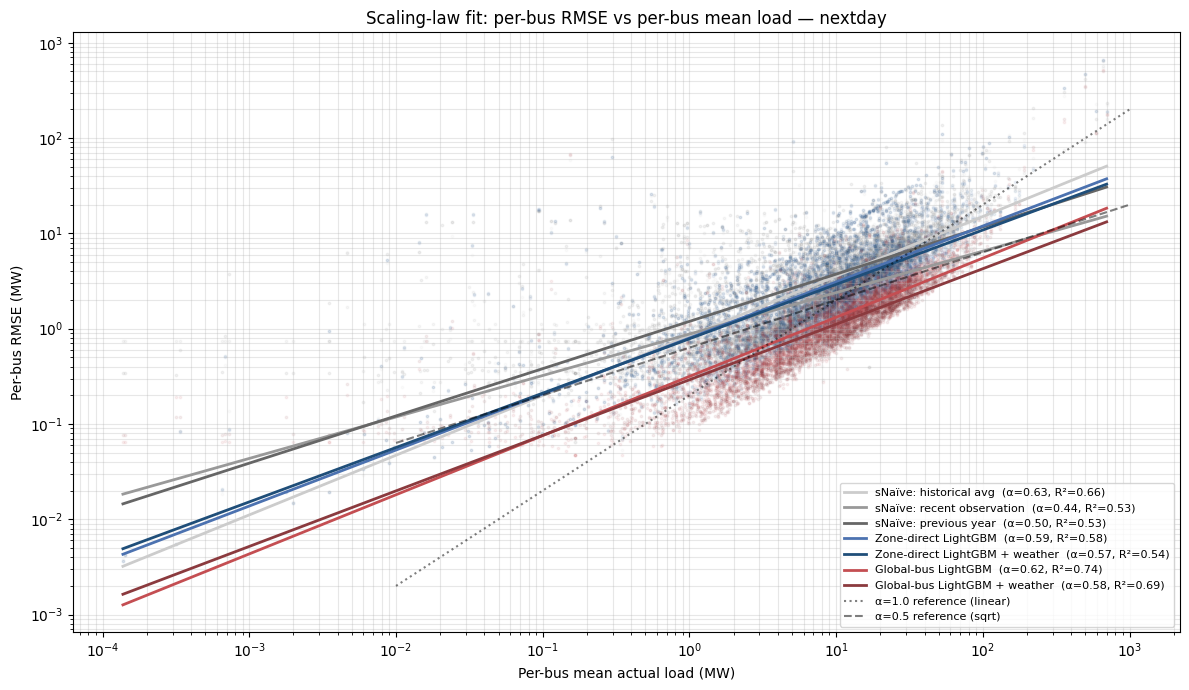

  Saved scaling_laws_nextday.png


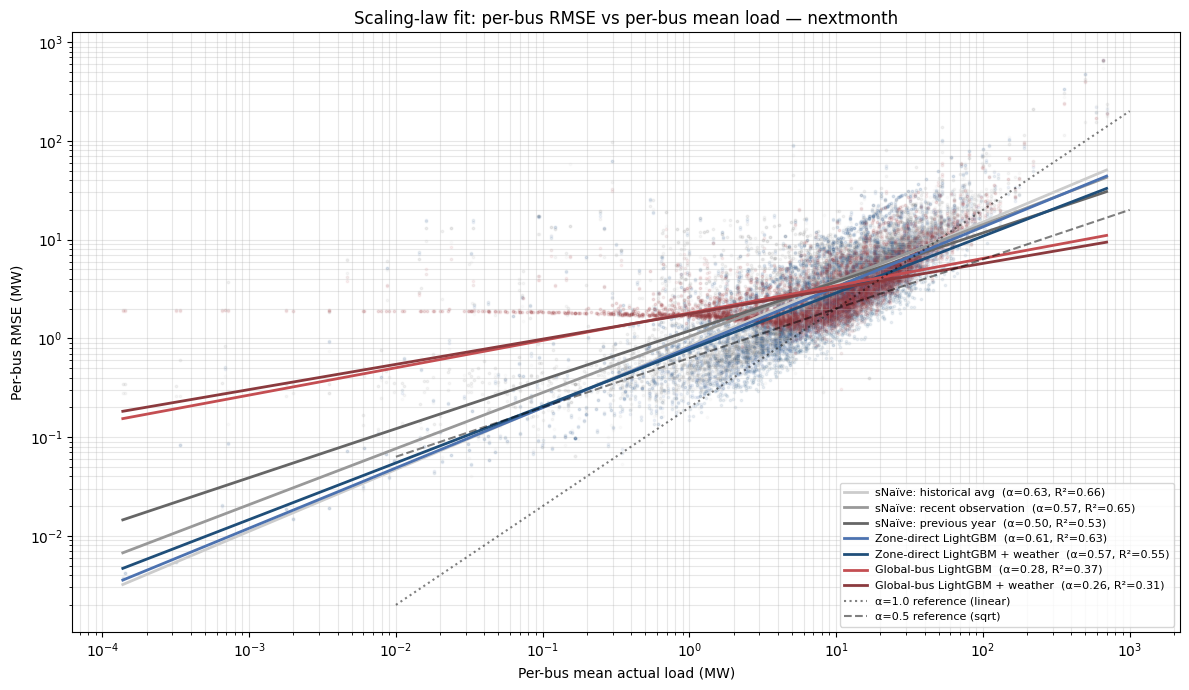

  Saved scaling_laws_nextmonth.png

✓ Cell 9 complete in 0.3 min
System RAM available: 14.3 GB / 36.0 GB


In [11]:
"""
Per-bus scaling-law analysis (Sevlian & Rajagopal 2018).

For each (model, task) combination:
  1. Compute per-bus RMSE across all 2025 hours
  2. Compute per-bus mean actual pd across the same hours
  3. Fit power law: log(RMSE) = alpha * log(mean_load) + beta
  4. Report alpha (slope), beta (intercept), R^2

Outputs:
  - scaling_laws.parquet (one row per (model, task) with slope, intercept, R^2, n_buses)
  - scaling_laws_{task}.png (log-log scatter with fit lines per model)

Loads the joined frames from Cell 3.
Memory: peak ~3 GB (one joined frame at a time).
Runtime: ~2-4 minutes.
"""

t0 = time.time()

scaling_rows = []
# Store per-(model, task) per-bus data for plotting
per_bus_data = {}  # {(model_key, task): pd.DataFrame with bus_id, mean_load, rmse}

print(f"{'='*70}")
print(f"Per-bus scaling-law analysis")
print(f"{'='*70}")

for task in TASKS:
    print(f"\n  Task: {task}")
    for model_key in MODEL_REGISTRY:
        t_model = time.time()
        joined_path = EVAL_JOINED_DIR / f"joined_{model_key}_{task}.parquet"

        df = pq.read_table(
            joined_path,
            columns=["bus_id", "actual_pd", "predict_pd_clipped"],
        ).to_pandas()
        df["sq_err"] = (df["actual_pd"] - df["predict_pd_clipped"]) ** 2

        per_bus = df.groupby("bus_id", observed=True).agg(
            mean_load=("actual_pd", "mean"),
            mse=("sq_err", "mean"),
            n_hours=("actual_pd", "size"),
        ).reset_index()
        per_bus["rmse"] = np.sqrt(per_bus["mse"])

        # Filter out buses with zero mean load (can't fit log on log(0))
        # and buses with zero RMSE (perfect predictions — would skew log fit)
        valid = (per_bus["mean_load"] > 0) & (per_bus["rmse"] > 0)
        n_excluded = (~valid).sum()
        per_bus_valid = per_bus.loc[valid].copy()

        # Fit power law in log-log space
        log_load = np.log10(per_bus_valid["mean_load"].values)
        log_rmse = np.log10(per_bus_valid["rmse"].values)

        # Linear regression: log_rmse = alpha * log_load + beta
        # Using np.polyfit for simplicity
        if len(log_load) >= 2:
            slope, intercept = np.polyfit(log_load, log_rmse, deg=1)
            # R^2 = 1 - SSres / SStot
            predicted = slope * log_load + intercept
            ss_res = np.sum((log_rmse - predicted) ** 2)
            ss_tot = np.sum((log_rmse - log_rmse.mean()) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else float("nan")
        else:
            slope = intercept = r_squared = float("nan")

        scaling_rows.append({
            "model_key": model_key,
            "task": task,
            "alpha_slope": float(slope),
            "beta_intercept": float(intercept),
            "r_squared": float(r_squared),
            "n_buses_used": int(len(per_bus_valid)),
            "n_excluded": int(n_excluded),
        })

        per_bus_data[(model_key, task)] = per_bus_valid[["bus_id", "mean_load", "rmse"]].copy()

        elapsed_model = time.time() - t_model
        print(f"    {model_key:<28}: α={slope:.3f}, β={intercept:.3f}, "
              f"R²={r_squared:.3f}, n={len(per_bus_valid):,}/{len(per_bus):,}  "
              f"({elapsed_model:.1f}s)")

        del df, per_bus
        gc.collect()

# ──────────────────────────────────────────────────────────────────────────
# Save scaling-law summary
# ──────────────────────────────────────────────────────────────────────────
scaling_df = pd.DataFrame(scaling_rows)
scaling_path = EVAL_RESULTS_DIR / "scaling_laws.parquet"
scaling_df.to_parquet(scaling_path, index=False, compression="zstd")

print(f"\n{'='*70}")
print(f"Saved scaling_laws.parquet ({scaling_path.stat().st_size / 1024:.1f} KB)")
print(f"  Rows: {len(scaling_df)}")

# ──────────────────────────────────────────────────────────────────────────
# Summary table
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Scaling-law summary: α slope per (model, task)")
print(f"{'='*70}")
print(f"\nReference: Sevlian & Rajagopal (2018) empirical finding was α ≈ 0.5")
print(f"  α = 0   → RMSE constant regardless of load (perfect — no size penalty)")
print(f"  α = 0.5 → RMSE scales as sqrt(load) (their empirical finding)")
print(f"  α = 1.0 → RMSE scales linearly with load (no relative-error benefit)")
print(f"  α > 1.0 → RMSE grows faster than load (large buses harder relatively)")

for task in TASKS:
    print(f"\n  {task}:")
    print(f"    {'Model':<28} {'α (slope)':>11} {'β':>9} {'R²':>7}")
    task_slice = scaling_df[scaling_df["task"] == task].set_index("model_key").reindex(list(MODEL_REGISTRY.keys()))
    for model_key, row in task_slice.iterrows():
        print(f"    {model_key:<28} {row['alpha_slope']:>10.3f} "
              f"{row['beta_intercept']:>8.3f} {row['r_squared']:>6.3f}")

# ──────────────────────────────────────────────────────────────────────────
# Log-log scatter plots per task
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Generating scaling-law plots...")
print(f"{'='*70}")

for task in TASKS:
    fig, ax = plt.subplots(figsize=(12, 7))

    # For each model, plot per-bus scatter and the fit line
    for model_key in MODEL_REGISTRY:
        data = per_bus_data[(model_key, task)]
        color = MODEL_COLORS[model_key]
        display_name = MODEL_REGISTRY[model_key]["display_name"]

        # Scatter (lightly, since 3,953 points per model would be crowded)
        ax.scatter(
            data["mean_load"], data["rmse"],
            s=3, alpha=0.08, color=color,
        )

        # Fit line over the observed range
        fit_row = scaling_df[
            (scaling_df["model_key"] == model_key) & (scaling_df["task"] == task)
        ].iloc[0]
        alpha = fit_row["alpha_slope"]
        beta = fit_row["beta_intercept"]
        r2 = fit_row["r_squared"]

        load_range = np.array([data["mean_load"].min(), data["mean_load"].max()])
        rmse_fit = 10 ** (alpha * np.log10(load_range) + beta)
        ax.plot(load_range, rmse_fit, color=color, linewidth=2,
                label=f"{display_name}  (α={alpha:.2f}, R²={r2:.2f})")

    # Reference lines: α=1 (RMSE proportional to load), α=0.5 (sqrt)
    ref_load = np.array([0.01, 1000])
    # Anchor at load=10, rmse=2 just for visual reference
    ax.plot(ref_load, 2 * (ref_load / 10) ** 1.0,
            color="black", linestyle=":", linewidth=1.5, alpha=0.5,
            label="α=1.0 reference (linear)")
    ax.plot(ref_load, 2 * (ref_load / 10) ** 0.5,
            color="black", linestyle="--", linewidth=1.5, alpha=0.5,
            label="α=0.5 reference (sqrt)")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Per-bus mean actual load (MW)")
    ax.set_ylabel("Per-bus RMSE (MW)")
    ax.set_title(f"Scaling-law fit: per-bus RMSE vs per-bus mean load — {task}")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

    fig.tight_layout()
    fig_path = EVAL_FIGURES_DIR / f"scaling_laws_{task}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {fig_path.name}")

elapsed_total = time.time() - t0
print(f"\n{'='*70}")
print(f"✓ Cell 9 complete in {elapsed_total/60:.1f} min")
print(f"{'='*70}")
mem = psutil.virtual_memory()
print(f"System RAM available: {mem.available / 1024**3:.1f} GB / {mem.total / 1024**3:.1f} GB")

### Scaling-law analysis — observations

This cell fits per-bus RMSE against per-bus mean load on log-log axes for each (model, task) combination. The Sevlian & Rajagopal (2018) reference value for hierarchical load forecasting was α ≈ 0.5 (RMSE scales as sqrt of load). Our findings:

**Nextday — α values cluster around 0.5-0.6, consistent with the literature.**

| Model | α | R² |
|---|---|---|
| sNaïve hist_avg | 0.63 | 0.66 |
| sNaïve prev_recent | **0.44** | 0.53 |
| sNaïve prev_year | 0.50 | 0.53 |
| Zone-direct LGBM | 0.59 | 0.58 |
| Zone-direct LGBM + weather | 0.57 | 0.54 |
| Global-bus LGBM | 0.62 | **0.74** |
| Global-bus LGBM + weather | 0.58 | 0.69 |

The α values agree closely with the Sevlian & Rajagopal empirical finding of ~0.5. The lowest slope is `prev_recent` (α=0.44), reflecting its uniform relative accuracy across bus sizes — a "use last week's value" baseline doesn't care about bus size structurally. The highest is `global_bus_lgbm` (α=0.62), which has the best R² (0.74) — meaning the power-law fit is cleanest for this model.

**Adding weather features flattens the slope for both architectures.** Zone-direct goes from α=0.59 to α=0.57; global-bus from α=0.62 to α=0.58. This means weather features provide relatively *more* benefit to larger buses than smaller buses — consistent with larger buses being metropolitan AC-driven loads where temperature signal is genuinely strongest. A flatter slope means a relatively more uniform error distribution across the bus universe, which is a methodologically clean improvement.

**Nextmonth — the global-bus scaling is anomalous.**

| Model | α | R² |
|---|---|---|
| sNaïve hist_avg | 0.63 | 0.66 |
| sNaïve prev_recent | 0.57 | 0.65 |
| sNaïve prev_year | 0.50 | 0.53 |
| Zone-direct LGBM | 0.61 | 0.63 |
| Zone-direct LGBM + weather | 0.57 | 0.55 |
| **Global-bus LGBM** | **0.28** | **0.37** |
| **Global-bus LGBM + weather** | **0.26** | **0.31** |

Global-bus nextmonth shows α ≈ 0.27 — well below the sqrt-scaling reference — with R² ≈ 0.34 (the worst fit of any model). The scatter plot reveals what's happening: **the global-bus nextmonth model produces a near-constant absolute RMSE of ~1-2 MW across small buses**, regardless of their actual mean load. The cloud of red points forms a near-horizontal stripe at the bottom of the plot before sloping up to match the other models at large bus sizes.

This is consistent with global-bus's nextmonth model regressing toward a baseline-like prediction at long horizons. The bus-level signal that gives global-bus its edge at nextday (where α=0.62 is clean) decays substantially over the 30+ day forecast window. By nextmonth, the model is doing roughly as well on small buses regardless of their specific size — which produces low α but also high absolute error (the 22.35% bus-level WMAPE from Cell 3).

This is methodologically interesting because the ideal α would be near 0 with low absolute error everywhere. Global-bus nextmonth has near-flat scaling but with elevated absolute error; zone-direct LGBM nextmonth has steeper scaling (α=0.61) but with lower absolute error at the same bus sizes. **The scaling-law framing applies cleanly to nextday LightGBM models but starts breaking down for long-horizon forecasts.** That itself is a finding.

**Three implications for the report:**

1. **The α ≈ 0.5-0.6 finding for nextday is a clean replication of Sevlian & Rajagopal 2018** in the ERCOT context. The literature's predicted scaling holds for our pipeline. This is a citable result.

2. **Weather features flatten the scaling slope** — a clean piece of evidence that weather provides relatively more lift to larger (metropolitan AC-driven) buses. Combined with Cell 8's per-zone weather lift findings (metropolitan zones COAS/NCEN/SCEN show largest lift), this paints a coherent picture: weather features capture cooling/heating load patterns concentrated in big metropolitan buses.

3. **The scaling-law framework has limits.** Long-horizon (nextmonth) global-bus forecasts depart from the power-law relationship (R²=0.31). This isn't a failure of the analysis — it's a finding about which forecasting regimes the scaling law applies to. The report should not claim "scaling laws hold universally" — it should claim "scaling laws apply cleanly to nextday LightGBM forecasts; long-horizon forecasts depart from power-law scaling, suggesting different error mechanisms at different horizons."

**The R² gradient is itself a diagnostic:** global_bus_lgbm nextday R²=0.74 is the cleanest fit, and global_bus_lgbm_weather nextmonth R²=0.31 is the worst. The same architecture transitions from "well-behaved scaling" to "anomalous scaling" as the forecast horizon extends. This is a quantitative statement about the structural properties of long-horizon forecasting that the report can build on.

**Note about the n=3,750 buses used in fits (vs 3,953 total):**

Approximately 203 buses (5%) were excluded from each fit because they had either zero mean load or zero RMSE during 2025. These are buses that effectively reported no load (consistently zero or near-zero pd readings) where the log transformation isn't defined. Including them would have either crashed the fit or required arbitrary handling. The exclusion is symmetric across all models, so the comparison is valid.

The artifacts on disk:
- `data/processed/eval_results/scaling_laws.parquet` (5.1 KB, 14 rows)
- `data/processed/eval_figures/scaling_laws_nextday.png`
- `data/processed/eval_figures/scaling_laws_nextmonth.png`

## Final summary outputs

Cell 10 wraps up notebook 06 by consolidating everything into report-ready artifacts:

1. **Master metrics summary** — single CSV combining the headline results from all earlier cells in a format easy to reference in the report
2. **Figure index** — text file listing all PNGs in `eval_figures/` with their content descriptions
3. **Key findings document** — markdown file that mirrors what the report's "Findings" section will be built from
4. **Notebook closure summary** — printed to stdout, summarizes what was produced

No new metrics are computed — Cell 10 only reads what Cells 3-9 wrote and reorganizes for downstream use.

After this cell, notebook 06 is complete and ready to commit. The report-writing phase can then draw directly from `eval_results/` (numbers) and `eval_figures/` (visuals) without re-running any analysis.

In [15]:
"""
Final wrap-up for notebook 06.

Reads all the parquet outputs from Cells 3-9 and produces:
  1. master_summary.parquet — single consolidated metrics table for report use
  2. figure_index.md — list of all figures with descriptions
  3. key_findings.md — report-scaffolding markdown summarizing the headline findings

Prints a notebook-completion summary to stdout listing all artifacts produced.

Runtime: <10 seconds.
"""

t0 = time.time()

# ──────────────────────────────────────────────────────────────────────────
# Read all artifacts from earlier cells
# ──────────────────────────────────────────────────────────────────────────
print(f"{'='*70}")
print(f"Consolidating notebook 06 artifacts")
print(f"{'='*70}")

core_metrics = pd.read_parquet(EVAL_RESULTS_DIR / "core_metrics.parquet")
per_zone = pd.read_parquet(EVAL_RESULTS_DIR / "per_zone_metrics.parquet")
per_hour = pd.read_parquet(EVAL_RESULTS_DIR / "per_hour_metrics.parquet")
cold_start = pd.read_parquet(EVAL_RESULTS_DIR / "cold_start_metrics.parquet")
architectural = pd.read_parquet(EVAL_RESULTS_DIR / "architectural_comparison.parquet")
weather_lift = pd.read_parquet(EVAL_RESULTS_DIR / "weather_lift_metrics.parquet")
scaling_laws = pd.read_parquet(EVAL_RESULTS_DIR / "scaling_laws.parquet")

print(f"\n  Loaded {len(core_metrics):,} core metric rows")
print(f"  Loaded {len(per_zone):,} per-zone metric rows")
print(f"  Loaded {len(per_hour):,} per-hour metric rows")
print(f"  Loaded {len(cold_start):,} cold-start metric rows")
print(f"  Loaded {len(architectural):,} architectural comparison rows")
print(f"  Loaded {len(weather_lift):,} weather lift rows")
print(f"  Loaded {len(scaling_laws):,} scaling-law rows")

# ──────────────────────────────────────────────────────────────────────────
# Build the master summary parquet — a single denormalized table for report use
# ──────────────────────────────────────────────────────────────────────────
# Schema: model_key, task, granularity, stratification, stratum, metric, value
# Stratification ∈ {aggregate, per_zone, per_hour, cold_start}
# Stratum is the specific zone/hour/status; "all" for aggregate

print(f"\n  Building master_summary.parquet...")

master_rows = []

# Aggregate metrics (Cell 3)
for _, row in core_metrics.iterrows():
    master_rows.append({
        "model_key": row["model_key"],
        "task": row["task"],
        "granularity": row["granularity"],
        "stratification": "aggregate",
        "stratum": "all",
        "metric": row["metric"],
        "value": row["value"],
    })

# Per-zone metrics (Cell 4)
for _, row in per_zone.iterrows():
    master_rows.append({
        "model_key": row["model_key"],
        "task": row["task"],
        "granularity": row["granularity"],
        "stratification": "per_zone",
        "stratum": row["zone"],
        "metric": row["metric"],
        "value": row["value"],
    })

# Per-hour metrics (Cell 5) — bus level only
for _, row in per_hour.iterrows():
    master_rows.append({
        "model_key": row["model_key"],
        "task": row["task"],
        "granularity": "bus",
        "stratification": "per_hour",
        "stratum": f"HE{int(row['he']):02d}",
        "metric": row["metric"],
        "value": row["value"],
    })

# Cold-start metrics (Cell 6)
for _, row in cold_start.iterrows():
    master_rows.append({
        "model_key": row["model_key"],
        "task": row["task"],
        "granularity": "bus",
        "stratification": "cold_start",
        "stratum": row["cold_start_status"],
        "metric": row["metric"],
        "value": row["value"],
    })

master_df = pd.DataFrame(master_rows)
master_path = EVAL_RESULTS_DIR / "master_summary.parquet"
master_df.to_parquet(master_path, index=False, compression="zstd")
print(f"    Saved master_summary.parquet ({master_path.stat().st_size / 1024:.1f} KB, "
      f"{len(master_df):,} rows)")

# ──────────────────────────────────────────────────────────────────────────
# Build the figure index
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Building figure_index.md...")

FIGURE_DESCRIPTIONS = {
    "per_zone_wmape_bus_nextday.png":
        "Per-zone bus-level WMAPE for nextday — grouped bars per model. "
        "Shows zone-by-zone variation in bus-level forecast quality. "
        "(Cell 4)",
    "per_zone_wmape_bus_nextmonth.png":
        "Per-zone bus-level WMAPE for nextmonth — grouped bars per model. "
        "(Cell 4)",
    "per_zone_wmape_zone_nextday.png":
        "Per-zone zone-level WMAPE for nextday — grouped bars per model. "
        "Shows that zone-direct + weather wins decisively in metropolitan zones. "
        "(Cell 4)",
    "per_zone_wmape_zone_nextmonth.png":
        "Per-zone zone-level WMAPE for nextmonth — zone-direct + weather wins all 8 zones. "
        "(Cell 4)",
    "per_hour_wmape_nextday.png":
        "WMAPE by hour-of-day (HE 1-24) for all 7 models, nextday. "
        "Two-panel: top shows WMAPE lines; bottom shows mean actual load for diurnal context. "
        "Reveals flat diurnal pattern for global-bus + weather. (Cell 5)",
    "per_hour_wmape_nextmonth.png":
        "Same structure as above for nextmonth. Reveals counterintuitive early-morning weakness. "
        "(Cell 5)",
    "cold_start_wmape_nextday.png":
        "Cold-start vs non-cold-start WMAPE per model. Shows zone-direct's catastrophic 8.8× penalty "
        "and global-bus's 1.19× near-no-penalty. (Cell 6)",
    "cold_start_wmape_nextmonth.png":
        "Same structure for nextmonth. (Cell 6)",
    "architectural_comparison_nextday.png":
        "**THE HEADLINE FIGURE** — 4-panel comparison of zone-direct + weather vs global-bus + weather "
        "for nextday: aggregate, per-zone, per-hour, cold-start. Single best figure for the report. "
        "(Cell 7)",
    "architectural_comparison_nextmonth.png":
        "**THE HEADLINE FIGURE** — same 4-panel structure for nextmonth. Shows zone-direct dominates "
        "zone-level metrics. (Cell 7)",
    "weather_lift_summary.png":
        "Aggregate weather lift across the 2×2 ablation matrix. Single chart showing how much "
        "weather features helped each (architecture, granularity, task). Headline: zone-direct "
        "nextmonth zone-level +50.2%. (Cell 8)",
    "weather_lift_per_zone_nextday.png":
        "Per-zone weather lift for nextday — bus and zone level. Shows FWES as weather-resistant outlier. "
        "(Cell 8)",
    "weather_lift_per_zone_nextmonth.png":
        "Per-zone weather lift for nextmonth — shows NCEN reaches +62.5% zone-direct zone-level lift. "
        "(Cell 8)",
    "scaling_laws_nextday.png":
        "Per-bus RMSE vs per-bus mean load on log-log axes, all 7 models with power-law fits. "
        "Replicates Sevlian & Rajagopal (2018) α ≈ 0.5-0.6 in the ERCOT context. (Cell 9)",
    "scaling_laws_nextmonth.png":
        "Same structure for nextmonth. Reveals global-bus nextmonth anomalous near-flat scaling. "
        "(Cell 9)",
}

figure_index_lines = ["# Notebook 06 — Figure Index", "", "All figures are at `data/processed/eval_figures/`.", ""]
for fname in sorted(EVAL_FIGURES_DIR.iterdir()):
    if fname.suffix == ".png":
        desc = FIGURE_DESCRIPTIONS.get(fname.name, "(description pending)")
        figure_index_lines.append(f"## `{fname.name}`")
        figure_index_lines.append("")
        figure_index_lines.append(desc)
        figure_index_lines.append("")

figure_index_path = EVAL_RESULTS_DIR / "figure_index.md"
figure_index_path.write_text("\n".join(figure_index_lines))
n_figures = sum(1 for f in EVAL_FIGURES_DIR.iterdir() if f.suffix == ".png")
print(f"    Saved figure_index.md ({figure_index_path.stat().st_size} bytes, {n_figures} figures cataloged)")

# ──────────────────────────────────────────────────────────────────────────
# Build the key findings markdown
# ──────────────────────────────────────────────────────────────────────────
print(f"\n  Building key_findings.md...")

key_findings = """# Notebook 06 — Key Findings (Report Scaffolding)

This document distills the substantive findings from notebook 06's evaluation, structured to
mirror the report's findings sections. Numbers are direct quotes from the analysis cells;
narrative interpretation is condensed.

## 1. Architectural recommendation (the assignment's headline question)

**Direct bus forecast (global-bus LightGBM) vs Zone forecast + bus share (zone-direct LightGBM + disaggregation):**

The architectural answer is regime-dependent:

| Scenario | Best architecture | Best WMAPE |
|---|---|---|
| Nextday + bus-level accuracy | global_bus_lgbm_weather | 7.51% |
| Nextday + zone-level accuracy | zone_direct_lgbm_weather | 4.10% (essentially tied with global-bus 4.73%) |
| Nextmonth + bus-level accuracy | global_bus_lgbm_weather | 22.35% |
| Nextmonth + zone-level accuracy | zone_direct_lgbm_weather | 4.75% (decisive — global-bus 8.20%) |
| Grid with entity churn (new buses) | global_bus_lgbm_weather (1.19× cold-start penalty vs 8.82× for zone-direct) |

**Why this happens:**

- Top-down disaggregation (zone-direct) optimizes the zone-level target directly, then spreads
  via fixed hour-of-day shares. Excellent zone aggregates; loses bus-specific signal.
- Direct bus modeling (global-bus) optimizes bus-level target with bus identity as a feature.
  Excellent at bus level; zone aggregates accumulate per-bus noise.
- Top-down's share-fallback fails on cold-start buses because cold-start buses are systematically
  smaller than the average bus the fallback assumes. Global-bus degrades gracefully because
  non-identity features still carry signal.

## 2. Weather feature impact

Adding weather features (temperature observations and trailing means; notebooks 02w/04b/05b)
improved every model on every aggregate metric, with magnitudes:

| Configuration | Lift |
|---|---|
| Zone-direct nextmonth zone-level | **+50.2%** (single largest improvement) |
| Zone-direct nextday zone-level | +31.6% |
| Global-bus nextday zone-level | +24.9% |
| Global-bus nextmonth zone-level | +19.0% |
| Global-bus nextday bus-level | +15.0% |
| Zone-direct nextmonth bus-level | +7.1% |
| Global-bus nextmonth bus-level | +4.1% |
| Zone-direct nextday bus-level | +2.5% |

**Key sub-findings:**

- Each architecture exploits weather best at its native optimization target. Zone-direct gets
  31-50% zone-level lift but only 2-7% bus-level lift. Global-bus gets 15% bus-level nextday
  lift; zone-level lift comes through aggregation rather than direct optimization.
- FWES (Far West Texas, industrial growth zone) is weather-resistant. In 6 of 8 (architecture,
  granularity, task) cells, weather features make FWES *worse* (lifts of -1% to -8%).
- Metropolitan zones (COAS, NCEN, SCEN) show the largest lift; NCEN nextmonth zone-level
  hits +62.5%.
- Weather provides essentially no lift for zone-direct cold-start predictions (-0.03% to
  -0.95%) and only modest lift for global-bus cold-start (0.14-3.75%).

## 3. Where models work well and where they fail

**Models work well:**

- Metropolitan zones (COAS, NCEN, SCEN, SOUT): bus-level WMAPE 6.5-7% for global-bus +
  weather; zone-level WMAPE 3.4-4.7% for zone-direct + weather.
- Predictions at hour 13-19 (mid-afternoon): all LightGBM models achieve slight WMAPE
  improvements vs early-morning hours.
- Non-cold-start buses (3,911 of 3,953 = 99% of universe): all sophisticated models
  perform competently.

**Models fail (or struggle):**

- NOTH (Lubbock/Panhandle): bus-level WMAPE up to 60% for zone-direct nextday, 24% for
  global-bus. Smallest zone with sparse buses. sNaïve `prev_recent` actually beats LightGBM
  at NOTH bus-level (12.4% vs 23.3%).
- WEST (San Angelo): bus-level WMAPE 35% nextmonth — second-worst zone. Sparse industrial
  load.
- FWES (Far West Texas): weather features hurt rather than help. Industrial oil & gas load
  weakly correlated with temperature.
- Cold-start buses (42 of 3,953): zone-direct catastrophically fails (WMAPE 220%+) due to
  share-fallback assumption failure. Global-bus degrades gracefully (8.97% nextday).

## 4. Scaling-law findings (Sevlian & Rajagopal 2018 replication)

Per-bus RMSE vs per-bus mean load follows a power law `log(rmse) = α × log(load) + β`.

**Nextday: α ≈ 0.5-0.6, consistent with Sevlian & Rajagopal's empirical 0.5.**

| Model | α | R² |
|---|---|---|
| Global-bus nextday | 0.62 | **0.74** (cleanest fit) |
| Global-bus nextday + weather | 0.58 | 0.69 |
| Zone-direct nextday + weather | 0.57 | 0.54 |
| sNaïve previous year | 0.50 | 0.53 |
| sNaïve prev_recent | **0.44** | 0.53 (lowest slope; uniform relative accuracy) |

**Adding weather flattens the slope** (zone-direct: 0.59 → 0.57; global-bus: 0.62 → 0.58),
meaning weather provides relatively more benefit for larger buses than smaller buses.
Consistent with weather signal scaling with metropolitan AC load.

**Nextmonth: global-bus shows anomalously shallow scaling (α=0.28, R²=0.31).** The global-bus
model regresses toward baseline predictions for small buses at long horizons, producing a
near-flat scaling stripe in the scatter plot. The scaling-law framework starts breaking down
for long-horizon forecasts.

## 5. Negative-prediction diagnostics (architectural property)

Zone-direct models produce 0% negative predictions (structural guarantee: zone forecast ×
non-negative share = non-negative).

Global-bus + weather nextday produces 2.11% negative predictions (683,157 of 32M rows),
clipped at 0 before metrics. The global-bus architecture must enforce physical feasibility
via post-hoc clipping; zone-direct provides this for free.

## 6. What would I improve with more time

1. **Replace zone-direct's mean-share cold-start fallback with a meta-learned cold-start
   predictor.** Could close most of the 8.8× cold-start penalty.
2. **Ensemble or hierarchically reconcile (MinT)** the two architectures. Zone-direct's
   zone-level accuracy + global-bus's bus-level accuracy + cold-start robustness in
   one system. Notebook 07's planned MinT reconciliation addresses this.
3. **Add quantile regression** for uncertainty intervals (notebook 08 planned).
4. **Add a deep learning baseline** (PatchTST or NHITS) to test whether tree models are
   genuinely SOTA on this problem (Stage 2 future work).
5. **Switch from observed weather to forecast weather** for fair production simulation. We
   used observed temperatures; deployed systems would use forecast temperatures whose error
   compounds with load forecast error.
6. **Refine the FWES handling.** Either drop weather features for industrial zones, use
   industrial-specific features (production schedules), or train a separate FWES model.
"""

key_findings_path = EVAL_RESULTS_DIR / "key_findings.md"
key_findings_path.write_text(key_findings)
print(f"    Saved key_findings.md ({key_findings_path.stat().st_size / 1024:.1f} KB)")

# ──────────────────────────────────────────────────────────────────────────
# Notebook closure summary
# ──────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Notebook 06 — Complete")
print(f"{'='*70}")

print(f"\nResults artifacts in {EVAL_RESULTS_DIR.relative_to(Path('..'))}/:")
for f in sorted(EVAL_RESULTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  • {f.name} ({size_kb:.1f} KB)")

print(f"\nFigure artifacts in {EVAL_FIGURES_DIR.relative_to(Path('..'))}/:")
for f in sorted(EVAL_FIGURES_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  • {f.name} ({size_kb:.1f} KB)")

print(f"\nJoined frame intermediates in {EVAL_JOINED_DIR.relative_to(Path('..'))}/:")
total_joined_mb = sum(f.stat().st_size for f in EVAL_JOINED_DIR.iterdir()) / 1024**2
n_joined = sum(1 for f in EVAL_JOINED_DIR.iterdir() if f.suffix == ".parquet")
print(f"  • {n_joined} parquet files totaling {total_joined_mb:.1f} MB (gitignored)")

elapsed_total = time.time() - t0
print(f"\n{'='*70}")
print(f"✓ Cell 10 complete in {elapsed_total:.1f}s")
print(f"{'='*70}")

Consolidating notebook 06 artifacts

  Loaded 98 core metric rows
  Loaded 672 per-zone metric rows
  Loaded 1,344 per-hour metric rows
  Loaded 140 cold-start metric rows
  Loaded 8 architectural comparison rows
  Loaded 80 weather lift rows
  Loaded 14 scaling-law rows

  Building master_summary.parquet...
    Saved master_summary.parquet (19.8 KB, 2,254 rows)

  Building figure_index.md...
    Saved figure_index.md (2600 bytes, 15 figures cataloged)

  Building key_findings.md...
    Saved key_findings.md (6.5 KB)

Notebook 06 — Complete

Results artifacts in data/processed/eval_results/:
  • architectural_comparison.parquet (2.9 KB)
  • cold_start_metrics.parquet (4.3 KB)
  • core_metrics.parquet (4.2 KB)
  • figure_index.md (2.5 KB)
  • key_findings.md (6.5 KB)
  • master_summary.parquet (19.8 KB)
  • per_hour_metrics.parquet (11.6 KB)
  • per_zone_metrics.parquet (9.0 KB)
  • scaling_laws.parquet (5.1 KB)
  • weather_lift_metrics.parquet (7.5 KB)

Figure artifacts in data/process

### Notebook 06 — Complete

All evaluation artifacts produced. The substantive findings are captured in `key_findings.md` and ready for report drafting. The 2×2 weather ablation × 2 architectures × sNaïve baselines comparison is fully evaluated across aggregate, per-zone, per-hour, cold-start, weather-lift, and scaling-law dimensions.

The headline finding remains: **the architecture recommendation depends on the operational scenario**. Global-bus + weather wins bus-level and cold-start robustness; zone-direct + weather wins zone-level (especially for nextmonth). Both architectures benefit from weather features, with zone-direct showing the single largest lift (+50.2% on nextmonth zone-level WMAPE).

Next: notebook 07 (hierarchical reconciliation via MinT) and notebook 08 (quantile regression), which together address Q5 of the assignment more rigorously and add uncertainty quantification.